# Detección de Agentes Automatizados en Redes Sociales

**Autores:** Julián Santiago Flórez Castañeda, Camila Andrea Peña Caballero, Samuel Kalell Zuñiga Molina
**Curso:** Seminario de Investigación
**Docente:** Diego Armando García García
**Universidad EAN – Ingeniería de Sistemas – Bogotá D.C. – 2026**

---

## Objetivo del proyecto
Desarrollar un enfoque para la identificación de agentes automatizados en redes sociales basado en características conductuales, temporales y lingüísticas, y analizar su influencia en las métricas de inmersión.

## Alcance y límites
- El análisis se realiza sobre un dataset académico de 2017 con cuentas etiquetadas como genuinas/humanas y spam/bots.
- Se extraen y analizan features conductuales, temporales y lingüísticas.
- Se entrenan y evalúan modelos supervisados y no supervisados.
- Se comparan métricas de inmersión entre cuentas humanas y automatizadas.
- Limitaciones: antigüedad y posible sesgo de etiquetado del dataset; no se recolectan datos actuales desde la API de X.

## Resumen
El uso creciente de agentes automatizados impulsados por IA en redes sociales genera desafíos para la autenticidad de la interacción digital y la confiabilidad de las métricas de participación. Este estudio desarrolla un enfoque para identificar cuentas automatizadas en X (antes Twitter) mediante el análisis combinado de características conductuales, temporales y lingüísticas, evaluando su impacto en los niveles de interacción. Se utiliza un dataset académico de 2017 con cuentas etiquetadas, extrayendo rasgos y entrenando modelos de clasificación. Los resultados aportan evidencia sobre patrones discriminativos y criterios útiles para la detección de bots en datos históricos.

## Objetivos específicos
1. Identificar patrones de comportamiento que diferencien cuentas humanas de automatizadas.
2. Definir características temporales asociadas a la actividad de agentes automatizados.
3. Analizar patrones lingüísticos presentes en publicaciones automatizadas.
4. Comparar el nivel de inmersión entre cuentas humanas y agentes automatizados.
5. Evaluar la efectividad de los criterios definidos para la clasificación de cuentas.

## Catálogo de datasets
- **Fuente:** Dataset académico Cresci 2017
- **Descripción:** Colección de cuentas genuinas, tradicionales, spambots y fake followers, con archivos de usuarios y tweets.
- **Estructura:**
    - genuine_accounts: tweets.csv, users.csv
    - social_spambots_1/2/3: tweets.csv, users.csv
    - traditional_spambots_1/2/3/4: tweets.csv, users.csv
    - fake_followers: tweets.csv, users.csv
    - crowdflower_results: crowdflower_results_aggregated.csv, contributors.csv, detailed.csv

## Metodología resumida
- Análisis cuantitativo, descriptivo y correlacional sobre cuentas humanas y automatizadas.
- Extracción de features conductuales, temporales y lingüísticas.
- Clasificación supervisada y clustering.
- Comparación de métricas de inmersión.
- Evaluación de modelos con métricas estándar (accuracy, precision, recall).
- Uso exclusivo de datos públicos y etiquetados, respetando condiciones éticas y legales.

## 01. Configuracion del entorno y librerias
- Nombre exacto de la seccion: Configuracion del entorno y librerias
- Objetivo tecnico: Preparar el entorno de ejecucion, dependencias y configuracion global
- Subsecciones / bloques: Configuracion del entorno; Importacion de librerias; Configuracion global
- Tipo de codigo: Configuracion, importaciones, flags globales
- Datos entran: No aplica
- Datos salen: `env_info`, `lib_versions`, `GLOBAL_CONFIG`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Versiones minimas, disponibilidad de GPU/CPU, rutas accesibles
- Transformaciones: Seteo de opciones globales y formato de salida
- Errores a controlar: Librerias faltantes, conflictos de versiones
- Resultados a guardar: `env_snapshot.json`
- Artefactos a exportar: `requirements_lock.txt`
- Variables sugeridas: `SEED`, `RANDOM_STATE`, `GLOBAL_CONFIG`, `RUN_ID`
- Checkpoint / cache: No aplica
- Notas de modularizacion: Encapsular en funcion `init_environment()`
- Reproducibilidad: Registrar versiones y seed al inicio
- Placeholder: agregar codigo en la celda inferior para inicializacion

In [28]:
# --- Configuración global y seeds
import os
import sys
import random
import warnings
import logging
import platform
from pathlib import Path

import numpy as np
import pandas as pd

# --- Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# --- Procesamiento de texto y NLP
import re
import unicodedata
import nltk
import spacy
from nltk.corpus import stopwords

# --- Machine Learning y Modelado
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

# --- NLP avanzado y embeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
# (Opcional: transformers para embeddings avanzados)
# from transformers import AutoTokenizer, AutoModel

# --- Interpretabilidad
import shap
import lime

# --- Utilidades y reproducibilidad
import json
import hashlib
import datetime

# --- Configuración de warnings y logs
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s')

# --- Variables globales sugeridas
SEED = 42
RANDOM_STATE = 42
GLOBAL_CONFIG = {}
RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
np.random.seed(SEED)
random.seed(SEED)

# --- Información del entorno
env_info = {
    'python_version': platform.python_version(),
    'os': platform.system(),
    'os_version': platform.version(),
    'cpu': platform.processor(),
    'ram_gb': round(os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024.**3), 2) if hasattr(os, 'sysconf') else None,
    'working_dir': os.getcwd(),
    'timestamp': RUN_ID
}

# --- Guardar snapshot de entorno
with open('env_snapshot.json', 'w') as f:
    json.dump(env_info, f, indent=2)

# --- Mostrar versiones principales
print('Python:', env_info['python_version'])
print('Pandas:', pd.__version__)
print('Numpy:', np.__version__)
print('Scikit-learn:', sys.modules['sklearn'].__version__)
print('NLTK:', nltk.__version__)
print('spaCy:', spacy.__version__)
print('Matplotlib:', plt.matplotlib.__version__)
print('Seaborn:', sns.__version__)
print('SHAP:', shap.__version__)

Python: 3.10.11
Pandas: 2.3.3
Numpy: 2.2.6
Scikit-learn: 1.7.2
NLTK: 3.9.4
spaCy: 3.8.14
Matplotlib: 3.10.0
Seaborn: 0.13.2
SHAP: 0.49.1


## 02. Reproducibilidad, higiene y modularizacion del notebook
- Nombre exacto de la seccion: Reproducibilidad, higiene y modularizacion del notebook
- Objetivo tecnico: Establecer reglas para ejecucion determinista y evitar notebooks desordenados
- Subsecciones / bloques: Seeds y determinismo; Orden de ejecucion; Modularizacion; Cache y persistencia
- Tipo de codigo: Configuracion de seeds, helpers y wrappers
- Datos entran: No aplica
- Datos salen: `repro_config`, `cache_policy`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Verificar determinismo entre ejecuciones
- Transformaciones: No aplica
- Errores a controlar: Resultados no reproducibles, orden de celdas inconsistente
- Resultados a guardar: `reproducibility_notes.md`
- Artefactos a exportar: `run_config.yaml`
- Variables sugeridas: `SEED`, `CACHE_DIR`, `ARTIFACTS_DIR`
- Checkpoint / cache: Definir puntos de guardado por etapa
- Notas de modularizacion: Crear modulos `io.py`, `features.py`, `models.py`
- Reproducibilidad: Fijar seeds y loggear versiones en cada run
- Placeholder: agregar codigo en la celda inferior para reglas de ejecucion

In [29]:
# --- 02. Reproducibilidad, higiene y modularización del notebook
# Configuración de seeds, helpers y reglas para ejecución determinista

import os
import sys
import random
import numpy as np
import hashlib
import json
import datetime
import logging
from pathlib import Path

# --- Variables y rutas globales para reproducibilidad
SEED = 42
CACHE_DIR = Path('output/cache')
ARTIFACTS_DIR = Path('output/artifacts')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Configuración de seeds para determinismo
random.seed(SEED)
np.random.seed(SEED)

# --- Helper para fijar seeds en frameworks adicionales (si aplica)
def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass

set_global_seed(SEED)

# --- Configuración de logging para reproducibilidad
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s',
    handlers=[
        logging.FileHandler(ARTIFACTS_DIR / f'run_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}.log'),
        logging.StreamHandler(sys.stdout)
    ]
)

# --- Configuración de orden de ejecución y control de celdas
# (Recomendación: ejecutar notebook de arriba hacia abajo, evitar saltos)

# --- Configuración de cache y persistencia
repro_config = {
    'seed': SEED,
    'cache_dir': str(CACHE_DIR),
    'artifacts_dir': str(ARTIFACTS_DIR),
    'run_timestamp': datetime.datetime.now().isoformat(),
    'python_version': sys.version,
    'notebook': os.path.basename(sys.argv[0]) if hasattr(sys, 'argv') and sys.argv else None
}

cache_policy = {
    'enabled': True,
    'checkpoint_stages': [
        'raw_load', 'cleaning', 'feature_engineering', 'modeling', 'evaluation'
    ],
    'format': 'parquet',
    'hash_function': 'sha256'
}

# --- Guardar configuración de reproducibilidad y cache
with open(ARTIFACTS_DIR / 'run_config.yaml', 'w') as f:
    import yaml
    yaml.dump(repro_config, f)
with open(ARTIFACTS_DIR / 'cache_policy.json', 'w') as f:
    json.dump(cache_policy, f, indent=2)

# --- Guardar notas de reproducibilidad
with open(ARTIFACTS_DIR / 'reproducibility_notes.md', 'w') as f:
    f.write("""
# Notas de reproducibilidad
- Seed global fijado en {seed}
- Configuración de cache y artefactos en carpetas dedicadas
- Logging de cada run en archivo único
- Se recomienda ejecutar el notebook de arriba hacia abajo sin saltos
- Versiones de librerías y entorno registradas en la sección de configuración
""".format(seed=SEED))

logging.info('Configuración de reproducibilidad y cache inicializada.')

2026-05-22 14:33:08,548 INFO Configuración de reproducibilidad y cache inicializada.


## 03. Definicion de paths y carga de datasets
- Nombre exacto de la seccion: Definicion de paths y carga de datasets
- Objetivo tecnico: Centralizar rutas y cargar datos crudos de forma trazable
- Subsecciones / bloques: Definicion de paths; Carga de datasets
- Tipo de codigo: I/O, lectura de CSV/Parquet, validacion de rutas
- Datos entran: Archivos crudos en `DATA_DIR`
- Datos salen: `df_raw`, `datasets_raw`
- Visualizaciones: No aplica (opcional tabla de conteos)
- Metricas: Cantidad de filas/columnas por dataset, tamanio en disco
- Validaciones: Existencia de archivos, encoding, delimitadores
- Transformaciones: Normalizacion minima de columnas (nombres)
- Errores a controlar: Archivos faltantes, parsing incorrecto
- Resultados a guardar: `data_inventory.csv`
- Artefactos a exportar: `raw_load_log.json`
- Variables sugeridas: `DATA_DIR`, `RAW_FILES`, `df_raw`
- Checkpoint / cache: Guardar `df_raw` en formato columna (parquet)
- Notas de modularizacion: Crear funcion `load_raw_data()`
- Reproducibilidad: Log de checksum y timestamp de carga
- Placeholder: agregar codigo en la celda inferior para I/O

In [30]:
# --- 03. Definición de paths y carga de datasets (versión robusta y parquet seguro)
# Carga todos los archivos .csv válidos encontrados en subcarpetas de DATA_DIR y corrige tipos para Parquet

import os
import pandas as pd
import json
import hashlib
import datetime
from pathlib import Path
import numpy as np

# --- Definición de path raíz de datos
DATA_DIR = Path('datasets_full')

# --- Helper para calcular checksum de archivo

def file_checksum(path, algo='sha256'):
    h = hashlib.new(algo)
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(8192)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

# --- Helper para inferir label por nombre de dataset

def infer_ground_truth_from_name(name: str):
    n = name.lower()
    if 'genuine_accounts' in n:
        return 'genuine'
    if 'fake_followers' in n:
        return 'fake_follower'
    if 'social_spambots' in n or 'traditional_spambots' in n:
        return 'spambot'
    # crowdflower o desconocido -> sin etiqueta directa
    return np.nan

# --- Función para buscar y cargar todos los CSV válidos (submuestreo 1 de cada 100 filas)

def load_all_csvs(data_dir=DATA_DIR):
    datasets_raw = {}
    inventory = []
    found = False
    for csv_path in data_dir.rglob('*.csv'):
        if csv_path.is_file() and csv_path.suffix == '.csv':
            found = True
            name = str(csv_path.relative_to(data_dir)).replace('\\', '/').replace('/', '__').replace('.csv', '')
            try:
                # Submuestreo eficiente: solo 1 de cada 100 filas al cargar
                df = pd.read_csv(csv_path, encoding='utf-8', delimiter=',', skiprows=lambda i: i != 0 and i % 100 != 0)
                df.columns = [c.strip().lower() for c in df.columns]

                # Agregar trazabilidad y etiqueta (si aplica)
                df['source_dataset'] = name
                df['ground_truth_class'] = infer_ground_truth_from_name(name)

                datasets_raw[name] = df
                inventory.append({
                    'dataset': name,
                    'file': str(csv_path),
                    'rows': df.shape[0],
                    'cols': df.shape[1],
                    'size_mb': round(csv_path.stat().st_size / 1024**2, 2),
                    'checksum': file_checksum(csv_path),
                    'load_timestamp': datetime.datetime.now().isoformat(),
                    'submuestreo': '1 de cada 100 filas',
                    'ground_truth_class': infer_ground_truth_from_name(name)
                })
            except Exception as e:
                print(f"[ERROR] Fallo al cargar {csv_path}: {e}")
    if not found:
        print(f"[ADVERTENCIA] No se encontraron archivos .csv en {data_dir.resolve()}.")
    # Guardar inventario
    inventory_df = pd.DataFrame(inventory)
    inventory_df.to_csv('data_inventory.csv', index=False)
    with open('raw_load_log.json', 'w') as f:
        json.dump(inventory, f, indent=2, default=globals().get('safe_json'))
    return datasets_raw, inventory_df

# --- Carga de todos los CSVs válidos

datasets_raw, data_inventory = load_all_csvs()

if len(datasets_raw) == 0:
    print(f"[ERROR] No se cargó ningún archivo .csv. Verifica la ruta: {DATA_DIR.resolve()} y el contenido de las subcarpetas.")
else:
    # --- Unir todos los datasets en un solo DataFrame (opcional, según análisis)
    df_raw = pd.concat(datasets_raw.values(), ignore_index=True, sort=False)
    # --- Forzar columnas problemáticas a string para Parquet
    for col in df_raw.columns:
        if df_raw[col].dtype == object or 'color' in col or 'id' in col:
            try:
                df_raw[col] = df_raw[col].astype(str)
            except Exception:
                pass
    Path('output').mkdir(parents=True, exist_ok=True)
    # --- Guardar checkpoint en formato columna (parquet)
    df_raw.to_parquet('output/df_raw.parquet', index=False)
    # --- Mostrar resumen de datasets cargados
    print(data_inventory)


                                              dataset  \
0   crowdflower_results__crowdflower_results__crow...   
1   crowdflower_results__crowdflower_results__crow...   
2   crowdflower_results__crowdflower_results__crow...   
3   crowdflower_results____MACOSX__crowdflower_res...   
4   crowdflower_results____MACOSX__crowdflower_res...   
5   crowdflower_results____MACOSX__crowdflower_res...   
6              fake_followers__fake_followers__tweets   
7               fake_followers__fake_followers__users   
8          fake_followers____MACOSX__._fake_followers   
9   fake_followers____MACOSX__fake_followers__._tw...   
10  fake_followers____MACOSX__fake_followers__._users   
11                           genuine_accounts__tweets   
12                            genuine_accounts__users   
13                          social_spambots_1__tweets   
14                           social_spambots_1__users   
15                          social_spambots_2__tweets   
16                           so

## 04. Verificacion de integridad y auditoria estructural
- Nombre exacto de la seccion: Verificacion de integridad y auditoria estructural
- Objetivo tecnico: Detectar problemas de schema, calidad y consistencia antes de analizar
- Subsecciones / bloques: Verificacion de integridad; Auditoria de variables; Deteccion de problemas estructurales
- Tipo de codigo: Checks de schema, profiling liviano, reglas de calidad
- Datos entran: `df_raw`
- Datos salen: `integrity_report`, `schema_profile`
- Visualizaciones: Matriz de nulos, resumen de tipos
- Metricas: % nulos, duplicados, cardinalidad, rangos
- Validaciones: Unicidad de claves, tipos esperados, rangos validos
- Transformaciones: No aplica (solo diagnostico)
- Errores a controlar: Columnas faltantes, tipos mixtos
- Resultados a guardar: `integrity_report.json`
- Artefactos a exportar: `schema_snapshot.json`
- Variables sugeridas: `expected_schema`, `integrity_report`
- Checkpoint / cache: Guardar reporte antes de limpieza
- Notas de modularizacion: Funcion `validate_schema(df)`
- Reproducibilidad: Versionar reglas de validacion
- Placeholder: agregar codigo en la celda inferior para checks

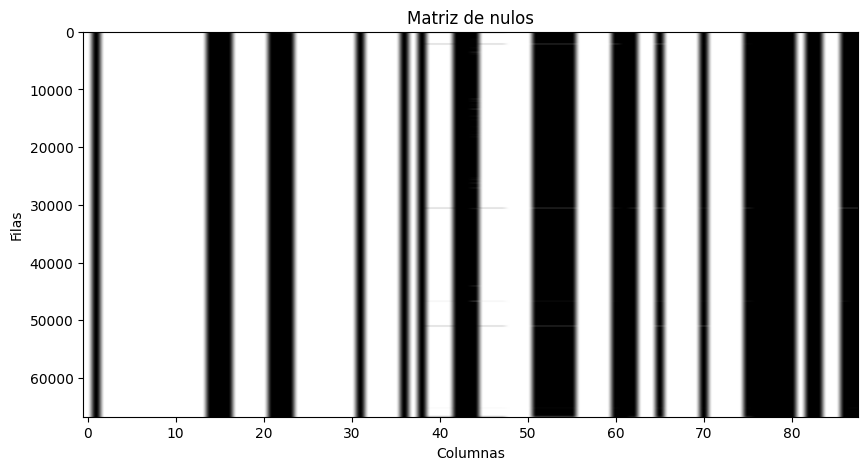

Resumen de tipos de columnas:


,tipo,nulos_%,cardinalidad
crowdflower_id,object,0.0000,133
trusted_answers,float64,0.9993,1
last_answer_at,object,0.0000,44
class,object,0.0000,4
class_confidence,object,0.0000,14
...,...,...,...
following,float64,1.0000,0
updated,object,0.0000,15742
crawled_at,object,0.0000,15624
test_set_1,float64,0.9994,2


Problemas detectados: ['Alta proporción de nulos en trusted_answers: 99.9%', 'Alta proporción de nulos en answers_count: 100.0%', 'Alta proporción de nulos en gold_count: 100.0%', 'Alta proporción de nulos en missed_gold_count: 100.0%', 'Alta proporción de nulos en trust_overall: 100.0%', 'Alta proporción de nulos en submission_rate: 100.0%', 'Alta proporción de nulos en trust: 99.8%', 'Alta proporción de nulos en truncated: 100.0%', 'Alta proporción de nulos en geo: 100.0%', 'Alta proporción de nulos en contributors: 100.0%', 'Alta proporción de nulos en favorited: 100.0%', 'Alta proporción de nulos en retweeted: 100.0%', 'Alta proporción de nulos en possibly_sensitive: 99.6%', 'Alta proporción de nulos en statuses_count: 99.8%', 'Alta proporción de nulos en followers_count: 99.8%', 'Alta proporción de nulos en friends_count: 99.8%', 'Alta proporción de nulos en favourites_count: 99.8%', 'Alta proporción de nulos en listed_count: 99.8%', 'Alta proporción de nulos en default_profile: 9

In [31]:
# --- 04. Verificación de integridad y auditoría estructural
# Diagnóstico previo: schema, nulos, duplicados, cardinalidad, tipos y rangos

import numpy as np
import pandas as pd
import json
from collections import Counter

# --- Variables de salida
integrity_report = {}
schema_profile = {}

# --- Auditoría de variables y tipos
schema_profile['column_types'] = df_raw.dtypes.apply(lambda x: str(x)).to_dict()
schema_profile['n_columns'] = df_raw.shape[1]
schema_profile['n_rows'] = df_raw.shape[0]
schema_profile['columns'] = list(df_raw.columns)

# --- Matriz de nulos y resumen
nulls = df_raw.isnull().sum().to_dict()
nulls_pct = df_raw.isnull().mean().round(4).to_dict()
schema_profile['nulls'] = nulls
schema_profile['nulls_pct'] = nulls_pct

# --- Duplicados
n_dupes = df_raw.duplicated().sum()
schema_profile['n_duplicates'] = int(n_dupes)

# --- Cardinalidad y valores únicos
cardinality = {col: df_raw[col].nunique() for col in df_raw.columns}
schema_profile['cardinality'] = cardinality

# --- Rango de valores para columnas numéricas
num_ranges = {}
for col in df_raw.select_dtypes(include=[np.number]).columns:
    num_ranges[col] = {
        'min': float(df_raw[col].min()),
        'max': float(df_raw[col].max()),
        'mean': float(df_raw[col].mean()),
        'std': float(df_raw[col].std())
    }
schema_profile['numeric_ranges'] = num_ranges

# --- Unicidad de claves (si existe columna id o user_id)
id_like_cols = [c for c in df_raw.columns if 'id' in c]
unique_keys = {col: df_raw[col].is_unique for col in id_like_cols}
schema_profile['unique_keys'] = unique_keys

# --- Tipos mixtos (columnas object con tipos mezclados)
def detect_mixed_types(series):
    types = series.dropna().map(type).apply(lambda x: x.__name__).value_counts()
    return dict(types)
mixed_types = {col: detect_mixed_types(df_raw[col]) for col in df_raw.select_dtypes(include='object').columns}
schema_profile['mixed_types'] = mixed_types

# --- Construir reporte de integridad
integrity_report['schema_profile'] = schema_profile
integrity_report['problems'] = []

# --- Reglas de calidad y problemas detectados
for col, pct in nulls_pct.items():
    if pct > 0.5:
        integrity_report['problems'].append(f'Alta proporción de nulos en {col}: {pct*100:.1f}%')
for col, unique in unique_keys.items():
    if not unique:
        integrity_report['problems'].append(f'La columna {col} no es única')
for col, mix in mixed_types.items():
    if len(mix) > 1:
        integrity_report['problems'].append(f'Tipos mixtos en columna {col}: {mix}')
if n_dupes > 0:
    integrity_report['problems'].append(f'Filas duplicadas detectadas: {n_dupes}')

# --- Función helper para convertir tipos NumPy a Python nativos
def convert_types_for_json(obj):
    """Convierte objetos NumPy y otros tipos no serializables a tipos JSON nativos."""
    if isinstance(obj, dict):
        return {k: convert_types_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_types_for_json(item) for item in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

# --- Guardar reportes con conversión de tipos
with open('integrity_report.json', 'w') as f:
    json.dump(convert_types_for_json(integrity_report), f, indent=2)
with open('schema_snapshot.json', 'w') as f:
    json.dump(convert_types_for_json(schema_profile), f, indent=2)

# --- Visualización rápida: matriz de nulos y resumen de tipos
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.imshow(df_raw.isnull(), aspect='auto', cmap='gray_r')
plt.title('Matriz de nulos')
plt.xlabel('Columnas')
plt.ylabel('Filas')
plt.show()

print('Resumen de tipos de columnas:')
display(pd.DataFrame({'tipo': df_raw.dtypes.astype(str), 'nulos_%': nulls_pct, 'cardinalidad': cardinality}))
print('Problemas detectados:', integrity_report['problems'])


## 05. Exploracion inicial y perfilado automatico
- Nombre exacto de la seccion: Exploracion inicial y perfilado automatico
- Objetivo tecnico: Obtener una vista general y automatizada del dataset
- Subsecciones / bloques: Exploracion inicial; Perfilado automatico del dataset
- Tipo de codigo: Resumenes estadisticos, profiling tools
- Datos entran: `df_raw`
- Datos salen: `eda_overview`, `profile_report`
- Visualizaciones: Histogramas basicos, distribucion de nulos
- Metricas: Conteos, cardinalidad, % nulos
- Validaciones: Verificar tamanios esperados
- Transformaciones: No aplica (solo lectura)
- Errores a controlar: Muestreo sesgado, limites de memoria
- Resultados a guardar: `profile_report.html`
- Artefactos a exportar: `eda_overview.json`
- Variables sugeridas: `eda_overview`, `profile_report`
- Checkpoint / cache: Guardar reportes de profiling
- Notas de modularizacion: Helper `run_profiling(df)`
- Reproducibilidad: Registrar version de herramienta de profiling
- Placeholder: agregar codigo en la celda inferior para EDA inicial

EDA overview guardado en: output\artifacts\eda_overview_20260522_143308.json


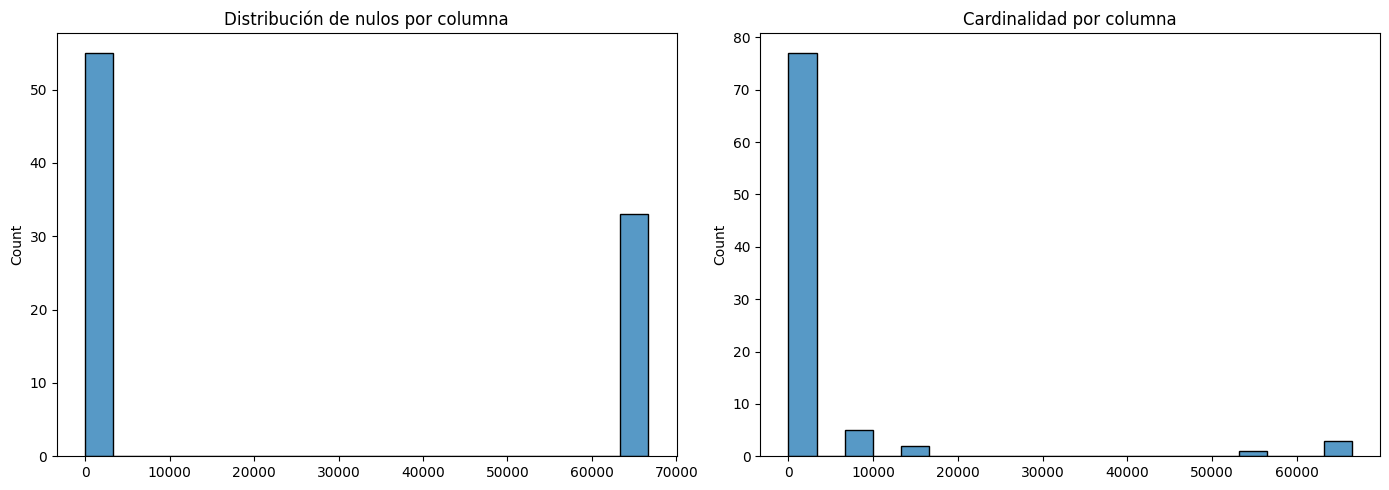

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 12.33it/s]

Profile report guardado en: output\artifacts\profile_report_20260522_143308.html
Versión de profiling: 4.18.4


In [32]:
# 05. Exploración inicial y perfilado automático
# Objetivo: Obtener una vista general y automatizada del dataset
# Entradas: df_raw
# Salidas: eda_overview, profile_report
# Artefactos: eda_overview.json, profile_report.html

import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Helper para serialización segura
from typing import Any

def safe_json(obj: Any):
    import numpy as np
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    elif isinstance(obj, (set,)):
        return list(obj)
    elif isinstance(obj, (bytes,)):
        return obj.decode()
    elif hasattr(obj, 'isoformat'):
        return obj.isoformat()
    return str(obj)

# Exploración inicial
eda_overview = {
    'shape': df_raw.shape,
    'columns': list(df_raw.columns),
    'dtypes': df_raw.dtypes.astype(str).to_dict(),
    'nulls': df_raw.isnull().sum().to_dict(),
    'nulls_pct': (df_raw.isnull().mean()*100).round(2).to_dict(),
    'n_unique': df_raw.nunique().to_dict(),
    'memory_MB': round(df_raw.memory_usage(deep=True).sum() / 1024**2, 2),
}

# Validación de tamaño esperado
assert eda_overview['shape'][0] > 0, "El DataFrame está vacío"

# Guardar resumen EDA
eda_overview_path = ARTIFACTS_DIR / f"eda_overview_{RUN_ID}.json"
with open(eda_overview_path, "w", encoding="utf-8") as f:
    json.dump(eda_overview, f, indent=2, default=safe_json)
print(f"EDA overview guardado en: {eda_overview_path}")

# Visualizaciones básicas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_raw.isnull().sum(), ax=axes[0], bins=20)
axes[0].set_title('Distribución de nulos por columna')
sns.histplot(df_raw.nunique(), ax=axes[1], bins=20)
axes[1].set_title('Cardinalidad por columna')
plt.tight_layout()
plt.show()

# Perfilado automático (usando pandas-profiling o ydata-profiling)
try:
    import ydata_profiling as profiling
    profile_report = profiling.ProfileReport(df_raw, title="Profile Report", minimal=True)
    profile_report_path = ARTIFACTS_DIR / f"profile_report_{RUN_ID}.html"
    profile_report.to_file(profile_report_path)
    print(f"Profile report guardado en: {profile_report_path}")
    print(f"Versión de profiling: {profiling.__version__}")
except ImportError:
    print("ydata_profiling no está instalado. Instala con: pip install ydata-profiling")
    profile_report = None

# Helper para modularización
# def run_profiling(df):
#     ... # Implementar lógica de profiling modular aquí


## 06. Limpieza de datos y estandarizacion
- Nombre exacto de la seccion: Limpieza de datos y estandarizacion
- Objetivo tecnico: Corregir nulos, duplicados y tipos para un dataset limpio
- Subsecciones / bloques: Limpieza de datos; Manejo de nulos; Manejo de duplicados; Conversion de tipos; Estandarizacion
- Tipo de codigo: Imputacion, filtros, cast de tipos, normalizacion
- Datos entran: `df_raw`
- Datos salen: `df_clean`
- Visualizaciones: Antes/despues de nulos y duplicados
- Metricas: % nulos por columna, filas removidas
- Validaciones: Tipos esperados, integridad de clave
- Transformaciones: Imputacion, drop duplicates, renombrado columnas
- Errores a controlar: Sobre-limpieza, perdida de target
- Resultados a guardar: `cleaning_log.csv`
- Artefactos a exportar: `df_clean.parquet`
- Variables sugeridas: `df_clean`, `null_report`
- Checkpoint / cache: Guardar `df_clean` al cerrar la etapa
- Notas de modularizacion: Funcion `clean_data(df)`
- Reproducibilidad: Loggear reglas de limpieza
- Placeholder: agregar codigo en la celda inferior para limpieza

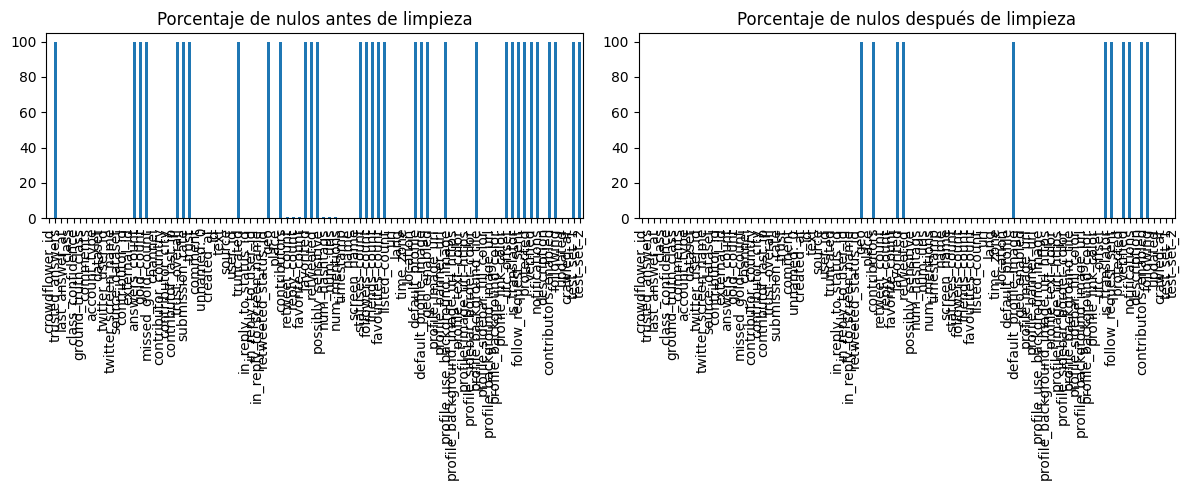

Limpieza completada. Filas finales: 66691


In [33]:
# 06. Limpieza de datos y estandarizacion
# Objetivo: Corregir nulos, duplicados y tipos para un dataset limpio
# Entradas: df_raw
# Salidas: df_clean, null_report
# Artefactos: df_clean.parquet, cleaning_log.csv

import pandas as pd
import numpy as np
import logging

# --- Helper de limpieza modular
def clean_data(df):
    cleaning_log = []
    df_clean = df.copy()
    # 1. Reporte inicial de nulos
    null_report = df_clean.isnull().mean().round(4) * 100
    cleaning_log.append({'accion': 'reporte_nulos_inicial', 'null_pct': null_report.to_dict()})
    # 2. Imputación básica: nulos numéricos a mediana, nulos string a ""
    for col in df_clean.columns:
        if df_clean[col].dtype in [np.float64, np.int64]:
            n_null = df_clean[col].isnull().sum()
            if n_null > 0:
                mediana = df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(mediana)
                cleaning_log.append({'accion': 'imputacion_mediana', 'columna': col, 'valor': mediana, 'nulos_corregidos': int(n_null)})
        elif df_clean[col].dtype == object:
            n_null = df_clean[col].isnull().sum()
            if n_null > 0:
                df_clean[col] = df_clean[col].fillna("")
                cleaning_log.append({'accion': 'imputacion_vacio', 'columna': col, 'nulos_corregidos': int(n_null)})
    # 3. Remover duplicados
    n_dupes = df_clean.duplicated().sum()
    if n_dupes > 0:
        df_clean = df_clean.drop_duplicates().reset_index(drop=True)
        cleaning_log.append({'accion': 'remover_duplicados', 'filas_removidas': int(n_dupes)})
    # 4. Conversión de tipos (ejemplo: columnas numéricas mal tipadas)
    for col in df_clean.columns:
        if df_clean[col].dtype == object:
            try:
                df_clean[col] = pd.to_numeric(df_clean[col])
                cleaning_log.append({'accion': 'cast_a_numerico', 'columna': col})
            except Exception:
                pass
    # 5. Estandarización de nombres de columnas
    old_cols = list(df_clean.columns)
    df_clean.columns = [c.strip().lower().replace(' ', '_') for c in df_clean.columns]
    cleaning_log.append({'accion': 'estandarizar_columnas', 'antes': old_cols, 'despues': list(df_clean.columns)})
    # 6. Reporte final de nulos
    null_report_final = df_clean.isnull().mean().round(4) * 100
    cleaning_log.append({'accion': 'reporte_nulos_final', 'null_pct': null_report_final.to_dict()})
    return df_clean, null_report, cleaning_log

# --- Aplicar limpieza y guardar artefactos
df_clean, null_report, cleaning_log = clean_data(df_raw)

# Guardar log de limpieza
pd.DataFrame(cleaning_log).to_csv('cleaning_log.csv', index=False)
# Guardar dataset limpio
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_clean.to_parquet('output/df_clean.parquet', index=False)

# Visualización antes/después de nulos y duplicados
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
null_report.plot(kind='bar', ax=axes[0], title='Porcentaje de nulos antes de limpieza')
df_clean.isnull().mean().round(4).mul(100).plot(kind='bar', ax=axes[1], title='Porcentaje de nulos después de limpieza')
plt.tight_layout()
plt.show()

print(f"Limpieza completada. Filas finales: {df_clean.shape[0]}")


## 07. Parsing temporal y normalizacion de timestamps
- Nombre exacto de la seccion: Parsing temporal y normalizacion de timestamps
- Objetivo tecnico: Unificar fechas y derivar columnas temporales confiables
- Subsecciones / bloques: Parsing temporal; Normalizacion de zona horaria; Derivacion de features base
- Tipo de codigo: Parsing datetime, time zone handling, feature derivation
- Datos entran: `df_clean`
- Datos salen: `df_time`
- Visualizaciones: Series temporales de actividad
- Metricas: Tasa de parseo correcto, % fechas invalidas
- Validaciones: Rangos de fechas, timezone consistente
- Transformaciones: Cast a datetime, bins temporales
- Errores a controlar: Formatos mixtos, timezone perdida
- Resultados a guardar: `time_parse_report.json`
- Artefactos a exportar: `df_time.parquet`
- Variables sugeridas: `time_cols`, `df_time`
- Checkpoint / cache: Guardar dataset con timestamps normalizados
- Notas de modularizacion: Funcion `parse_time_columns(df)`
- Reproducibilidad: Loggear formato y timezone usados
- Placeholder: agregar codigo en la celda inferior para parsing

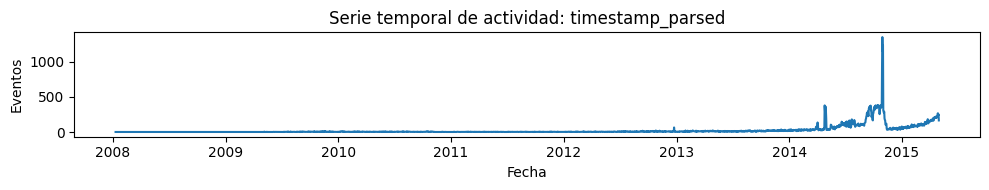

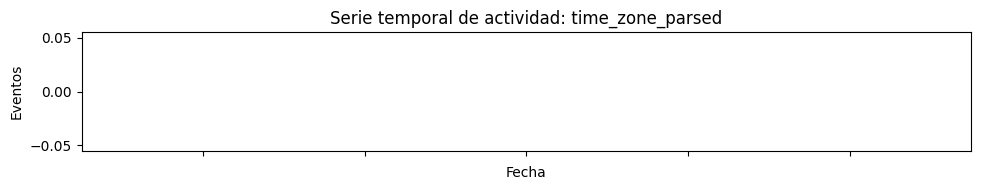

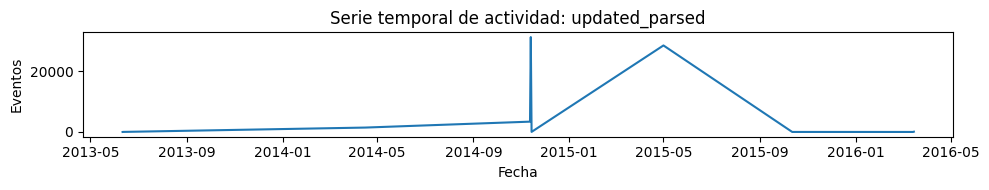

Parsing temporal completado. Columnas procesadas: ['timestamp', 'time_zone', 'updated']


In [34]:
# 07. Parsing temporal y normalizacion de timestamps
# Objetivo: Unificar fechas y derivar columnas temporales confiables
# Entradas: df_clean
# Salidas: df_time, time_parse_report
# Artefactos: df_time.parquet, time_parse_report.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helper para parsing y normalización temporal
def parse_time_columns(df, time_zone='UTC'):
    df_time = df.copy()
    time_cols = [col for col in df_time.columns if 'date' in col or 'time' in col or 'fecha' in col]
    parse_report = {'col': [], 'parsed_pct': [], 'invalid_pct': [], 'timezone': time_zone, 'format': 'auto'}
    for col in time_cols:
        try:
            parsed = pd.to_datetime(df_time[col], errors='coerce', utc=True)
            n_valid = parsed.notnull().sum()
            n_total = len(parsed)
            df_time[col + '_parsed'] = parsed.dt.tz_convert(time_zone) if parsed.dt.tz else parsed
            parse_report['col'].append(col)
            parse_report['parsed_pct'].append(round(100 * n_valid / n_total, 2))
            parse_report['invalid_pct'].append(round(100 * (n_total - n_valid) / n_total, 2))
        except Exception as e:
            logging.warning(f'No se pudo parsear {col}: {e}')
            parse_report['col'].append(col)
            parse_report['parsed_pct'].append(0.0)
            parse_report['invalid_pct'].append(100.0)
    # Derivar features base si hay columnas parseadas
    for col in [c for c in df_time.columns if c.endswith('_parsed')]:
        df_time[col + '_year'] = df_time[col].dt.year
        df_time[col + '_month'] = df_time[col].dt.month
        df_time[col + '_day'] = df_time[col].dt.day
        df_time[col + '_hour'] = df_time[col].dt.hour
        df_time[col + '_weekday'] = df_time[col].dt.weekday
    return df_time, time_cols, parse_report

# --- Aplicar parsing temporal y guardar artefactos
df_time, time_cols, time_parse_report = parse_time_columns(df_clean, time_zone='UTC')

# Guardar reporte de parseo
time_parse_report_path = 'time_parse_report.json'
with open(time_parse_report_path, 'w', encoding='utf-8') as f:
    json.dump(time_parse_report, f, indent=2)
# Guardar dataset con timestamps normalizados
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_time.to_parquet('output/df_time.parquet', index=False)

# Visualización: series temporales de actividad (si hay columnas parseadas)
import matplotlib.pyplot as plt
parsed_cols = [c for c in df_time.columns if c.endswith('_parsed')]
if parsed_cols:
    for col in parsed_cols:
        plt.figure(figsize=(10,2))
        df_time[col].dropna().dt.date.value_counts().sort_index().plot()
        plt.title(f'Serie temporal de actividad: {col}')
        plt.xlabel('Fecha')
        plt.ylabel('Eventos')
        plt.tight_layout()
        plt.show()
else:
    print('No se encontraron columnas temporales parseadas.')

print(f"Parsing temporal completado. Columnas procesadas: {time_cols}")



## 08. Extracción y normalización de variables categóricas

**Objetivo técnico:** Unificar, limpiar y codificar variables categóricas clave para análisis y modelado.

- **Subsecciones / bloques:** Extracción de variables categóricas; limpieza y normalización; agrupación de categorías poco frecuentes; codificación básica.
- **Tipo de código:** Limpieza de strings, reemplazo de nulos, agrupación de categorías, reporte de cardinalidad y frecuencia.
- **Datos entran:** `df_time`
- **Datos salen:** `df_cat`, `cat_cols`, `cat_report`
- **Visualizaciones:** Distribución de las principales categorías por variable
- **Métricas:** Cardinalidad, top categorías, frecuencia de nulos/otros
- **Validaciones:** Cardinalidad esperada, presencia de valores vacíos
- **Transformaciones:** Limpieza de strings, agrupación de categorías raras, reemplazo de nulos
- **Errores a controlar:** Pérdida de información relevante, sobre-agregación
- **Resultados a guardar:** `cat_report.json`
- **Artefactos a exportar:** `df_cat.parquet`
- **Variables sugeridas:** `df_cat`, `cat_cols`, `cat_report`
- **Checkpoint / cache:** Guardar dataset categórico procesado
- **Notas de modularización:** Función `process_categorical_columns(df)`
- **Reproducibilidad:** Loggear reglas de limpieza y agrupación
- **Placeholder:** El código de procesamiento categórico se encuentra en la celda inferior


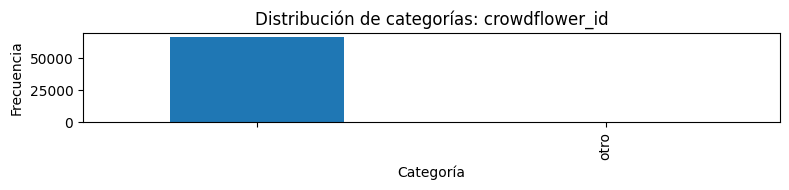

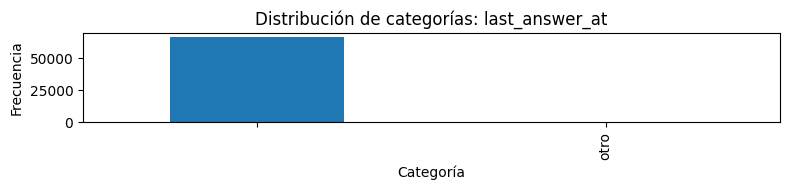

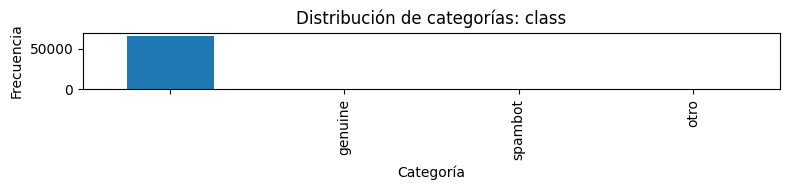

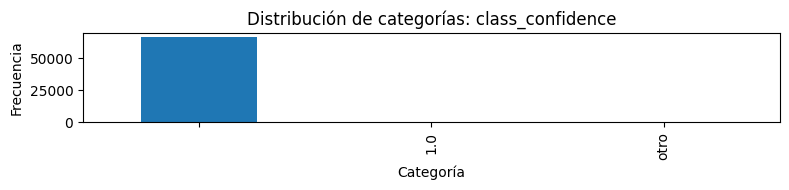

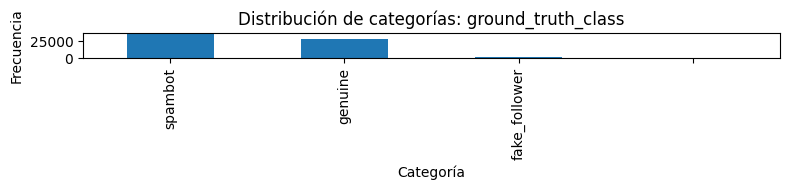

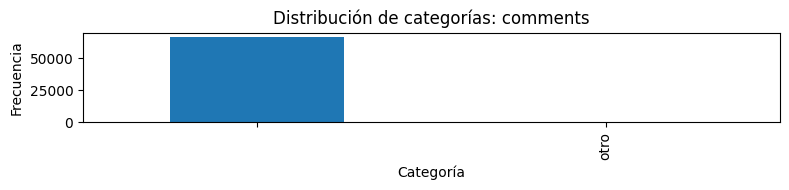

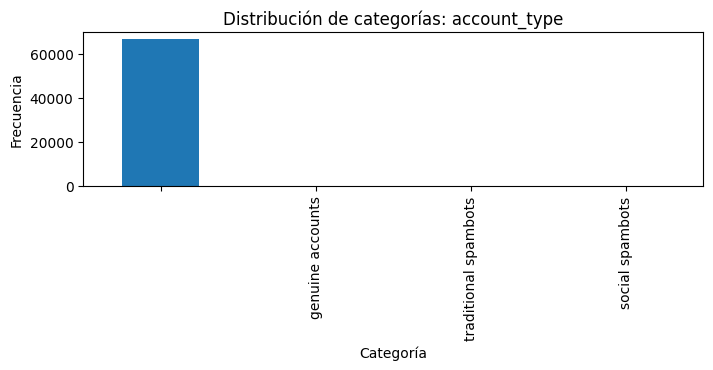

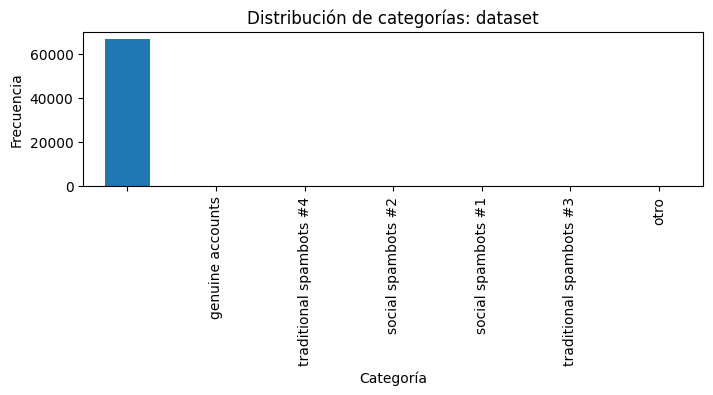

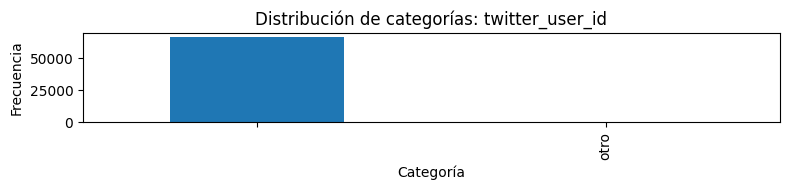

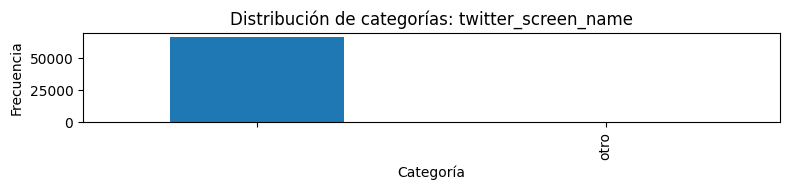

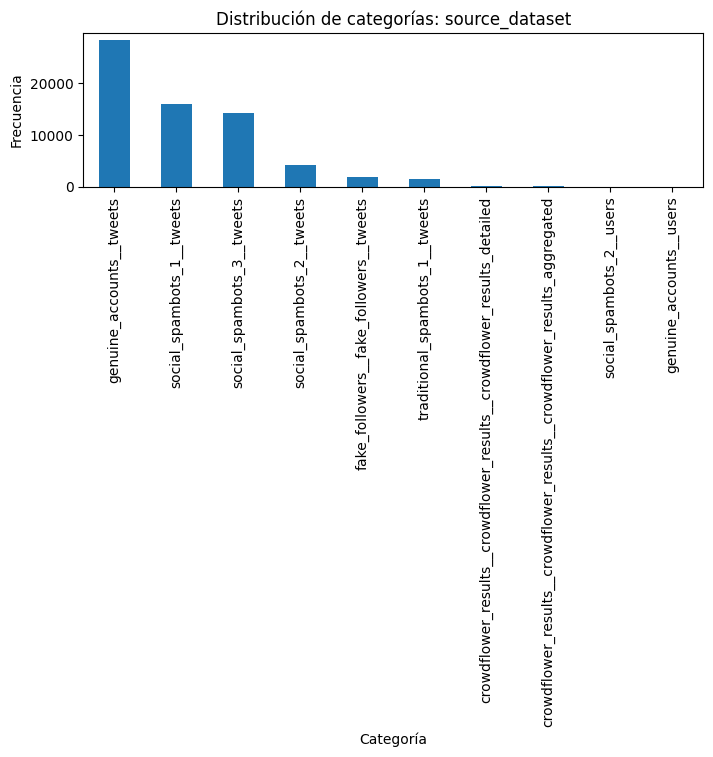

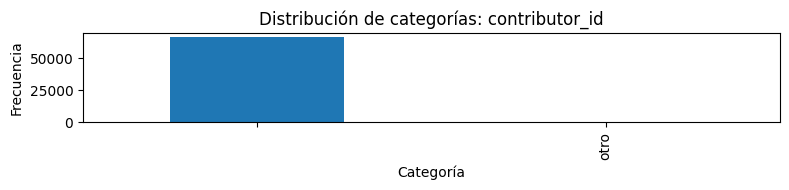

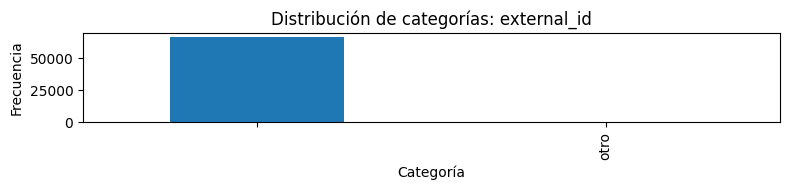

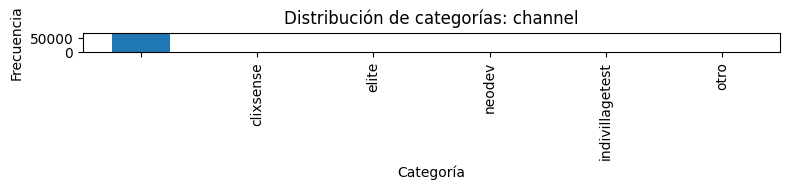

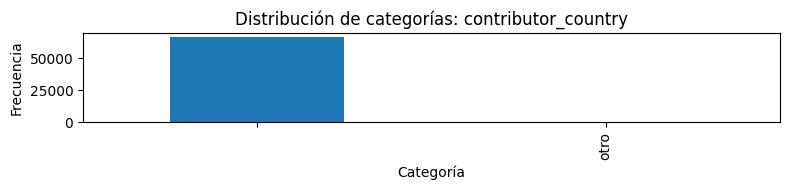

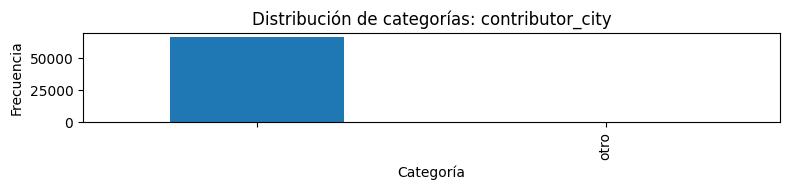

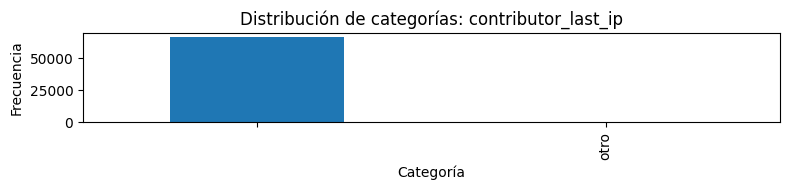

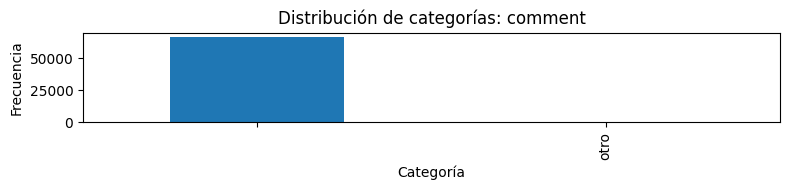

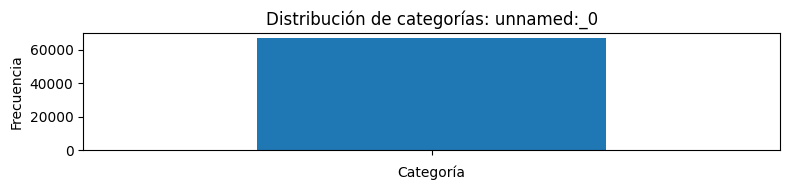

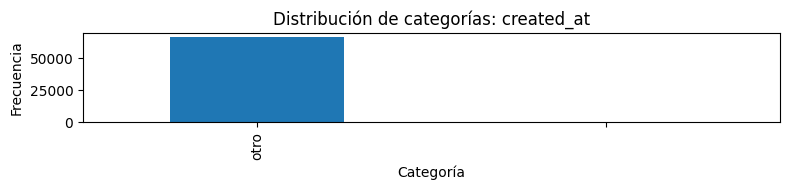

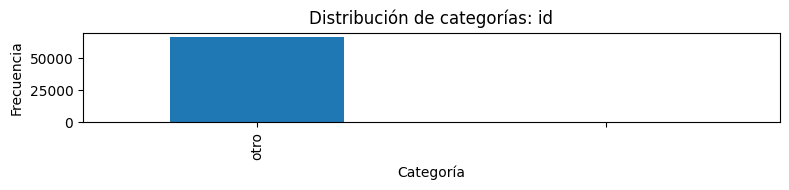

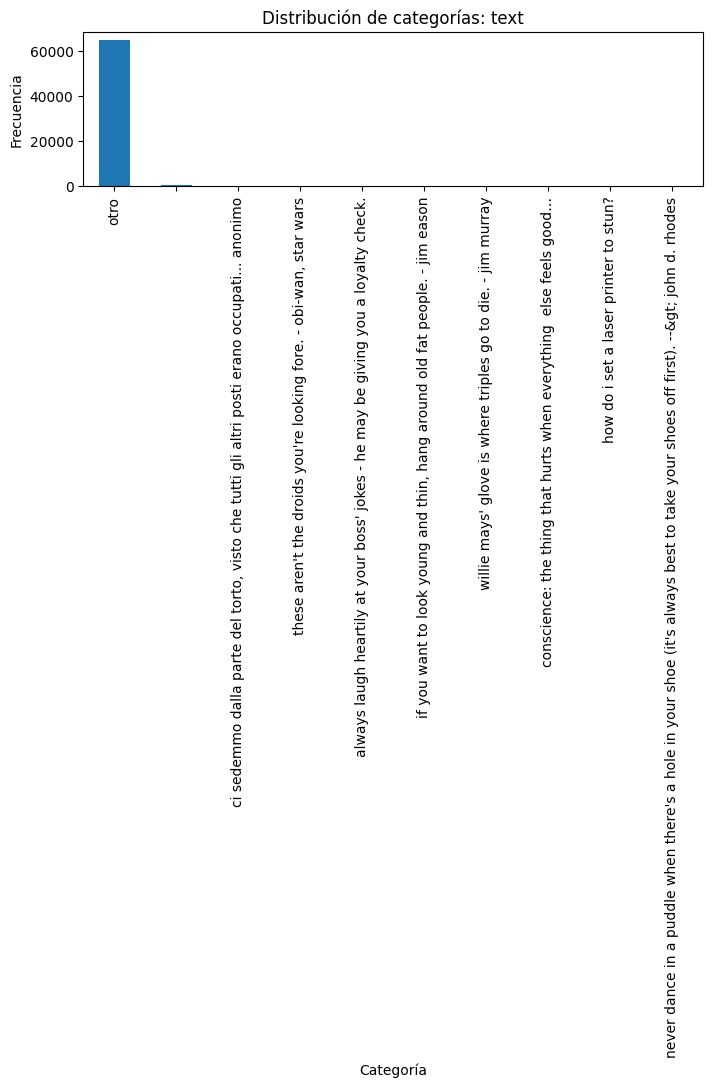

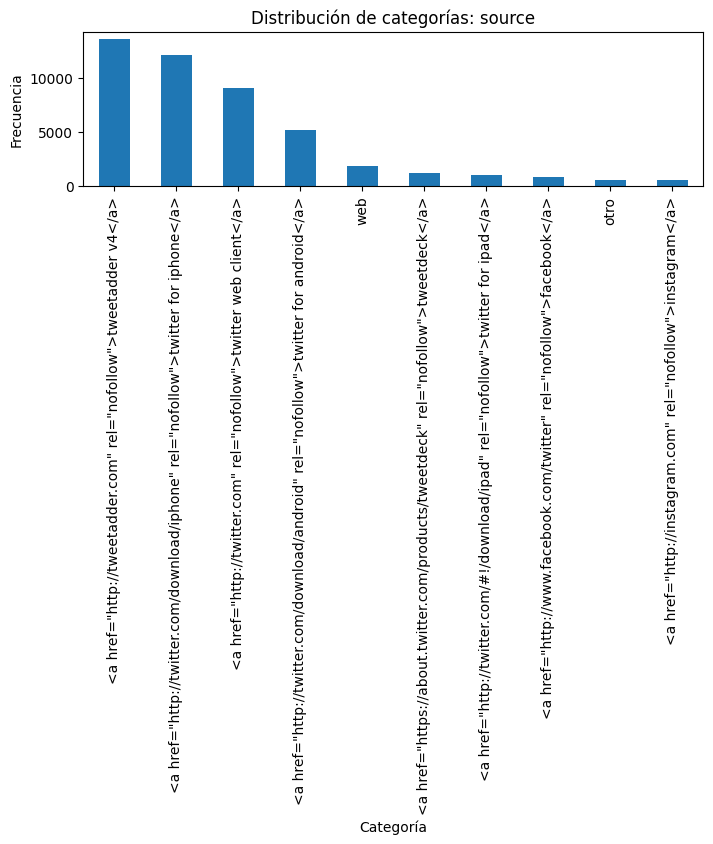

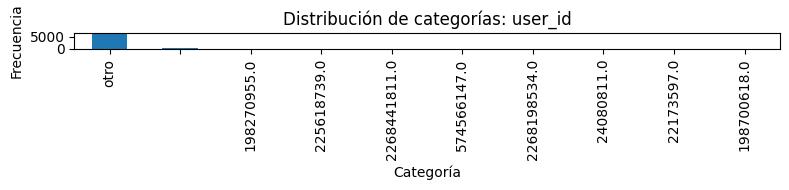

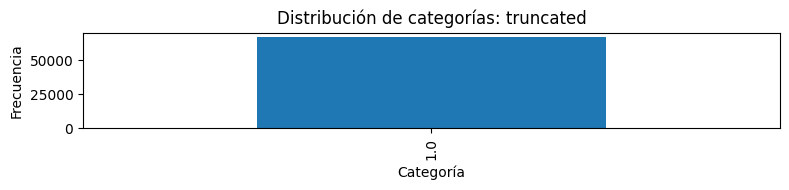

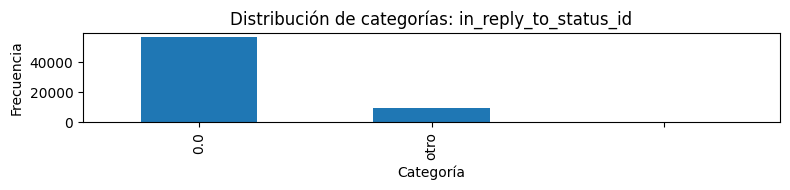

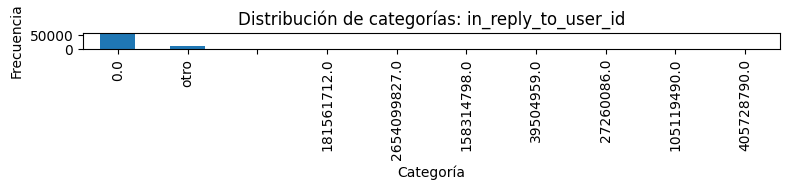

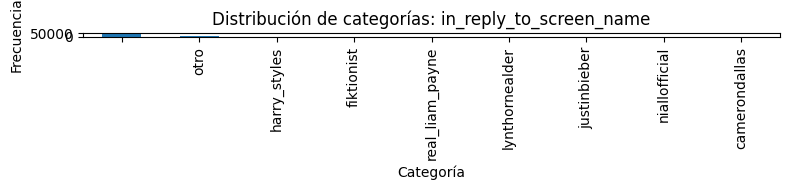

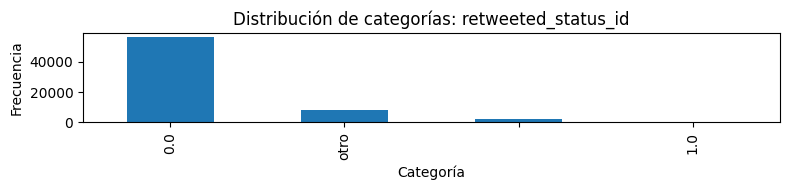

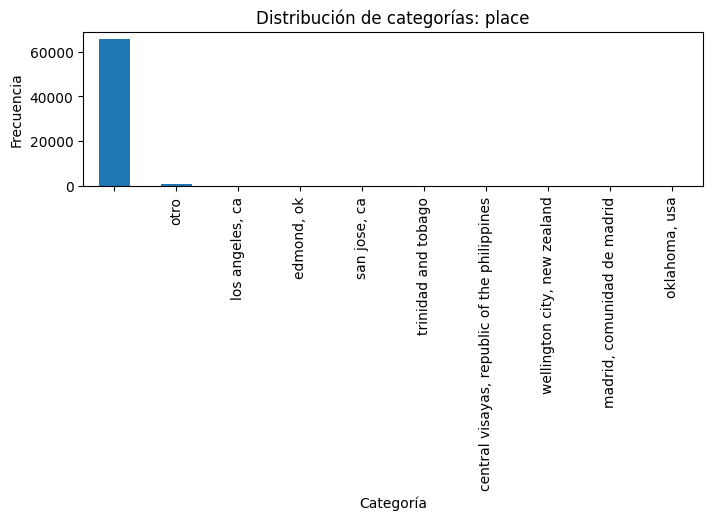

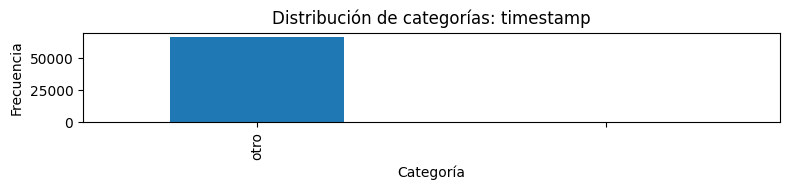

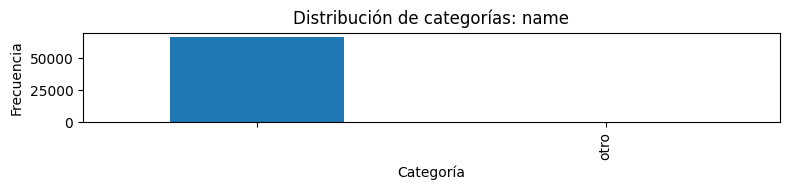

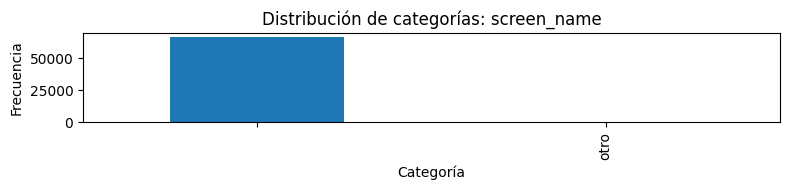

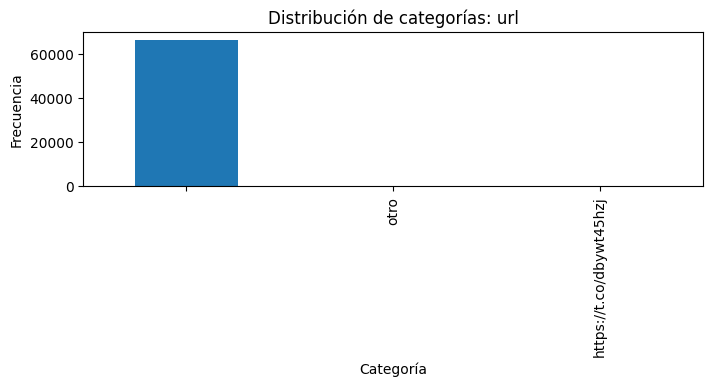

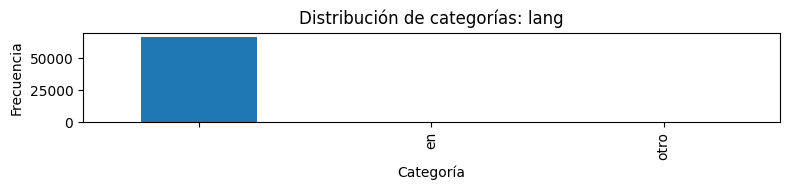

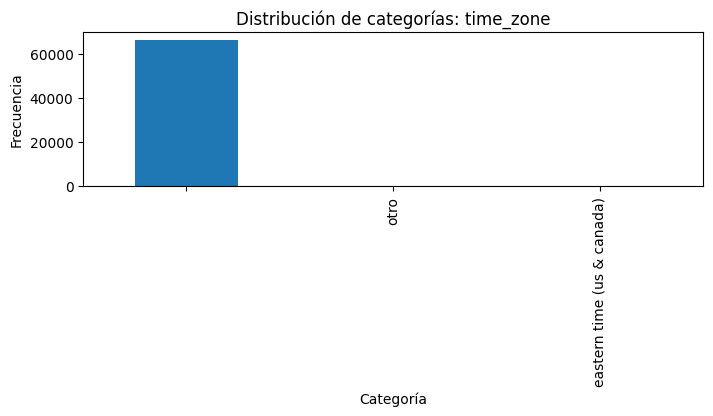

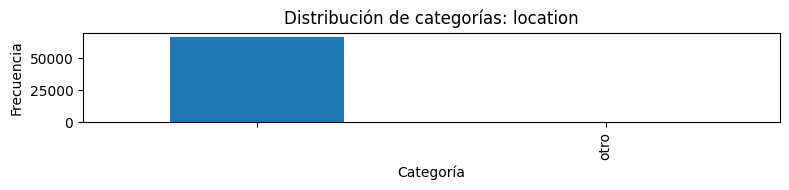

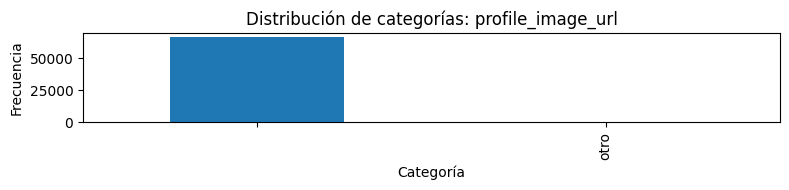

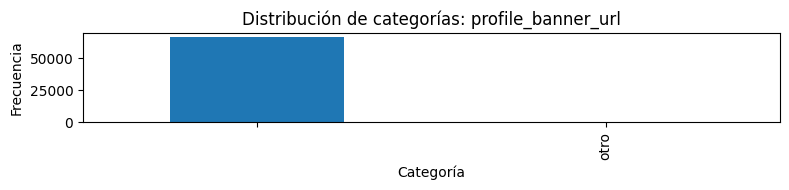

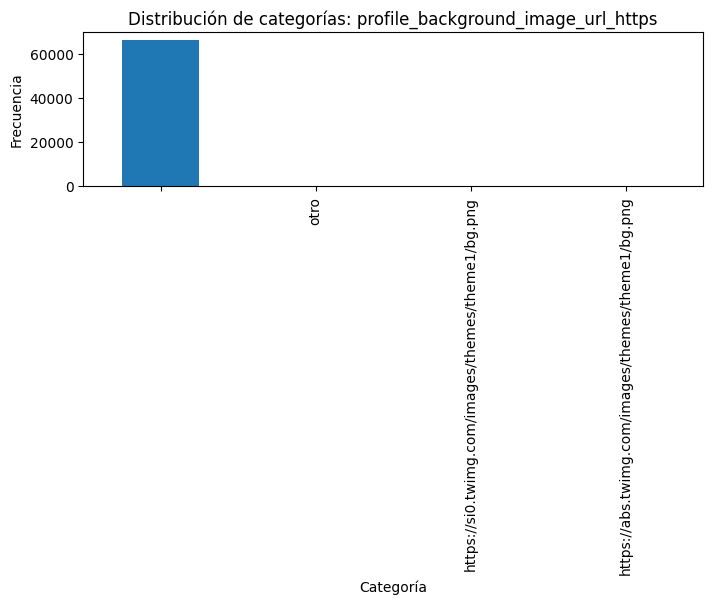

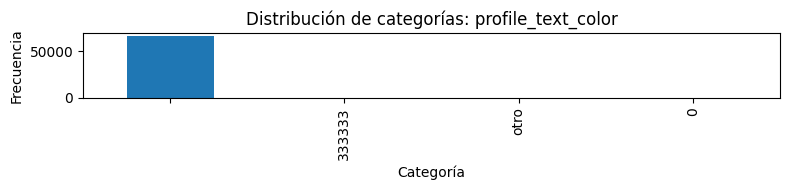

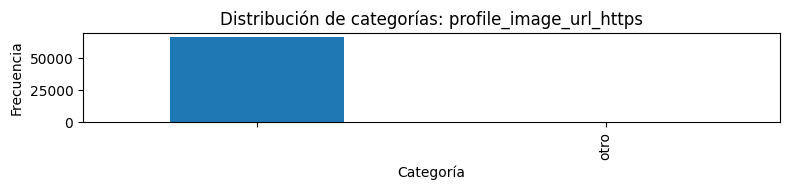

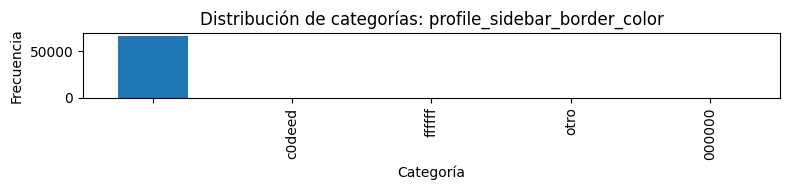

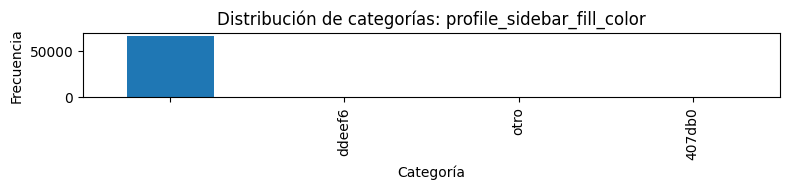

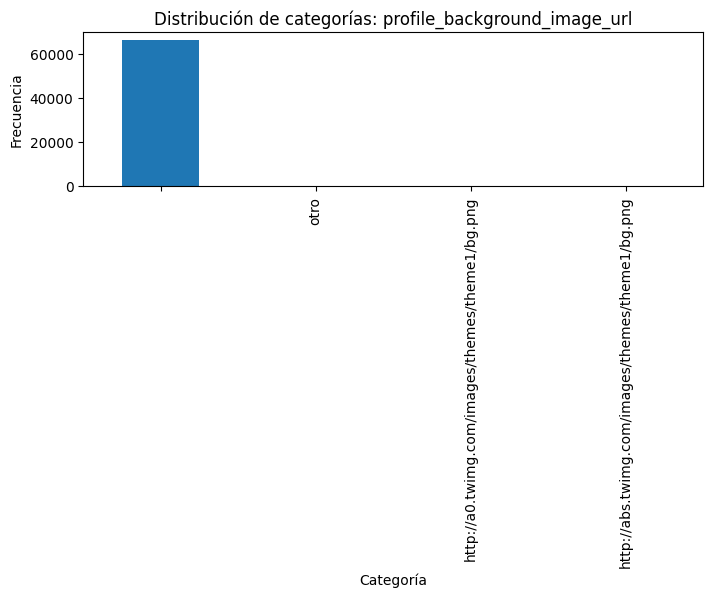

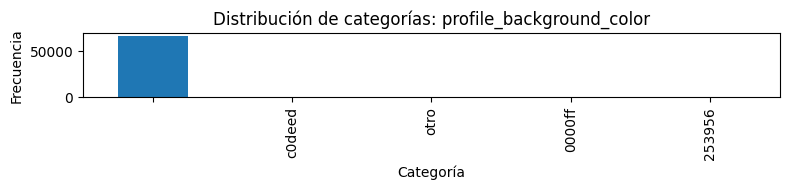

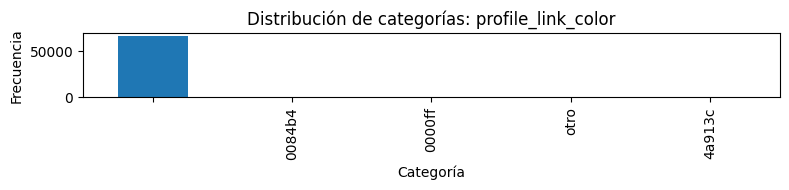

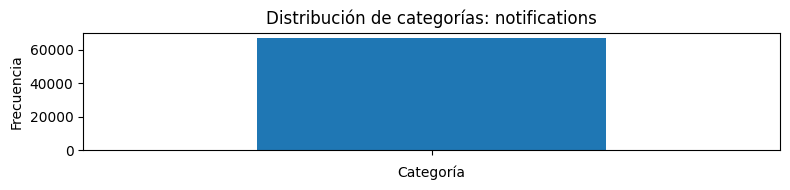

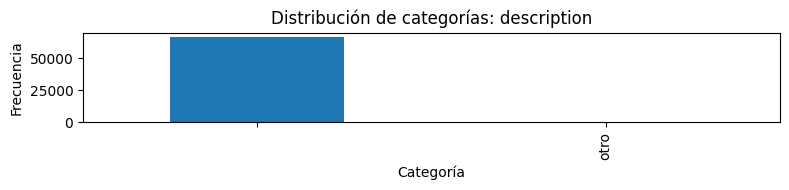

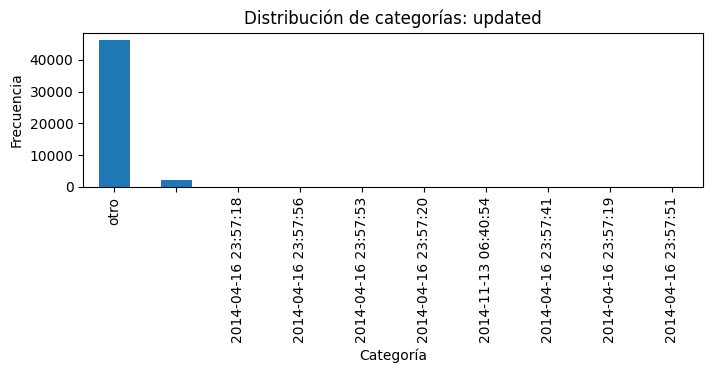

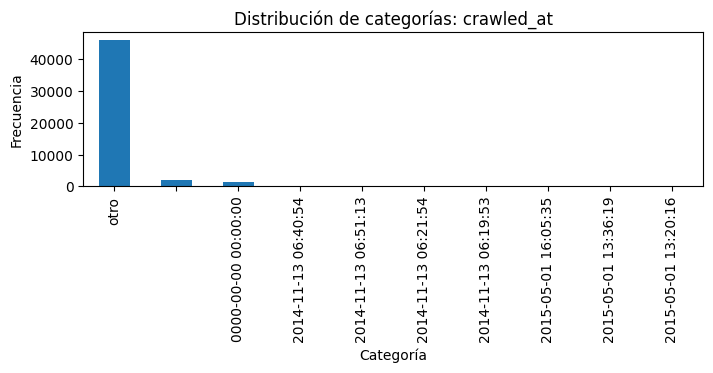

Procesamiento categórico completado. Columnas procesadas: ['crowdflower_id', 'last_answer_at', 'class', 'class_confidence', 'ground_truth_class', 'comments', 'account_type', 'dataset', 'twitter_user_id', 'twitter_screen_name', 'source_dataset', 'contributor_id', 'external_id', 'channel', 'contributor_country', 'contributor_city', 'contributor_last_ip', 'comment', 'unnamed:_0', 'created_at', 'id', 'text', 'source', 'user_id', 'truncated', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'retweeted_status_id', 'place', 'timestamp', 'name', 'screen_name', 'url', 'lang', 'time_zone', 'location', 'profile_image_url', 'profile_banner_url', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'notifications', 'description', 'updated', 'crawled_at']


In [35]:
# 08. Extracción y normalización de variables categóricas
# Objetivo: Unificar, limpiar y codificar variables categóricas clave para análisis y modelado
# Entradas: df_time
# Salidas: df_cat, cat_report
# Artefactos: df_cat.parquet, cat_report.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helper para extracción y limpieza de variables categóricas
def process_categorical_columns(df, min_freq=10):
    df_cat = df.copy()
    cat_cols = [col for col in df_cat.columns if df_cat[col].dtype == object or 'cat' in col or 'label' in col]
    cat_report = {'col': [], 'n_unique': [], 'top_values': [], 'n_invalid': []}
    for col in cat_cols:
        # Limpieza básica: quitar espacios, pasar a minúsculas, reemplazar nulos
        df_cat[col] = df_cat[col].astype(str).str.strip().str.lower().replace({'nan': '', 'none': ''})
        # Agrupar categorías poco frecuentes
        value_counts = df_cat[col].value_counts()
        rare = value_counts[value_counts < min_freq].index
        df_cat[col] = df_cat[col].replace(rare, 'otro')
        cat_report['col'].append(col)
        cat_report['n_unique'].append(df_cat[col].nunique())
        cat_report['top_values'].append(df_cat[col].value_counts().head(5).to_dict())
        cat_report['n_invalid'].append((df_cat[col] == '').sum())
    return df_cat, cat_cols, cat_report

# --- Aplicar procesamiento categórico y guardar artefactos
df_cat, cat_cols, cat_report = process_categorical_columns(df_time)

# Guardar reporte de categorías (serializar tipos no nativos de JSON)
cat_report_path = 'cat_report.json'
with open(cat_report_path, 'w', encoding='utf-8') as f:
    # convert_types_for_json defined earlier in the notebook (cell 8)
    json.dump(convert_types_for_json(cat_report), f, indent=2)

# Guardar dataset con variables categóricas procesadas
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
df_cat.to_parquet('output/df_cat.parquet', index=False)

# Visualización: distribución de las principales categorías
import matplotlib.pyplot as plt
for col in cat_cols:
    plt.figure(figsize=(8,2))
    df_cat[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Distribución de categorías: {col}')
    plt.xlabel('Categoría')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

print(f"Procesamiento categórico completado. Columnas procesadas: {cat_cols}")

## 09. Extraccion de features conductuales
- Nombre exacto de la seccion: Extraccion de features conductuales
- Objetivo tecnico: Generar features de comportamiento y de interaccion bot/humano
- Subsecciones / bloques: Features de actividad; Metricas de inmersion/interaccion; Agregaciones por usuario
- Tipo de codigo: Aggregations, ratios, ventanas de tiempo
- Datos entran: `df_time` y/o `df_text`
- Datos salen: `feat_behavioral`
- Visualizaciones: Distribuciones de ratios y tasas de actividad
- Metricas: Posts por dia, ratio RT, ratio follower/following
- Validaciones: Rango de ratios, divisiones por cero
- Transformaciones: Agregacion por usuario, normalizacion de tasas
- Errores a controlar: Sesgo por usuarios inactivos
- Resultados a guardar: `features_behavioral.parquet`
- Artefactos a exportar: `behavioral_feature_defs.json`
- Variables sugeridas: `feat_behavioral`, `user_id_col`
- Checkpoint / cache: Guardar features conductuales
- Notas de modularizacion: Funcion `build_behavioral_features(df)`
- Reproducibilidad: Fijar ventanas temporales y reglas de agregacion
- Placeholder: agregar codigo en la celda inferior para features conductuales

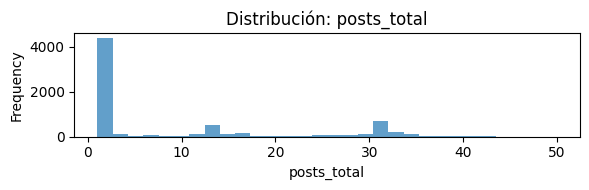

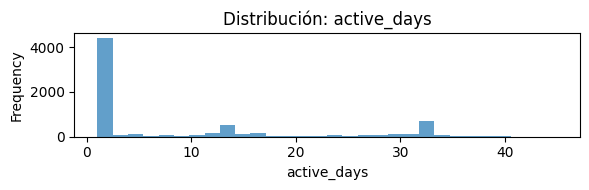

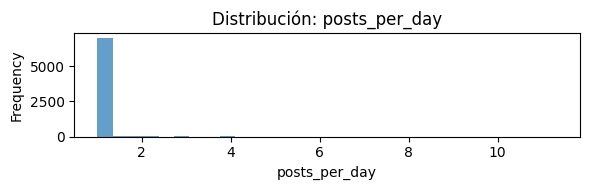

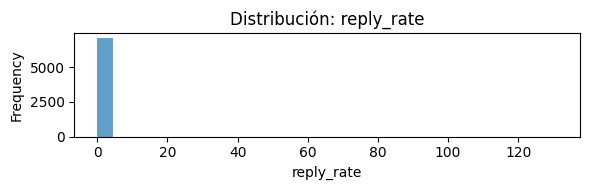

Features conductuales generados para 7144 usuarios.


In [36]:
# 09. Extraccion de features conductuales
# Objetivo: Generar features de comportamiento y de interaccion bot/humano
# Entradas: df_time (y/o df_text)
# Salidas: feat_behavioral, user_id_col
# Artefactos: features_behavioral.parquet, behavioral_feature_defs.json

import pandas as pd
import numpy as np
import json
import logging

# --- Helpers para normalizar IDs

def _normalize_user_id(series):
    s = series.astype(str).str.strip()
    s = s.replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    # quitar sufijo .0 típico cuando viene de float
    s = s.str.replace(r'\.0$', '', regex=True)
    return s

# --- Helper para extracción de features conductuales

def build_behavioral_features(df, user_id_col='user_id', time_col=None):
    feat_defs = []
    df_b = df.copy()

    if user_id_col not in df_b.columns:
        raise ValueError('No se encontró columna de usuario')

    df_b[user_id_col] = _normalize_user_id(df_b[user_id_col])
    df_b = df_b.dropna(subset=[user_id_col])

    # Si no se especifica columna temporal, buscar una
    if not time_col:
        time_col = next((c for c in df_b.columns if c.endswith('_parsed')), None)
    if not time_col:
        raise ValueError('No se encontró columna temporal')

    df_b[time_col] = pd.to_datetime(df_b[time_col], errors='coerce', utc=True)

    # Agregaciones por usuario
    grp = df_b.groupby(user_id_col, sort=False)

    posts_total = grp.size().rename('posts_total')
    active_days = grp[time_col].apply(lambda x: x.dt.date.nunique() if x.notnull().any() else 0)

    features = pd.concat([posts_total, active_days.rename('active_days')], axis=1)
    features['posts_per_day'] = features['posts_total'] / features['active_days'].replace(0, np.nan)
    feat_defs.append({'feature': 'posts_per_day', 'desc': 'Promedio de posts por día activo'})

    # Ratio RT (si existe columna retweet)
    if 'is_retweet' in df_b.columns:
        features['ratio_rt'] = grp['is_retweet'].mean()
        feat_defs.append({'feature': 'ratio_rt', 'desc': 'Proporción de retweets'})

    # Ratio follower/following (si existen)
    if 'followers_count' in df_b.columns and 'following_count' in df_b.columns:
        followers_mean = grp['followers_count'].mean()
        following_mean = grp['following_count'].mean().replace(0, np.nan)
        features['ratio_follower_following'] = followers_mean / following_mean
        feat_defs.append({'feature': 'ratio_follower_following', 'desc': 'Ratio promedio followers/following'})

    # Otras métricas de interacción
    if 'reply_count' in df_b.columns:
        features['reply_rate'] = grp['reply_count'].mean() / features['posts_total']
        feat_defs.append({'feature': 'reply_rate', 'desc': 'Tasa de respuestas por post'})

    # Normalización de tasas
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    features = features.reset_index()
    return features, feat_defs

# --- Aplicar extracción de features conductuales y guardar artefactos
feat_behavioral, behavioral_feature_defs = build_behavioral_features(df_time, user_id_col='user_id')

# Guardar definiciones y dataset
with open('behavioral_feature_defs.json', 'w', encoding='utf-8') as f:
    json.dump(behavioral_feature_defs, f, indent=2, default=globals().get('safe_json'))
import pathlib
pathlib.Path('output').mkdir(exist_ok=True)
feat_behavioral.to_parquet('output/features_behavioral.parquet', index=False)

# Visualización: distribuciones de ratios y tasas
import matplotlib.pyplot as plt
for col in feat_behavioral.columns:
    if col not in ['user_id']:
        plt.figure(figsize=(6,2))
        feat_behavioral[col].plot(kind='hist', bins=30, alpha=0.7)
        plt.title(f'Distribución: {col}')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

print(f"Features conductuales generados para {feat_behavioral.shape[0]} usuarios.")

## 10. Extraccion de features temporales
- Nombre exacto de la seccion: Extraccion de features temporales
- Objetivo tecnico: Capturar patrones temporales y ritmos de actividad
- Subsecciones / bloques: Patrones diarios/semanales; Entropia temporal; Rachas y bursts
- Tipo de codigo: Time series features, ventanas deslizantes
- Datos entran: `df_time`
- Datos salen: `feat_temporal`
- Visualizaciones: Heatmaps de actividad, series temporales
- Metricas: Entropia de tiempos, regularidad, burstiness
- Validaciones: Ventanas temporales validas
- Transformaciones: Binning temporal, agregaciones
- Errores a controlar: Timezone inconsistente, gaps
- Resultados a guardar: `features_temporal.parquet`
- Artefactos a exportar: `temporal_feature_defs.json`
- Variables sugeridas: `feat_temporal`, `time_bins`
- Checkpoint / cache: Guardar features temporales
- Notas de modularizacion: Funcion `build_temporal_features(df)`
- Reproducibilidad: Registrar granulosidad temporal usada
- Placeholder: agregar codigo en la celda inferior para features temporales

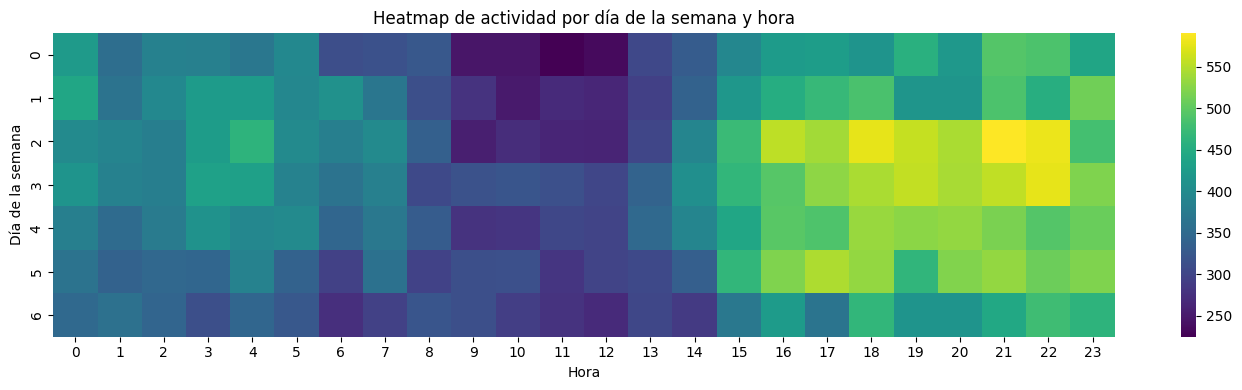

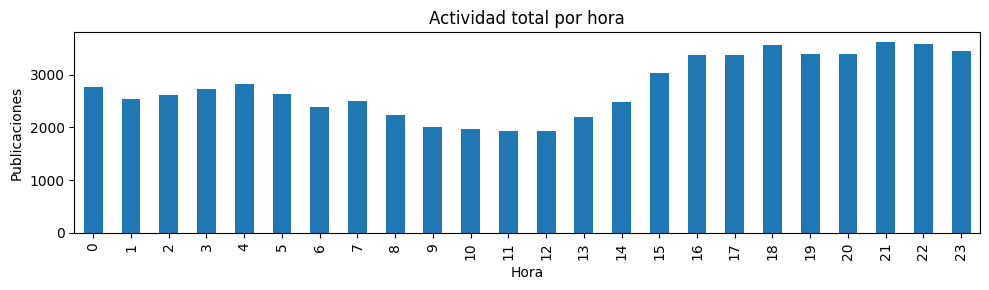

Features temporales generados para 7144 usuarios.
Columna temporal usada: timestamp_parsed
Granularidad usada: 1H


In [37]:
# 10. Extraccion de features temporales
# Objetivo: Capturar patrones temporales y ritmos de actividad
# Entradas: df_time
# Salidas: feat_temporal, time_bins
# Artefactos: features_temporal.parquet, temporal_feature_defs.json

import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


def _shannon_entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total <= 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())


def _normalize_user_id(series):
    s = series.astype(str).str.strip()
    s = s.replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    # quitar sufijo .0 típico cuando viene de float
    s = s.str.replace(r'\.0$', '', regex=True)
    return s


def build_temporal_features(df, user_id_col='user_id', time_col=None, granularity='1H'):
    df_tmp = df.copy()

    # Selección robusta de columna temporal
    if time_col is None:
        preferred = ['timestamp_parsed', 'created_at_parsed', 'updated_parsed']
        time_col = next((c for c in preferred if c in df_tmp.columns), None)
        if time_col is None:
            time_col = next((c for c in df_tmp.columns if c.endswith('_parsed')), None)

    if time_col is None or user_id_col not in df_tmp.columns:
        raise ValueError('No se encontró la columna temporal o la columna de usuario.')

    # Limpieza mínima
    df_tmp[user_id_col] = _normalize_user_id(df_tmp[user_id_col])
    df_tmp = df_tmp.dropna(subset=[user_id_col])

    df_tmp[time_col] = pd.to_datetime(df_tmp[time_col], errors='coerce', utc=True)
    df_tmp = df_tmp.dropna(subset=[time_col]).copy()

    # Variables temporales base
    df_tmp['hour'] = df_tmp[time_col].dt.hour
    df_tmp['weekday'] = df_tmp[time_col].dt.weekday
    df_tmp['date'] = df_tmp[time_col].dt.date
    df_tmp['is_weekend'] = df_tmp['weekday'].isin([5, 6]).astype(int)

    # Binning temporal global
    tmin = df_tmp[time_col].min()
    tmax = df_tmp[time_col].max()
    if pd.isna(tmin) or pd.isna(tmax):
        time_bins = pd.DatetimeIndex([])
    else:
        time_bins = pd.date_range(start=tmin.floor('D'), end=tmax.ceil('D'), freq=granularity)

    missing_bins_ratio = 0.0
    if len(time_bins) > 0:
        counts = df_tmp.set_index(time_col).resample(granularity).size()
        missing_bins_ratio = float((counts == 0).mean())

    feature_defs = [
        {'feature': 'posts_total_temporal', 'desc': 'Número total de publicaciones por usuario (temporal)'},
        {'feature': 'active_days', 'desc': 'Cantidad de días distintos con actividad'},
        {'feature': 'span_days', 'desc': 'Ventana temporal entre primera y última publicación'},
        {'feature': 'posts_per_active_day', 'desc': 'Promedio de publicaciones por día activo'},
        {'feature': 'posts_per_span_day', 'desc': 'Promedio de publicaciones por día en la ventana total'},
        {'feature': 'mean_interarrival_hours', 'desc': 'Tiempo medio entre publicaciones'},
        {'feature': 'std_interarrival_hours', 'desc': 'Desviación estándar entre publicaciones'},
        {'feature': 'burstiness', 'desc': 'Medida de rachas/bursts temporales'},
        {'feature': 'hour_entropy', 'desc': 'Entropía de actividad por hora'},
        {'feature': 'weekday_entropy', 'desc': 'Entropía de actividad por día de la semana'},
        {'feature': 'peak_hour_share', 'desc': 'Proporción de actividad en la hora más frecuente'},
        {'feature': 'peak_weekday_share', 'desc': 'Proporción de actividad en el día más frecuente'},
        {'feature': 'weekend_ratio', 'desc': 'Proporción de publicaciones en fin de semana'},
        {'feature': 'active_hours', 'desc': 'Cantidad de horas distintas con actividad'},
        {'feature': 'active_weekdays', 'desc': 'Cantidad de días de semana distintos con actividad'}
    ]

    rows = []
    grouped = df_tmp.sort_values([user_id_col, time_col]).groupby(user_id_col, sort=False)

    for user_id, g in grouped:
        ts = g[time_col].sort_values()
        n_posts = int(len(g))
        active_days = int(g['date'].nunique())

        if n_posts > 1:
            diffs_hours = ts.diff().dropna().dt.total_seconds() / 3600.0
            mean_iat = float(diffs_hours.mean()) if len(diffs_hours) else 0.0
            std_iat = float(diffs_hours.std()) if len(diffs_hours) else 0.0
        else:
            mean_iat = 0.0
            std_iat = 0.0

        span_days = float((ts.max() - ts.min()).total_seconds() / 86400.0) if n_posts > 1 else 0.0
        span_days = max(span_days, 0.0) + 1.0 if n_posts > 0 else 0.0

        posts_per_active_day = n_posts / active_days if active_days > 0 else 0.0
        posts_per_span_day = n_posts / span_days if span_days > 0 else 0.0

        burstiness = 0.0
        if (mean_iat + std_iat) > 0:
            burstiness = (std_iat - mean_iat) / (std_iat + mean_iat)

        hour_counts = g['hour'].value_counts().sort_index()
        weekday_counts = g['weekday'].value_counts().sort_index()

        hour_entropy = _shannon_entropy_from_counts(hour_counts.values)
        weekday_entropy = _shannon_entropy_from_counts(weekday_counts.values)

        peak_hour_share = float(hour_counts.max() / n_posts) if n_posts > 0 else 0.0
        peak_weekday_share = float(weekday_counts.max() / n_posts) if n_posts > 0 else 0.0

        weekend_ratio = float(g['is_weekend'].mean()) if n_posts > 0 else 0.0

        rows.append({
            user_id_col: user_id,
            'posts_total_temporal': n_posts,
            'active_days': active_days,
            'span_days': span_days,
            'posts_per_active_day': posts_per_active_day,
            'posts_per_span_day': posts_per_span_day,
            'mean_interarrival_hours': mean_iat,
            'std_interarrival_hours': std_iat,
            'burstiness': burstiness,
            'hour_entropy': hour_entropy,
            'weekday_entropy': weekday_entropy,
            'peak_hour_share': peak_hour_share,
            'peak_weekday_share': peak_weekday_share,
            'weekend_ratio': weekend_ratio,
            'active_hours': int(g['hour'].nunique()),
            'active_weekdays': int(g['weekday'].nunique())
        })

    feat_temporal = pd.DataFrame(rows).fillna(0)

    defs = {
        'time_col': time_col,
        'user_id_col': user_id_col,
        'granularity': granularity,
        'n_time_bins': int(len(time_bins)),
        'missing_bins_ratio': float(missing_bins_ratio)
    }

    return feat_temporal, time_bins, defs

# --- Aplicar extracción de features temporales
feat_temporal, time_bins, temporal_feature_defs = build_temporal_features(
    df_time, user_id_col='user_id', granularity='1H'
)

# --- Guardar artefactos
with open('temporal_feature_defs.json', 'w', encoding='utf-8') as f:
    json.dump(temporal_feature_defs, f, indent=2, default=globals().get('safe_json'))

Path('output').mkdir(parents=True, exist_ok=True)
feat_temporal.to_parquet('output/features_temporal.parquet', index=False)

# --- Visualizaciones
activity_df = df_time.copy()
_time_col = temporal_feature_defs.get('time_col')
if _time_col in activity_df.columns:
    activity_df[_time_col] = pd.to_datetime(activity_df[_time_col], errors='coerce', utc=True)

if _time_col in activity_df.columns and activity_df[_time_col].notna().any():
    activity_df['hour'] = activity_df[_time_col].dt.hour
    activity_df['weekday'] = activity_df[_time_col].dt.weekday

    heatmap_data = activity_df.pivot_table(
        index='weekday',
        columns='hour',
        values='user_id',
        aggfunc='count',
        fill_value=0
    ).reindex(index=range(7), columns=range(24), fill_value=0)

    plt.figure(figsize=(14, 4))
    sns.heatmap(heatmap_data, cmap='viridis')
    plt.title('Heatmap de actividad por día de la semana y hora')
    plt.xlabel('Hora')
    plt.ylabel('Día de la semana')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 3))
    heatmap_data.sum(axis=0).plot(kind='bar')
    plt.title('Actividad total por hora')
    plt.xlabel('Hora')
    plt.ylabel('Publicaciones')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró una columna temporal válida para graficar.')

print(f'Features temporales generados para {feat_temporal.shape[0]} usuarios.')
print(f"Columna temporal usada: {temporal_feature_defs.get('time_col')}")
print(f"Granularidad usada: {temporal_feature_defs.get('granularity')}")

## 11. Extraccion de features linguisticas y NLP
- Nombre exacto de la seccion: Extraccion de features linguisticas y NLP
- Objetivo tecnico: Construir features basadas en contenido textual
- Subsecciones / bloques: TF-IDF; N-gramas; Embeddings (placeholder)
- Tipo de codigo: Vectorizacion, embeddings, estadisticas linguisticas
- Datos entran: `df_text`, `corpus_tokens`
- Datos salen: `feat_linguistic`
- Visualizaciones: Distribucion de longitud de texto, top n-gramas
- Metricas: Diversidad lexical, polaridad promedio
- Validaciones: Dimensiones de matrices, vocabulario consistente
- Transformaciones: Vectorizacion, normalizacion, reduccion dimensional
- Errores a controlar: Alta dimensionalidad, memoria
- Resultados a guardar: `features_linguistic.parquet`
- Artefactos a exportar: `vectorizer.pkl`, `vocab.json`
- Variables sugeridas: `feat_linguistic`, `vectorizer`
- Checkpoint / cache: Persistir vectores y modelos NLP
- Notas de modularizacion: Funcion `build_linguistic_features(df)`
- Reproducibilidad: Fijar parametros de vectorizacion
- Placeholder: agregar codigo en la celda inferior para features NLP

In [38]:
import os
import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
import unicodedata
import re

# 11. Extracción de features lingüísticas y NLP
# Entradas: df_time (contiene columnas 'text' y 'user_id')
# Salidas: feat_linguistic, vectorizer.pkl, vocab.json, features_linguistic.parquet

# --- Helper: preparar stopwords (NLTK corpus puede requerir descarga)
try:
    sw = stopwords.words('english')
except Exception:
    nltk.download('stopwords', quiet=True)
    sw = stopwords.words('english')
    nltk.download('stopwords', quiet=True)
    sw = set(stopwords.words('english'))

# --- Helper: Sentiment (VADER)
use_vader = True
try:
    try:
        _ = SentimentIntensityAnalyzer()
    except Exception:
        nltk.download('vader_lexicon', quiet=True)
    sia = SentimentIntensityAnalyzer()
except Exception:
    use_vader = False
    sia = None

# --- Text preprocessing

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@\w+')
HASHTAG_RE = re.compile(r'#\w+')
NON_ALPHANUM_RE = re.compile(r'[^0-9a-zA-Z\s]')

def preprocess_text(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = unicodedata.normalize('NFKD', s)
    s = URL_RE.sub(' ', s)
    s = MENTION_RE.sub(' ', s)
    s = HASHTAG_RE.sub(' ', s)
    s = s.lower()
    s = NON_ALPHANUM_RE.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# --- Build linguistic features
def build_linguistic_features(df, text_col='text', user_id_col='user_id',
                              max_features=1000, ngram_range=(1,2), min_df=5,
                              svd_components=50):
    df_l = df[[text_col, user_id_col]].copy()
    df_l[text_col] = df_l[text_col].astype(str).fillna('').map(preprocess_text)

    # token-level simple stats per row
    df_l['_char_len'] = df_l[text_col].map(len)
    df_l['_word_count'] = df_l[text_col].map(lambda x: len(x.split()) if x.strip() else 0)
    df_l['_unique_word_ratio'] = df_l[text_col].map(lambda x: (len(set(x.split())) / max(1, len(x.split()))) if x.strip() else 0)
    df_l['_num_hashtags'] = df[text_col].astype(str).str.count(r'#\w+') if text_col in df else 0
    df_l['_num_urls'] = df[text_col].astype(str).str.count(r'https?://\S+|www\.\S+') if text_col in df else 0
    df_l['_num_mentions'] = df[text_col].astype(str).str.count(r'@\w+') if text_col in df else 0

    # sentiment per row (VADER) if available
    if use_vader:
        df_l['_sent_compound'] = df_l[text_col].map(lambda t: float(sia.polarity_scores(t)['compound']) if t else 0.0)
    else:
        df_l['_sent_compound'] = 0.0

    # TF-IDF vectorization (fit on all texts)
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range, min_df=min_df, stop_words=sw)
    X = vectorizer.fit_transform(df_l[text_col].fillna(''))

    # convert TF-IDF to dense (dataset moderate size); aggregate by user -> mean vector per user
    X_dense = X.toarray()
    tfidf_df = pd.DataFrame(X_dense, index=df_l.index, columns=[f'tfidf_{i}' for i in range(X_dense.shape[1])])
    tfidf_df[user_id_col] = df_l[user_id_col].values

    tfidf_user = tfidf_df.groupby(user_id_col).mean().reset_index()
    tfidf_user_cols = [c for c in tfidf_user.columns if c.startswith('tfidf_')]

    # dimensionality reduction on user-level TF-IDF
    n_comp = min(svd_components, len(tfidf_user_cols))
    if n_comp > 0 and len(tfidf_user_cols) > 0:
        svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
        svd_vals = svd.fit_transform(tfidf_user[tfidf_user_cols].values)
        svd_cols = [f'tfidf_svd_{i}' for i in range(svd_vals.shape[1])]
        tfidf_svd_user = pd.DataFrame(svd_vals, columns=svd_cols)
        tfidf_svd_user[user_id_col] = tfidf_user[user_id_col].values
    else:
        tfidf_svd_user = pd.DataFrame({user_id_col: tfidf_user[user_id_col].values})

    # aggregate row-level lexicographic features per user (mean, std)
    agg_funcs = {
        '_char_len': ['mean','median','std'],
        '_word_count': ['mean','median','std'],
        '_unique_word_ratio': ['mean'],
        '_sent_compound': ['mean'],
        '_num_hashtags': ['sum'],
        '_num_urls': ['sum'],
        '_num_mentions': ['sum']
    }
    lex_agg = df_l.groupby(user_id_col).agg(agg_funcs)
    # flatten columns
    lex_agg.columns = ['_'.join(filter(None, col)).strip() for col in lex_agg.columns.values]
    lex_agg = lex_agg.reset_index()

    # Combine features: user id + lex_agg + svd components
    feat_linguistic = lex_agg.merge(tfidf_svd_user, on=user_id_col, how='left')

    # Fill NaNs
    feat_linguistic = feat_linguistic.fillna(0)

    # Save artifacts
    Path('output').mkdir(parents=True, exist_ok=True)
    Path('output/artifacts').mkdir(parents=True, exist_ok=True)
    vec_path = Path('output/artifacts/vectorizer_linguistic.pkl')
    with open(vec_path, 'wb') as f:
        pickle.dump(vectorizer, f)
    vocab_path = Path('output/artifacts/vocab_linguistic.json')
    vocab_dict = {k: int(v) for k, v in vectorizer.vocabulary_.items()}

    with open(vocab_path, 'w', encoding='utf-8') as f:
        json.dump(vocab_dict, f, indent=2, ensure_ascii=False)
    feat_path = Path('output/features_linguistic.parquet')
    feat_linguistic.to_parquet(feat_path, index=False)

    return feat_linguistic, vectorizer, vec_path, vocab_path, feat_path

# --- Ejecutar y guardar en variables del notebook
feat_linguistic, vectorizer, vectorizer_path, vocab_path, feat_linguistic_path = build_linguistic_features(
    df_time, text_col='text', user_id_col='user_id', max_features=1000, ngram_range=(1,2), min_df=5, svd_components=50
)

# Convert int64 to int for JSON serialization
vocab_dict = {k: int(v) for k, v in vectorizer.vocabulary_.items()}
vocab_path = Path('output/artifacts/vocab_linguistic.json')
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump(vocab_dict, f, indent=2, ensure_ascii=False)

print(f"Features lingüísticas generadas: {feat_linguistic.shape}. Guardadas en: {feat_linguistic_path}")

Features lingüísticas generadas: (7145, 62). Guardadas en: output\features_linguistic.parquet


## 12. Ingenieria de caracteristicas y seleccion de variables
- Nombre exacto de la seccion: Ingenieria de caracteristicas y seleccion de variables
- Objetivo tecnico: Unificar features, reducir ruido y preparar el set final
- Subsecciones / bloques: Ingenieria de caracteristicas; Seleccion de variables; Balanceo de clases; Deteccion de leakage
- Tipo de codigo: Feature union, filtros, sampling, leakage checks
- Datos entran: `feat_behavioral`, `feat_temporal`, `feat_linguistic`
- Datos salen: `df_features`, `feature_list`
- Visualizaciones: Importancia preliminar, distribucion de clases
- Metricas: Balance de clases, correlacion entre features
- Validaciones: Leakage temporal/target, colinealidad
- Transformaciones: Join de features, reduccion dimensional
- Errores a controlar: Leakage, overfitting por selection
- Resultados a guardar: `feature_catalog.json`
- Artefactos a exportar: `df_features.parquet`
- Variables sugeridas: `df_features`, `feature_list`, `target_col`
- Checkpoint / cache: Guardar `df_features` para modelado
- Notas de modularizacion: Funcion `assemble_features()`
- Reproducibilidad: Versionar lista de features seleccionadas
- Placeholder: agregar codigo en la celda inferior para feature engineering

2026-05-22 15:00:31,381 INFO Removidas 48 features con baja varianza: ['tfidf_svd_2', 'tfidf_svd_3', 'tfidf_svd_4', 'tfidf_svd_5', 'tfidf_svd_6', 'tfidf_svd_7', 'tfidf_svd_8', 'tfidf_svd_9', 'tfidf_svd_10', 'tfidf_svd_11', 'tfidf_svd_12', 'tfidf_svd_13', 'tfidf_svd_14', 'tfidf_svd_15', 'tfidf_svd_16', 'tfidf_svd_17', 'tfidf_svd_18', 'tfidf_svd_19', 'tfidf_svd_20', 'tfidf_svd_21', 'tfidf_svd_22', 'tfidf_svd_23', 'tfidf_svd_24', 'tfidf_svd_25', 'tfidf_svd_26', 'tfidf_svd_27', 'tfidf_svd_28', 'tfidf_svd_29', 'tfidf_svd_30', 'tfidf_svd_31', 'tfidf_svd_32', 'tfidf_svd_33', 'tfidf_svd_34', 'tfidf_svd_35', 'tfidf_svd_36', 'tfidf_svd_37', 'tfidf_svd_38', 'tfidf_svd_39', 'tfidf_svd_40', 'tfidf_svd_41', 'tfidf_svd_42', 'tfidf_svd_43', 'tfidf_svd_44', 'tfidf_svd_45', 'tfidf_svd_46', 'tfidf_svd_47', 'tfidf_svd_48', 'tfidf_svd_49']
2026-05-22 15:00:31,407 INFO Removidas 14 features por multicolinealidad


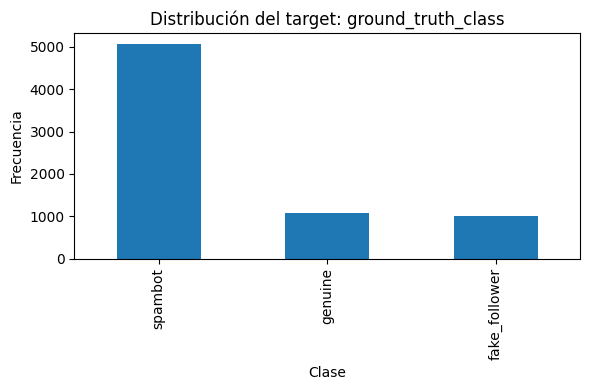

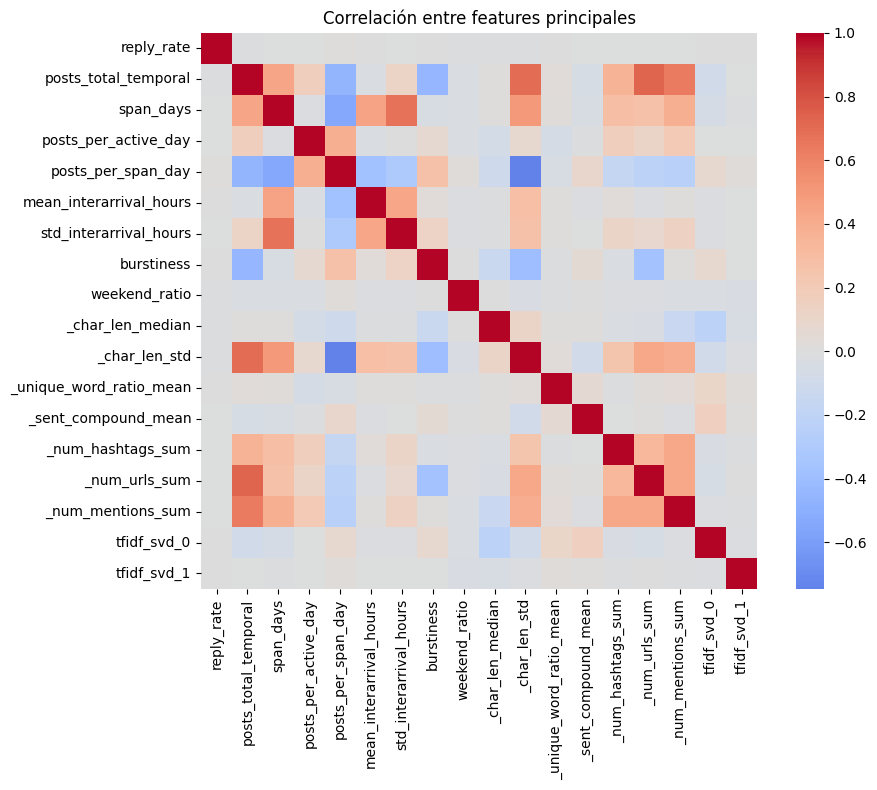

Features ensamblados: (7144, 20)
Número de features: 18
Target detectado: ground_truth_class
Fuente target: df_time
Columna ID usada para target: user_id
Match rate target: 1.0
Catálogo guardado en: feature_catalog.json


In [39]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import logging

# 12. Ingeniería de características y selección de variables
# Objetivo: Unificar features, reducir ruido y preparar el set final
# Entradas: feat_behavioral, feat_temporal, feat_linguistic
# Salidas: df_features, feature_list
# Artefactos: df_features.parquet, feature_catalog.json


def _normalize_user_id(series):
    s = series.astype(str).str.strip()
    s = s.replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    s = s.str.replace(r'\.0$', '', regex=True)
    return s


def _mode_or_nan(series):
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.value_counts().idxmax()


def _detect_target_col(df_src, target_candidates):
    for c in target_candidates:
        if c in df_src.columns:
            return c
    # fallback heurístico
    for c in df_src.columns:
        lc = c.lower()
        if ('ground' in lc and 'class' in lc) or lc in ['class', 'label'] or 'ground_truth' in lc:
            return c
    return None


def _select_user_id_col(df_src, user_id_candidates):
    for c in user_id_candidates:
        if c in df_src.columns:
            return c
    # fallback heurístico
    for c in df_src.columns:
        lc = c.lower()
        if 'user' in lc and 'id' in lc:
            return c
    return None


def _build_target_map(df_src, user_id_candidates, target_col, canonical_user_id_col):
    user_id_col_src = _select_user_id_col(df_src, user_id_candidates)
    if user_id_col_src is None:
        return None, None

    tmp = df_src[[user_id_col_src, target_col]].copy()
    tmp = tmp.rename(columns={user_id_col_src: canonical_user_id_col})
    tmp[canonical_user_id_col] = _normalize_user_id(tmp[canonical_user_id_col])
    tmp[target_col] = tmp[target_col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    tmp = tmp.dropna(subset=[canonical_user_id_col, target_col])
    if tmp.empty:
        return None, user_id_col_src

    target_map = tmp.groupby(canonical_user_id_col)[target_col].agg(_mode_or_nan).reset_index()
    return target_map, user_id_col_src


def _estimate_match_rate(df_base, target_map, user_id_col, target_col):
    if target_map is None or target_map.empty:
        return 0.0
    tmp = df_base[[user_id_col]].merge(target_map, on=user_id_col, how='left')
    return float(tmp[target_col].notna().mean())


# --- Helper para ensamblar y seleccionar features

def assemble_features(feat_behavioral, feat_temporal, feat_linguistic,
                      user_id_col='user_id', target_col=None,
                      df_time=None, df_raw=None,
                      target_candidates=None,
                      corr_threshold=0.95, min_variance=0.01):
    """
    Ensambla features de múltiples fuentes y aplica filtros de calidad.
    """
    if target_candidates is None:
        target_candidates = ['ground_truth_class', 'label', 'class', 'is_bot', 'bot']

    user_id_candidates = [
        user_id_col, 'user_id', 'user id', 'user_id_str', 'userid', 'userid_str',
        'user', 'id', 'id_str', 'author_id'
    ]

    # 1. Normalizar IDs en features
    for df_src in [feat_behavioral, feat_temporal, feat_linguistic]:
        if df_src is not None and user_id_col in df_src.columns:
            df_src[user_id_col] = _normalize_user_id(df_src[user_id_col])

    # 2. Merge de features por user_id
    df_merged = feat_behavioral.copy()

    if feat_temporal is not None and not feat_temporal.empty:
        df_merged = df_merged.merge(feat_temporal, on=user_id_col, how='left')

    if feat_linguistic is not None and not feat_linguistic.empty:
        df_merged = df_merged.merge(feat_linguistic, on=user_id_col, how='left')

    df_merged = df_merged.fillna(0)

    # 3. Detectar y asociar target (prioridad: mayor cobertura)
    target_col_used = target_col
    if target_col_used is None:
        if df_time is not None:
            target_col_used = _detect_target_col(df_time, target_candidates)
        if target_col_used is None and df_raw is not None:
            target_col_used = _detect_target_col(df_raw, target_candidates)

    target_match_rate = None
    target_source = None
    target_user_id_col = None

    if target_col_used is not None:
        candidates = []

        if df_time is not None and target_col_used in df_time.columns:
            target_map, target_user_id_col_time = _build_target_map(
                df_time, user_id_candidates, target_col_used, user_id_col
            )
            match_rate = _estimate_match_rate(df_merged, target_map, user_id_col, target_col_used)
            candidates.append((match_rate, target_map, 'df_time', target_user_id_col_time))

        if df_raw is not None and target_col_used in df_raw.columns:
            target_map, target_user_id_col_raw = _build_target_map(
                df_raw, user_id_candidates, target_col_used, user_id_col
            )
            match_rate = _estimate_match_rate(df_merged, target_map, user_id_col, target_col_used)
            candidates.append((match_rate, target_map, 'df_raw', target_user_id_col_raw))

        # Elegir el candidato con mejor cobertura
        if candidates:
            candidates.sort(key=lambda x: x[0], reverse=True)
            best_rate, best_map, best_source, best_id_col = candidates[0]
            if best_map is not None:
                df_merged = df_merged.merge(best_map, on=user_id_col, how='left')
                target_match_rate = float(best_rate)
                target_source = best_source
                target_user_id_col = best_id_col
                if target_match_rate < 0.8:
                    logging.warning(f'Baja asociación de target: match_rate={target_match_rate:.3f}')

    # 4. Identificar columnas de features (excluir user_id y target)
    exclude_cols = {user_id_col}
    if target_col_used and target_col_used in df_merged.columns:
        exclude_cols.add(target_col_used)

    feature_cols = [c for c in df_merged.columns if c not in exclude_cols]

    # 5. Filtro de varianza: remover features con varianza muy baja
    df_features_only = df_merged[feature_cols]
    variances = df_features_only.var(numeric_only=True)
    low_var_cols = variances[variances < min_variance].index.tolist()
    feature_cols = [c for c in feature_cols if c not in low_var_cols]

    logging.info(f"Removidas {len(low_var_cols)} features con baja varianza: {low_var_cols}")

    # 6. Detección de multicolinealidad: remover una de cada par altamente correlacionado
    df_features_only = df_merged[feature_cols].select_dtypes(include=[np.number])
    corr_matrix = df_features_only.corr().abs()

    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    high_corr_pairs = []
    cols_to_remove_multicolinearity = set()

    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > corr_threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                high_corr_pairs.append((col_i, col_j, corr_matrix.iloc[i, j]))
                # Remover la de menor varianza
                if variances[col_i] > variances[col_j]:
                    cols_to_remove_multicolinearity.add(col_j)
                else:
                    cols_to_remove_multicolinearity.add(col_i)

    feature_cols = [c for c in feature_cols if c not in cols_to_remove_multicolinearity]
    logging.info(f"Removidas {len(cols_to_remove_multicolinearity)} features por multicolinealidad")

    # 7. Construir DataFrame final con features seleccionadas
    df_features = df_merged[[user_id_col] + feature_cols].copy()
    if target_col_used and target_col_used in df_merged.columns:
        df_features[target_col_used] = df_merged[target_col_used]

    # 8. Crear catálogo de features
    feature_catalog = {
        'n_features_total': len(feature_cols),
        'n_rows': len(df_features),
        'features': feature_cols,
        'low_variance_removed': low_var_cols,
        'multicollinearity_removed': list(cols_to_remove_multicolinearity),
        'high_corr_pairs': [(c1, c2, float(c3)) for c1, c2, c3 in high_corr_pairs],
        'target_col': target_col_used,
        'target_match_rate': target_match_rate,
        'target_source': target_source,
        'target_user_id_col': target_user_id_col,
        'thresholds': {
            'corr_threshold': corr_threshold,
            'min_variance': min_variance
        }
    }

    return df_features, feature_cols, feature_catalog


# --- Aplicar ensamblaje de features
_df_time = df_time if 'df_time' in globals() else None
_df_raw = df_raw if 'df_raw' in globals() else None

# `target_col` se detecta automáticamente; usa `ground_truth_class` si existe

df_features, feature_list, feature_catalog = assemble_features(
    feat_behavioral, feat_temporal, feat_linguistic,
    user_id_col='user_id',
    df_time=_df_time,
    df_raw=_df_raw,
    corr_threshold=0.95,
    min_variance=0.01
)

# --- Guardar artefactos
Path('output').mkdir(parents=True, exist_ok=True)
df_features.to_parquet('output/df_features.parquet', index=False)

with open('feature_catalog.json', 'w', encoding='utf-8') as f:
    json.dump(convert_types_for_json(feature_catalog), f, indent=2, ensure_ascii=False)

# --- Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Distribución de clases (si existe target)
target_col = feature_catalog.get('target_col')
if target_col and target_col in df_features.columns:
    plt.figure(figsize=(6, 4))
    df_features[target_col].value_counts().plot(kind='bar')
    plt.title(f'Distribución del target: {target_col}')
    plt.xlabel('Clase')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

# Correlación de features principales
plt.figure(figsize=(10, 8))
top_features = feature_list[:20]
corr_subset = df_features[top_features].select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_subset, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlación entre features principales')
plt.tight_layout()
plt.show()

print(f"Features ensamblados: {df_features.shape}")
print(f"Número de features: {len(feature_list)}")
print(f"Target detectado: {feature_catalog.get('target_col')}")
print(f"Fuente target: {feature_catalog.get('target_source')}")
print(f"Columna ID usada para target: {feature_catalog.get('target_user_id_col')}")
print(f"Match rate target: {feature_catalog.get('target_match_rate')}")
print(f"Catálogo guardado en: feature_catalog.json")

## 13. EDA avanzado y analisis comparativo bot vs humano
- Nombre exacto de la seccion: EDA avanzado y analisis comparativo bot vs humano
- Objetivo tecnico: Explorar relaciones, patrones y diferencias entre clases
- Subsecciones / bloques: EDA univariado; EDA bivariado; EDA multivariado; Correlaciones; Distribuciones; Deteccion de patrones; Analisis temporal; Analisis de actividad; Analisis de interaccion; Analisis de comportamiento automatizado; Comparacion bot vs humano
- Tipo de codigo: Visualizacion, estadistica descriptiva, segmentacion
- Datos entran: `df_features`
- Datos salen: `eda_report`, `insights_table`
- Visualizaciones: Histogramas, boxplots, heatmaps, pairplots
- Metricas: Correlaciones, diferencias de medias, effect size
- Validaciones: Tamaño minimo por segmento, outliers extremos
- Transformaciones: Escalado solo para graficos, bins
- Errores a controlar: Interpretaciones con sesgo, data leakage
- Resultados a guardar: `eda_report.md`
- Artefactos a exportar: `figures/`
- Variables sugeridas: `eda_report`, `segment_col`
- Checkpoint / cache: Guardar tablas agregadas para dashboards
- Notas de modularizacion: Helpers `plot_*` y `eda_*`
- Reproducibilidad: Fijar parametros de bins y filtros
- Placeholder: agregar codigo en la celda inferior para EDA

In [40]:
from pathlib import Path
import json as _json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# EDA avanzado: comparativo bot vs humano (guarda reportes y figuras)

def _normalize_user_id(series):
    s = series.astype(str).str.strip()
    s = s.replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    s = s.str.replace(r'\.0$', '', regex=True)
    return s


def _mode_or_nan(series):
    s = series.dropna()
    if s.empty:
        return np.nan
    return s.value_counts().idxmax()


def _detect_target_col(df_src, target_candidates):
    for c in target_candidates:
        if c in df_src.columns:
            return c
    return None


def _select_user_id_col(df_src, user_id_candidates):
    for c in user_id_candidates:
        if c in df_src.columns:
            return c
    return None


def _build_target_map(df_src, user_id_candidates, target_col, canonical_user_id_col):
    user_id_col_src = _select_user_id_col(df_src, user_id_candidates)
    if user_id_col_src is None:
        return None, None

    tmp = df_src[[user_id_col_src, target_col]].copy()
    tmp = tmp.rename(columns={user_id_col_src: canonical_user_id_col})
    tmp[canonical_user_id_col] = _normalize_user_id(tmp[canonical_user_id_col])
    tmp[target_col] = tmp[target_col].replace({'nan': np.nan, 'none': np.nan, '': np.nan})
    tmp = tmp.dropna(subset=[canonical_user_id_col, target_col])
    if tmp.empty:
        return None, user_id_col_src

    target_map = tmp.groupby(canonical_user_id_col)[target_col].agg(_mode_or_nan).reset_index()
    return target_map, user_id_col_src


def run_advanced_eda(df_features, df_raw=None, df_time=None, feature_list=None,
                     user_id_col='user_id', target_col=None,
                     target_candidates=None,
                     out_dir=Path('output/figures'),
                     top_k_features=12, run_id=RUN_ID):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if target_candidates is None:
        target_candidates = ['ground_truth_class', 'label', 'class', 'is_bot', 'bot']

    user_id_candidates = [user_id_col, 'user_id', 'user_id_str', 'userid', 'user', 'id', 'id_str', 'author_id']

    # 1) encontrar columna target en df_features
    target_col_used = target_col
    if target_col_used is None:
        target_col_used = _detect_target_col(df_features, target_candidates)

    # 2) preparar dataframe para EDA
    df_eda = df_features.copy()
    df_eda[user_id_col] = _normalize_user_id(df_eda[user_id_col])

    # 3) si no hay target en df_features, intentar unir desde df_time o df_raw
    if target_col_used is None:
        if df_time is not None:
            target_col_used = _detect_target_col(df_time, target_candidates)
            if target_col_used and target_col_used in df_time.columns:
                target_map, _ = _build_target_map(df_time, user_id_candidates, target_col_used, user_id_col)
                if target_map is not None:
                    df_eda = df_eda.merge(target_map, on=user_id_col, how='left')
        if target_col_used is None and df_raw is not None:
            target_col_used = _detect_target_col(df_raw, target_candidates)
            if target_col_used and target_col_used in df_raw.columns:
                target_map, _ = _build_target_map(df_raw, user_id_candidates, target_col_used, user_id_col)
                if target_map is not None:
                    df_eda = df_eda.merge(target_map, on=user_id_col, how='left')

    # 4) pick features
    if feature_list is None:
        feature_cols = [c for c in df_eda.columns if c != user_id_col]
    else:
        feature_cols = [c for c in feature_list if c in df_eda.columns]
    feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_eda[c])]
    if len(feature_cols) == 0:
        print("No hay features numéricas para analizar.")
        return

    # 5) stats por grupo (o global si no hay target)
    insights = []
    if target_col_used and target_col_used in df_eda.columns:
        match_rate = float(df_eda[target_col_used].notna().mean())
        if match_rate < 0.8:
            print(f"AVISO: baja asociación de target (match_rate={match_rate:.3f}).")
        df_eda[target_col_used] = df_eda[target_col_used].fillna('missing')
        groups = df_eda[target_col_used].unique().tolist()
        for f in feature_cols:
            row = {'feature': f}
            for g in groups:
                s = df_eda.loc[df_eda[target_col_used] == g, f].dropna()
                row[f'n_{g}'] = int(s.shape[0])
                row[f'mean_{g}'] = float(s.mean()) if s.size else 0.0
                row[f'med_{g}'] = float(s.median()) if s.size else 0.0
                row[f'std_{g}'] = float(s.std()) if s.size else 0.0
            # effect size (Cohen's d) para caso binario
            if len(groups) == 2:
                a = df_eda.loc[df_eda[target_col_used] == groups[0], f].dropna()
                b = df_eda.loc[df_eda[target_col_used] == groups[1], f].dropna()
                if a.size and b.size:
                    na, nb = a.size, b.size
                    s_pooled = np.sqrt(((na-1)*a.var() + (nb-1)*b.var()) / max(1, (na+nb-2)))
                    cohen_d = (a.mean() - b.mean()) / s_pooled if s_pooled > 0 else 0.0
                else:
                    cohen_d = 0.0
                row['cohen_d'] = float(cohen_d)
            else:
                row['cohen_d'] = 0.0
            insights.append(row)
    else:
        # global summary
        for f in feature_cols:
            s = df_eda[f].dropna()
            insights.append({
                'feature': f,
                'n_total': int(s.size),
                'mean': float(s.mean()) if s.size else 0.0,
                'median': float(s.median()) if s.size else 0.0,
                'std': float(s.std()) if s.size else 0.0,
                'cohen_d': 0.0
            })

    insights_df = pd.DataFrame(insights).sort_values('cohen_d', key=lambda x: x.abs(), ascending=False).reset_index(drop=True)

    # 6) guardar insights
    insights_path = Path('output') / f'eda_insights_{run_id}.csv'
    insights_df.to_csv(insights_path, index=False)

    # 7) generar report markdown con top features
    report_lines = []
    report_lines.append(f"# EDA avanzado - comparativo (run_id: {run_id})\n")
    report_lines.append(f"Fecha: {datetime.datetime.now().isoformat()}\n")
    if target_col_used and target_col_used in df_eda.columns:
        report_lines.append(f"Target usado: {target_col_used}\n")
        report_lines.append(f"Clases: {df_eda[target_col_used].fillna('missing').unique().tolist()}\n")
    else:
        report_lines.append("No se encontró target; se muestran estadísticos globales.\n")
    report_lines.append("\n## Top features por efecto (|Cohen d|)\n")
    topk = insights_df.head(top_k_features)
    for _, r in topk.iterrows():
        report_lines.append(f"- {r['feature']}: cohen_d={r.get('cohen_d', 0):.3f}\n")
    report_lines.append("\n## Insights table\n")
    report_lines.append(f"Insights guardados en: {insights_path}\n")
    report_path = Path('output') / f'eda_report_{run_id}.md'
    report_path.write_text("".join(report_lines), encoding='utf-8')

    # 8) graficar top features (boxplots por clase si hay target, otherwise hist)
    png_paths = []
    for f in topk['feature'].tolist():
        fig, ax = plt.subplots(figsize=(6,3))
        if target_col_used and target_col_used in df_eda.columns:
            sns.boxplot(x=target_col_used, y=f, data=df_eda.sample(frac=1.0, replace=False), ax=ax)
            ax.set_title(f'Boxplot {f} by {target_col_used}')
        else:
            sns.histplot(df_eda[f].dropna(), bins=50, kde=True, ax=ax)
            ax.set_title(f'Distribución {f}')
        p = out_dir / f"{run_id}__{f}.png"
        fig.tight_layout()
        fig.savefig(p, dpi=150)
        plt.close(fig)
        png_paths.append(str(p))

    # 9) resumen final
    summary = {
        'run_id': run_id,
        'n_rows_features': int(df_features.shape[0]),
        'n_features_analyzed': len(feature_cols),
        'target_col': target_col_used,
        'insights_path': str(insights_path),
        'report_path': str(report_path),
        'figures': png_paths
    }

    # save summary json
    Path('output').mkdir(parents=True, exist_ok=True)
    with open(Path('output') / f'eda_summary_{run_id}.json', 'w', encoding='utf-8') as _f:
        _json.dump(convert_types_for_json(summary), _f, indent=2)

    print(f"EDA avanzado completado. Report: {report_path}, Insights: {insights_path}, Figures: {len(png_paths)}")

    # Expose outputs and show insights table in the notebook
    eda_report = str(report_path)
    insights_table = insights_df
    display(insights_table)
    return summary, insights_table


# Ejecutar en el notebook con variables existentes
run_advanced_eda(
    df_features,
    df_raw=df_raw if 'df_raw' in globals() else None,
    df_time=df_time if 'df_time' in globals() else None,
    feature_list=feature_list,
    user_id_col='user_id',
    out_dir=Path(ARTIFACTS_DIR) / 'figures',
    top_k_features=12,
    run_id=RUN_ID
)

EDA avanzado completado. Report: output\eda_report_20260522_143308.md, Insights: output\eda_insights_20260522_143308.csv, Figures: 12


,feature,n_fake_follower,mean_fake_follower,med_fake_follower,std_fake_follower,n_genuine,mean_genuine,med_genuine,std_genuine,n_spambot,mean_spambot,med_spambot,std_spambot,cohen_d
0,reply_rate,999,0.283824,0.000000,4.382583,1069,0.000000,0.000000,0.000000,5076,0.000000,0.000000,0.000000,0.0
1,posts_total_temporal,999,1.961962,1.000000,3.904490,1069,26.560337,31.000000,10.094097,5076,7.096139,1.000000,10.290051,0.0
2,span_days,999,47.025031,1.000000,158.674954,1069,485.158583,341.814965,488.615590,5076,68.474080,1.000000,123.539976,0.0
3,posts_per_active_day,999,1.027149,1.000000,0.246529,1069,1.111266,1.000000,0.492951,5076,1.007737,1.000000,0.082993,0.0
4,posts_per_span_day,999,0.884612,1.000000,0.353880,1069,0.258430,0.079874,0.656417,5076,0.666826,1.000000,0.431972,0.0
5,mean_interarrival_hours,999,404.401327,0.000000,1916.322924,1069,932.660756,311.566333,2332.674282,5076,318.520608,0.000000,852.731146,0.0
6,std_interarrival_hours,999,129.970847,0.000000,603.854410,1069,749.724455,240.074556,1572.005697,5076,87.563219,0.000000,364.080540,0.0
7,burstiness,999,-0.008302,0.000000,0.096713,1069,-0.065409,-0.062668,0.218197,5076,-0.074193,0.000000,0.154207,0.0
8,weekend_ratio,999,0.288913,0.000000,0.430801,1069,0.257516,0.250000,0.128374,5076,0.287806,0.153846,0.368614,0.0
9,_char_len_median,999,48.654655,42.000000,37.633887,1069,45.454630,42.000000,20.835398,5076,62.029748,66.000000,32.915356,0.0


({'run_id': '20260522_143308',
  'n_rows_features': 7144,
  'n_features_analyzed': 18,
  'target_col': 'ground_truth_class',
  'insights_path': 'output\\eda_insights_20260522_143308.csv',
  'report_path': 'output\\eda_report_20260522_143308.md',
  'figures': ['output\\artifacts\\figures\\20260522_143308__reply_rate.png',
   'output\\artifacts\\figures\\20260522_143308__posts_total_temporal.png',
   'output\\artifacts\\figures\\20260522_143308__span_days.png',
   'output\\artifacts\\figures\\20260522_143308__posts_per_active_day.png',
   'output\\artifacts\\figures\\20260522_143308__posts_per_span_day.png',
   'output\\artifacts\\figures\\20260522_143308__mean_interarrival_hours.png',
   'output\\artifacts\\figures\\20260522_143308__std_interarrival_hours.png',
   'output\\artifacts\\figures\\20260522_143308__burstiness.png',
   'output\\artifacts\\figures\\20260522_143308__weekend_ratio.png',
   'output\\artifacts\\figures\\20260522_143308___char_len_median.png',
   'output\\artifacts\

## 14. Pipeline de preprocessing y construccion de datasets de entrenamiento
- Nombre exacto de la seccion: Pipeline de preprocessing y construccion de datasets de entrenamiento
- Objetivo tecnico: Construir pipeline reproducible para train/val/test
- Subsecciones / bloques: Construccion de datasets; Division train/validation/test; Escalado; Encoding; Pipeline de preprocessing
- Tipo de codigo: Splitters, transformers, pipelines
- Datos entran: `df_features`, `target_col`
- Datos salen: `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `preprocess_pipeline`
- Visualizaciones: Distribucion de clases por split
- Metricas: Tamaños de splits, balance por clase
- Validaciones: Estratificacion, leakage entre splits
- Transformaciones: Scaling, encoding, imputacion final
- Errores a controlar: Desalineacion de features, leakage
- Resultados a guardar: `splits_metadata.json`
- Artefactos a exportar: `preprocess_pipeline.pkl`
- Variables sugeridas: `X_train`, `y_train`, `preprocess_pipeline`
- Checkpoint / cache: Guardar splits y pipeline
- Notas de modularizacion: Funcion `build_preprocess_pipeline()`
- Reproducibilidad: Fijar random_state en splitters
- Placeholder: agregar codigo en la celda inferior para preprocessing

In [41]:
import json
import pickle
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

# 14. Pipeline de preprocessing y construcción de datasets de entrenamiento


# --- Detectar target
target_col = None
if 'feature_catalog' in globals() and isinstance(feature_catalog, dict):
    target_col = feature_catalog.get('target_col')

if target_col is None:
    candidates = ['ground_truth_class', 'label', 'class', 'is_bot', 'bot']
    target_col = next((c for c in candidates if c in df_features.columns), None)

if target_col is None:
    raise ValueError('No se encontró una columna target en df_features ni en feature_catalog.')

# --- Preparar datos
df_model = df_features.copy()
df_model = df_model.dropna(subset=[target_col]).reset_index(drop=True)

exclude_cols = [c for c in ['user_id', target_col] if c in df_model.columns]
X = df_model.drop(columns=exclude_cols)
y = df_model[target_col].astype(str)

# --- Codificar target si es categórico
le = LabelEncoder()
y_enc = le.fit_transform(y)

# --- Split train / val / test con estratificación
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.30, random_state=RANDOM_STATE, stratify=y_enc
)

# Si hay pocas muestras por clase, evitar estratificar en el segundo split
can_stratify_temp = len(pd.Series(y_temp).value_counts()) > 1 and pd.Series(y_temp).value_counts().min() >= 2
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE,
    stratify=y_temp if can_stratify_temp else None
)

# --- Pipeline de preprocessing
numeric_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# Fit solo con train para evitar leakage
X_train_prep = preprocess_pipeline.fit_transform(X_train)
X_val_prep = preprocess_pipeline.transform(X_val)
X_test_prep = preprocess_pipeline.transform(X_test)

# --- Metadata de splits
splits_metadata = {
    'target_col': target_col,
    'label_classes': le.classes_.tolist(),
    'n_rows_total': int(len(df_model)),
    'n_train': int(len(X_train)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test)),
    'train_class_balance': pd.Series(y_train).value_counts(normalize=True).sort_index().to_dict(),
    'val_class_balance': pd.Series(y_val).value_counts(normalize=True).sort_index().to_dict(),
    'test_class_balance': pd.Series(y_test).value_counts(normalize=True).sort_index().to_dict(),
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'random_state': RANDOM_STATE
}

# --- Guardar artefactos
Path('output').mkdir(parents=True, exist_ok=True)
Path('output/artifacts').mkdir(parents=True, exist_ok=True)

with open('splits_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(splits_metadata, f, indent=2, ensure_ascii=False)

with open('output/artifacts/preprocess_pipeline.pkl', 'wb') as f:
    pickle.dump(preprocess_pipeline, f)

print('Preprocesamiento listo.')
print(f"Target: {target_col}")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"X_train_prep: {X_train_prep.shape}, X_val_prep: {X_val_prep.shape}, X_test_prep: {X_test_prep.shape}")

Preprocesamiento listo.
Target: ground_truth_class
X_train: (5000, 18), X_val: (1072, 18), X_test: (1072, 18)
X_train_prep: (5000, 18), X_val_prep: (1072, 18), X_test_prep: (1072, 18)


## 15. Entrenamiento baseline y modelos supervisados
- Nombre exacto de la seccion: Entrenamiento baseline y modelos supervisados
- Objetivo tecnico: Establecer baseline y entrenar modelos supervisados
- Subsecciones / bloques: Entrenamiento baseline; Entrenamiento de modelos supervisados
- Tipo de codigo: Fit/predict, pipelines, evaluacion inicial
- Datos entran: `X_train`, `y_train`, `X_val`, `y_val`
- Datos salen: `model_baseline`, `model_supervised`
- Visualizaciones: Curvas de aprendizaje, metricas iniciales
- Metricas: Accuracy, precision, recall, F1 preliminar
- Validaciones: Consistencia de features, overfitting rapido
- Transformaciones: Ajuste de hiperparametros simples
- Errores a controlar: Clase minoritaria ignorada
- Resultados a guardar: `baseline_metrics.json`
- Artefactos a exportar: `model_baseline.pkl`
- Variables sugeridas: `model_baseline`, `model_supervised`
- Checkpoint / cache: Persistir baseline y logs de entrenamiento
- Notas de modularizacion: Funcion `train_baseline()`
- Reproducibilidad: Fijar random_state en modelos
- Placeholder: agregar codigo en la celda inferior para entrenamiento

In [42]:
import pickle
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import json

# 15. Entrenamiento baseline y modelos supervisados

ARTIFACTS = Path('output/artifacts')
ARTIFACTS.mkdir(parents=True, exist_ok=True)

def _eval(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'classification_report': classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    }

results = {}

# Baseline: Dummy (stratified)
baseline = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
baseline.fit(X_train_prep, y_train)
y_val_base = baseline.predict(X_val_prep)
y_test_base = baseline.predict(X_test_prep)
results['baseline_dummy'] = {
    'val': _eval(y_val, y_val_base),
    'test': _eval(y_test, y_test_base)
}
with open(ARTIFACTS / 'model_baseline_dummy.pkl', 'wb') as f:
    pickle.dump(baseline, f)

# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_prep, y_train)
y_val_lr = lr.predict(X_val_prep)
y_test_lr = lr.predict(X_test_prep)
results['logistic_regression'] = {
    'val': _eval(y_val, y_val_lr),
    'test': _eval(y_test, y_test_lr)
}
with open(ARTIFACTS / 'model_logistic_regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_prep, y_train)
y_val_rf = rf.predict(X_val_prep)
y_test_rf = rf.predict(X_test_prep)
results['random_forest'] = {
    'val': _eval(y_val, y_val_rf),
    'test': _eval(y_test, y_test_rf)
}
with open(ARTIFACTS / 'model_random_forest.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Guardar métricas
with open(ARTIFACTS / 'baseline_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2)

print("Entrenamiento completado. Modelos guardados en:", ARTIFACTS)

Entrenamiento completado. Modelos guardados en: output\artifacts


## 16. Modelos supervisados avanzados y feature importance
- Nombre exacto de la seccion: Modelos supervisados avanzados y feature importance
- Objetivo tecnico: Optimizar modelos y estimar importancia de variables
- Subsecciones / bloques: Entrenamiento avanzado; Validacion cruzada; Feature importance
- Tipo de codigo: CV, hiperparametros, interpretacion basica
- Datos entran: `X_train`, `y_train`, `X_val`, `y_val`
- Datos salen: `model_best`, `feature_importance`
- Visualizaciones: Importancia de features, curvas ROC/PR
- Metricas: ROC-AUC, F1, precision/recall
- Validaciones: Overfitting, estabilidad en CV
- Transformaciones: Seleccion final de hiperparametros
- Errores a controlar: Leakage en CV, sobreajuste
- Resultados a guardar: `model_comparison.csv`
- Artefactos a exportar: `model_best.pkl`, `feature_importance.csv`
- Variables sugeridas: `model_best`, `feature_importance`
- Checkpoint / cache: Guardar modelo final y config de CV
- Notas de modularizacion: Funcion `train_supervised_models()`
- Reproducibilidad: Fijar seeds en CV y modelos
- Placeholder: agregar codigo en la celda inferior para modelos avanzados

In [43]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 16. Modelos supervisados avanzados y feature importance

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def _evaluate_multiclass(model, Xp, y_true, use_proba=True):
    y_pred = model.predict(Xp)
    out = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision_macro': float(precision_score(y_true, y_pred, average='macro', zero_division=0)),
        'recall_macro': float(recall_score(y_true, y_pred, average='macro', zero_division=0)),
        'f1_macro': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
    }

    try:
        if use_proba and hasattr(model, "predict_proba"):
            y_score = model.predict_proba(Xp)
            out['roc_auc_ovr_macro'] = float(
                roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
            )
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(Xp)
            out['roc_auc_ovr_macro'] = float(
                roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
            )
        else:
            out['roc_auc_ovr_macro'] = np.nan
    except Exception:
        out['roc_auc_ovr_macro'] = np.nan

    return out, y_pred


def _get_feature_names(pipeline, fallback_cols):
    try:
        return pipeline.get_feature_names_out().tolist()
    except Exception:
        return list(fallback_cols)


candidates = {
    'logistic_regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced'),
    'random_forest': RandomForestClassifier(
        n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced_subsample'
    ),
    'svc_rbf': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE, class_weight='balanced')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_rows = []
trained_models = {}
pred_store = {}

for name, model in candidates.items():
    cv_scores = cross_val_score(model, X_train_prep, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    model.fit(X_train_prep, y_train)

    val_metrics, y_val_pred = _evaluate_multiclass(model, X_val_prep, y_val, use_proba=True)
    test_metrics, y_test_pred = _evaluate_multiclass(model, X_test_prep, y_test, use_proba=True)

    trained_models[name] = model
    pred_store[name] = {
        'val_pred': y_val_pred,
        'test_pred': y_test_pred
    }

    row = {
        'model': name,
        'cv_f1_macro_mean': float(cv_scores.mean()),
        'cv_f1_macro_std': float(cv_scores.std()),
        'val_accuracy': val_metrics['accuracy'],
        'val_precision_macro': val_metrics['precision_macro'],
        'val_recall_macro': val_metrics['recall_macro'],
        'val_f1_macro': val_metrics['f1_macro'],
        'val_roc_auc_ovr_macro': val_metrics['roc_auc_ovr_macro'],
        'test_accuracy': test_metrics['accuracy'],
        'test_precision_macro': test_metrics['precision_macro'],
        'test_recall_macro': test_metrics['recall_macro'],
        'test_f1_macro': test_metrics['f1_macro'],
        'test_roc_auc_ovr_macro': test_metrics['roc_auc_ovr_macro'],
    }
    model_rows.append(row)

model_comparison = pd.DataFrame(model_rows).sort_values(
    ['val_f1_macro', 'cv_f1_macro_mean'], ascending=False
).reset_index(drop=True)
model_comparison.to_csv(ARTIFACTS_DIR / 'model_comparison.csv', index=False)

best_name = model_comparison.loc[0, 'model']
model_best = trained_models[best_name]

# Feature importance
feature_names = _get_feature_names(preprocess_pipeline, X_train.columns if hasattr(X_train, 'columns') else feature_list)

if hasattr(model_best, 'feature_importances_'):
    importances = pd.Series(model_best.feature_importances_, index=feature_names)
    feature_importance = (
        importances.abs()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={'index': 'feature', 0: 'importance'})
    )
    feature_importance['importance_type'] = 'native'
else:
    perm = permutation_importance(
        model_best, X_val_prep, y_val, n_repeats=10, random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1
    )
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': perm.importances_mean,
        'importance_std': perm.importances_std,
        'importance_type': 'permutation'
    }).sort_values('importance', ascending=False).reset_index(drop=True)

feature_importance.to_csv(ARTIFACTS_DIR / 'feature_importance.csv', index=False)

# Save best model bundle
model_bundle = {
    'model_name': best_name,
    'model': model_best,
    'preprocess_pipeline': preprocess_pipeline,
    'label_encoder': le,
    'target_col': target_col,
    'feature_names': feature_names,
    'run_id': RUN_ID
}
with open(ARTIFACTS_DIR / 'model_best.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Modelos evaluados:")
display(model_comparison)
print(f"Modelo seleccionado: {best_name}")
display(feature_importance.head(20))

Modelos evaluados:


,model,cv_f1_macro_mean,cv_f1_macro_std,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc_ovr_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc_ovr_macro
0,random_forest,0.793450,0.014883,0.858209,0.789163,0.763281,0.769774,0.943711,0.886194,0.849436,0.796119,0.814794,0.943301
1,svc_rbf,0.665490,0.009164,0.651119,0.685787,0.771609,0.665819,0.903006,0.652985,0.683281,0.764815,0.667580,0.890802
2,logistic_regression,0.646852,0.010311,0.601679,0.675954,0.735931,0.637150,0.867042,0.596082,0.673464,0.734983,0.634165,0.864640


Modelo seleccionado: random_forest


,feature,importance,importance_type
0,num___num_mentions_sum,0.179210,native
1,num__tfidf_svd_0,0.094954,native
2,num___char_len_median,0.089946,native
3,num__tfidf_svd_1,0.085426,native
4,num__posts_total_temporal,0.082735,native
5,num___sent_compound_mean,0.059986,native
6,num__std_interarrival_hours,0.056008,native
7,num___char_len_std,0.055888,native
8,num___num_urls_sum,0.054971,native
9,num__span_days,0.048834,native


## 17. Modelos no supervisados: clustering y anomalias
- Nombre exacto de la seccion: Modelos no supervisados: clustering y anomalias
- Objetivo tecnico: Detectar grupos y comportamientos atipicos
- Subsecciones / bloques: Clustering; Deteccion de anomalias
- Tipo de codigo: KMeans/DBSCAN, IsolationForest, LOF
- Datos entran: `df_features` o `X_train` sin labels
- Datos salen: `cluster_labels`, `anomaly_scores`
- Visualizaciones: Proyecciones 2D/3D, distribucion de clusters
- Metricas: Silhouette, Davies-Bouldin, tasa de anomalias
- Validaciones: Estabilidad de clusters, sensibilidad a parametros
- Transformaciones: Escalado y reduccion dimensional
- Errores a controlar: Clusters degenerados, ruido excesivo
- Resultados a guardar: `clustering_report.json`
- Artefactos a exportar: `clustering_model.pkl`
- Variables sugeridas: `cluster_labels`, `anomaly_scores`
- Checkpoint / cache: Guardar labels y scores
- Notas de modularizacion: Funcion `run_unsupervised_models()`
- Reproducibilidad: Fijar seeds donde aplique
- Placeholder: agregar codigo en la celda inferior para clustering/anomalias

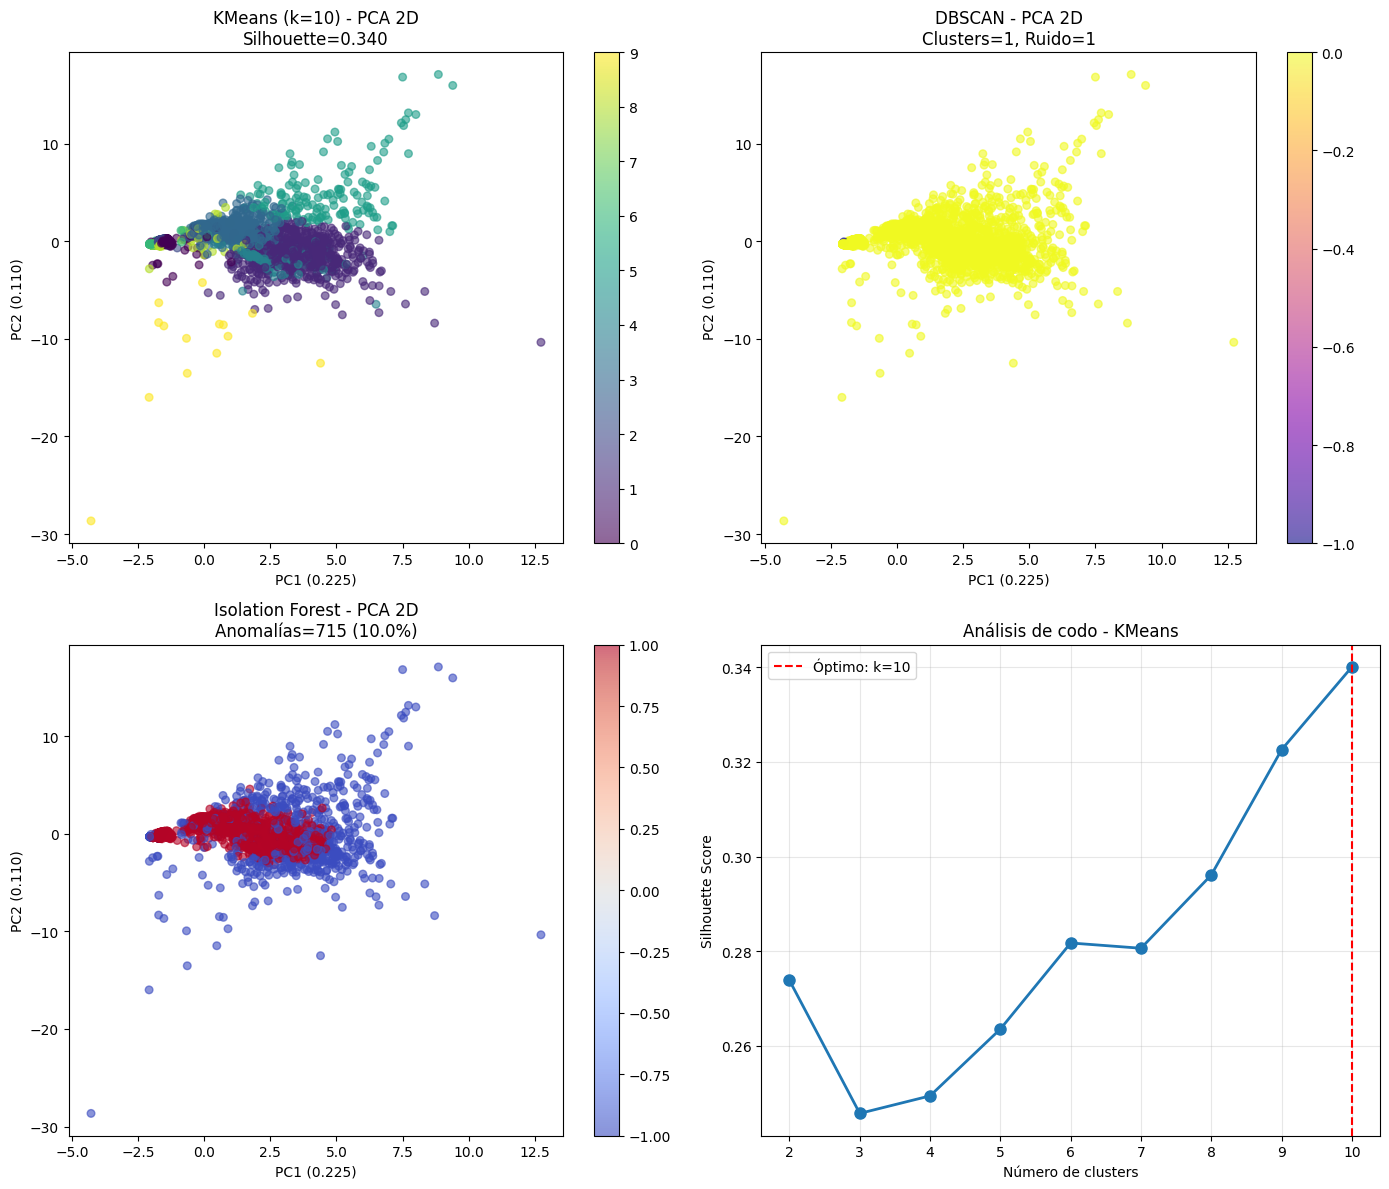


Distribución de KMeans clusters:


,cluster,n_samples,pct
0,0,2578,36.09
1,1,833,11.66
2,2,1087,15.22
3,3,1676,23.46
4,4,482,6.75
5,5,148,2.07
6,6,83,1.16
7,7,89,1.25
8,8,154,2.16
9,9,14,0.20



--- Reporte de Clustering ---
KMeans: Silhouette=0.340, Davies-Bouldin=1.025
DBSCAN: 1 clusters, 1 puntos de ruido
Isolation Forest: 715 anomalías detectadas (10.0%)
PCA 2D varianza explicada: 0.335
PCA 3D varianza explicada: 0.428


In [44]:
import numpy as np
import pandas as pd
import json
import pickle
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import seaborn as sns

# 17. Modelos no supervisados: clustering y detección de anomalías
# Objetivo: Detectar grupos y comportamientos atípicos
# Entradas: X_train_prep, X_test_prep (o df_features)
# Salidas: cluster_labels, anomaly_scores
# Artefactos: clustering_report.json, clustering_model.pkl

import matplotlib.pyplot as plt

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Preparar datos para clustering (usar train + val + test combinados para mayor robustez)
X_combined = np.vstack([X_train_prep, X_val_prep, X_test_prep])
y_combined = np.hstack([y_train, y_val, y_test])

# --- 1. KMeans clustering
n_clusters_range = range(2, 11)
kmeans_scores = []
best_k = 3
best_silhouette = -1

for k in n_clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_combined)
    sil_score = silhouette_score(X_combined, labels)
    kmeans_scores.append({'n_clusters': k, 'silhouette': float(sil_score)})
    if sil_score > best_silhouette:
        best_silhouette = sil_score
        best_k = k

# Entrenar KMeans con mejor k
kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_best.fit_predict(X_combined)
silhouette_global = silhouette_score(X_combined, cluster_labels)
davies_bouldin = davies_bouldin_score(X_combined, cluster_labels)

# --- 2. DBSCAN clustering
dbscan = DBSCAN(eps=50, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_combined)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

# --- 3. Isolation Forest para detección de anomalías
iso_forest = IsolationForest(contamination=0.1, random_state=RANDOM_STATE)
anomaly_scores = iso_forest.fit_predict(X_combined)  # -1 = anomalía, 1 = normal
anomaly_scores_proba = iso_forest.score_samples(X_combined)

n_anomalies = (anomaly_scores == -1).sum()
anomaly_rate = float(n_anomalies / len(anomaly_scores))

# --- 4. PCA para visualización 2D/3D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_combined)
pca_2d_var = float(pca_2d.explained_variance_ratio_.sum())

pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_3d = pca_3d.fit_transform(X_combined)
pca_3d_var = float(pca_3d.explained_variance_ratio_.sum())

# --- Reporte de clustering
clustering_report = {
    'kmeans': {
        'best_n_clusters': int(best_k),
        'silhouette_score': float(silhouette_global),
        'davies_bouldin_score': float(davies_bouldin),
        'elbow_analysis': kmeans_scores
    },
    'dbscan': {
        'n_clusters': int(n_clusters_dbscan),
        'n_noise_points': int(n_noise_dbscan),
        'noise_ratio': float(n_noise_dbscan / len(dbscan_labels))
    },
    'isolation_forest': {
        'n_anomalies': int(n_anomalies),
        'anomaly_rate': anomaly_rate,
        'contamination': 0.1
    },
    'pca_variance_2d': pca_2d_var,
    'pca_variance_3d': pca_3d_var,
    'n_total_samples': int(len(X_combined))
}

# --- Guardar reporte y modelos
with open(ARTIFACTS_DIR / 'clustering_report.json', 'w', encoding='utf-8') as f:
    json.dump(clustering_report, f, indent=2)

clustering_bundle = {
    'kmeans': kmeans_best,
    'dbscan': dbscan,
    'iso_forest': iso_forest,
    'pca_2d': pca_2d,
    'pca_3d': pca_3d,
    'random_state': RANDOM_STATE
}
with open(ARTIFACTS_DIR / 'clustering_model.pkl', 'wb') as f:
    pickle.dump(clustering_bundle, f)

# --- Visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# KMeans en 2D
scatter = axes[0, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6, s=30)
axes[0, 0].set_title(f'KMeans (k={best_k}) - PCA 2D\nSilhouette={silhouette_global:.3f}')
axes[0, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[0, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.colorbar(scatter, ax=axes[0, 0])

# DBSCAN en 2D
scatter = axes[0, 1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, cmap='plasma', alpha=0.6, s=30)
axes[0, 1].set_title(f'DBSCAN - PCA 2D\nClusters={n_clusters_dbscan}, Ruido={n_noise_dbscan}')
axes[0, 1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[0, 1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.colorbar(scatter, ax=axes[0, 1])

# Isolation Forest en 2D
scatter = axes[1, 0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=anomaly_scores, cmap='coolwarm', alpha=0.6, s=30)
axes[1, 0].set_title(f'Isolation Forest - PCA 2D\nAnomalías={n_anomalies} ({anomaly_rate*100:.1f}%)')
axes[1, 0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.3f})')
axes[1, 0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.colorbar(scatter, ax=axes[1, 0])

# Elbow curve para KMeans
kmeans_df = pd.DataFrame(kmeans_scores)
axes[1, 1].plot(kmeans_df['n_clusters'], kmeans_df['silhouette'], 'o-', linewidth=2, markersize=8)
axes[1, 1].axvline(best_k, color='r', linestyle='--', label=f'Óptimo: k={best_k}')
axes[1, 1].set_xlabel('Número de clusters')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].set_title('Análisis de codo - KMeans')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / 'clustering_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Tabla de distribución de clusters
cluster_dist = pd.Series(cluster_labels).value_counts().sort_index()
cluster_dist_df = pd.DataFrame({
    'cluster': cluster_dist.index,
    'n_samples': cluster_dist.values,
    'pct': (cluster_dist.values / len(cluster_labels) * 100).round(2)
})

print("\nDistribución de KMeans clusters:")
display(cluster_dist_df)

print("\n--- Reporte de Clustering ---")
print(f"KMeans: Silhouette={silhouette_global:.3f}, Davies-Bouldin={davies_bouldin:.3f}")
print(f"DBSCAN: {n_clusters_dbscan} clusters, {n_noise_dbscan} puntos de ruido")
print(f"Isolation Forest: {n_anomalies} anomalías detectadas ({anomaly_rate*100:.1f}%)")
print(f"PCA 2D varianza explicada: {pca_2d_var:.3f}")
print(f"PCA 3D varianza explicada: {pca_3d_var:.3f}")

## 18. Evaluacion de modelos y validacion cruzada
- Nombre exacto de la seccion: Evaluacion de modelos y validacion cruzada
- Objetivo tecnico: Medir rendimiento con metricas estandar
- Subsecciones / bloques: Accuracy; Precision; Recall; F1-score; ROC-AUC; Matriz de confusion; Validacion cruzada
- Tipo de codigo: Metricas, curvas, evaluadores
- Datos entran: `y_test`, `y_pred`, `y_proba`
- Datos salen: `metrics_table`, `confusion_matrix`
- Visualizaciones: ROC/PR curves, confusion matrix
- Metricas: Accuracy, precision, recall, F1, ROC-AUC
- Validaciones: Evaluar solo en holdout, calibracion
- Transformaciones: Thresholding y normalizacion de scores
- Errores a controlar: Evaluacion en train, leakage
- Resultados a guardar: `metrics.json`
- Artefactos a exportar: `confusion_matrix.png`
- Variables sugeridas: `metrics_table`, `y_pred`, `y_proba`
- Checkpoint / cache: Guardar metricas por modelo
- Notas de modularizacion: Funcion `evaluate_model()`
- Reproducibilidad: Fijar thresholds y seeds
- Placeholder: agregar codigo en la celda inferior para evaluacion

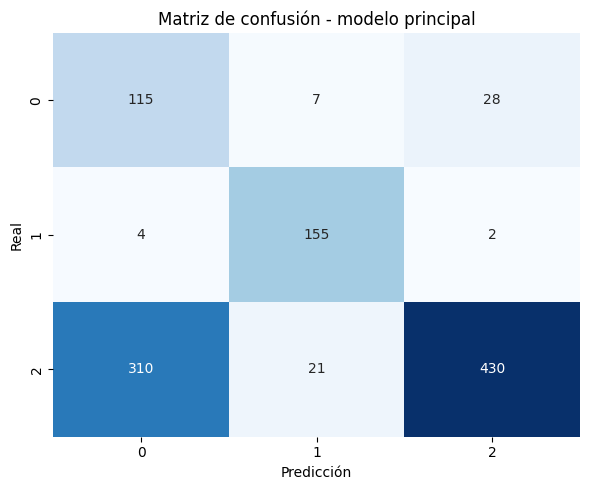

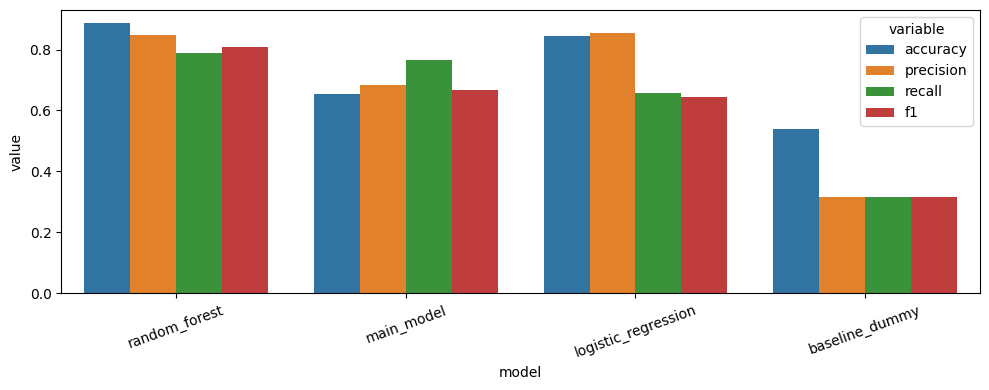

,model,accuracy,precision,recall,f1,roc_auc,cv_f1_macro_mean,cv_f1_macro_std
0,random_forest,0.885261,0.848812,0.788392,0.807874,NaN,0.793450,0.014883
1,main_model,0.652985,0.683281,0.764815,0.667580,0.943301,NaN,NaN
2,logistic_regression,0.845149,0.855352,0.656280,0.644938,NaN,0.646852,0.010311
3,baseline_dummy,0.539179,0.316228,0.315851,0.316014,NaN,NaN,NaN


Métricas guardadas en: output\metrics.json


In [45]:
import numpy as np
import pandas as pd
import json
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix as sk_confusion_matrix
)
import matplotlib.pyplot as plt

def evaluate_model(y_true, y_pred, y_proba=None, avg="macro"):
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, average=avg, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, average=avg, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, average=avg, zero_division=0)),
    }
    if y_proba is not None:
        try:
            if y_proba.ndim == 2 and y_proba.shape[1] > 2:
                out["roc_auc"] = float(roc_auc_score(y_true, y_proba, multi_class="ovr", average=avg))
            else:
                out["roc_auc"] = float(roc_auc_score(y_true, y_proba[:, 1] if y_proba.ndim == 2 else y_proba))
        except Exception:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan
    return out

# --- y_pred / y_proba para el modelo principal
if "y_test_pred" in globals():
    y_pred = y_test_pred
else:
    y_pred = y_test_rf if "y_test_rf" in globals() else y_test_lr

if "model_best" in globals() and "X_test_prep" in globals():
    try:
        y_proba = model_best.predict_proba(X_test_prep) if hasattr(model_best, "predict_proba") else None
        if y_proba is None and hasattr(model_best, "decision_function"):
            scores = model_best.decision_function(X_test_prep)
            y_proba = scores
    except Exception:
        y_proba = None
else:
    y_proba = None

# --- métricas por modelo
metrics_rows = []
model_map = {
    "baseline_dummy": ("y_test_base", "y_val_base"),
    "logistic_regression": ("y_test_lr", "y_val_lr"),
    "random_forest": ("y_test_rf", "y_val_rf"),
}

for model_name, (test_var, val_var) in model_map.items():
    if test_var in globals():
        row = {"model": model_name}
        row.update(evaluate_model(y_test, globals()[test_var]))
        if "model_comparison" in globals() and "cv_f1_macro_mean" in model_comparison.columns:
            hit = model_comparison.loc[model_comparison["model"] == model_name]
            row["cv_f1_macro_mean"] = float(hit["cv_f1_macro_mean"].iloc[0]) if not hit.empty else np.nan
            row["cv_f1_macro_std"] = float(hit["cv_f1_macro_std"].iloc[0]) if not hit.empty else np.nan
        metrics_rows.append(row)

# agregar el modelo principal si existe
metrics_rows.append({
    "model": "main_model",
    **evaluate_model(y_test, y_pred, y_proba)
})

metrics_table = pd.DataFrame(metrics_rows).sort_values(
    by=["f1", "accuracy"], ascending=False
).reset_index(drop=True)

# --- matriz de confusión del modelo principal
confusion_matrix = sk_confusion_matrix(y_test, y_pred)

# --- visualización
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión - modelo principal")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

# --- guardar métricas
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)

metrics_path = out_dir / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_table.to_dict(orient="records"), f, indent=2, default=convert_types_for_json if "convert_types_for_json" in globals() else str)

plt.figure(figsize=(10, 4))
sns.barplot(data=metrics_table.melt(id_vars="model", value_vars=["accuracy", "precision", "recall", "f1"]),
            x="model", y="value", hue="variable")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(metrics_table)
print(f"Métricas guardadas en: {metrics_path}")

## 19. Comparacion de modelos y error analysis
- Nombre exacto de la seccion: Comparacion de modelos y error analysis
- Objetivo tecnico: Comparar modelos y analizar falsos positivos/negativos
- Subsecciones / bloques: Comparacion de modelos; Analisis de falsos positivos; Analisis de falsos negativos
- Tipo de codigo: Tablas comparativas, slicing de errores
- Datos entran: `metrics_table`, `y_test`, `y_pred`
- Datos salen: `model_ranking`, `error_report`
- Visualizaciones: Barras comparativas, errores por segmento
- Metricas: Delta de metricas, tasa FP/FN
- Validaciones: Comparacion consistente por mismo split
- Transformaciones: Segmentacion por cohortes
- Errores a controlar: Cambios de umbral no documentados
- Resultados a guardar: `error_analysis.csv`
- Artefactos a exportar: `model_comparison.csv`
- Variables sugeridas: `model_ranking`, `error_report`
- Checkpoint / cache: Guardar matriz de errores por modelo
- Notas de modularizacion: Funcion `compare_models()`
- Reproducibilidad: Fijar umbrales y seeds usados
- Placeholder: agregar codigo en la celda inferior para comparaciones

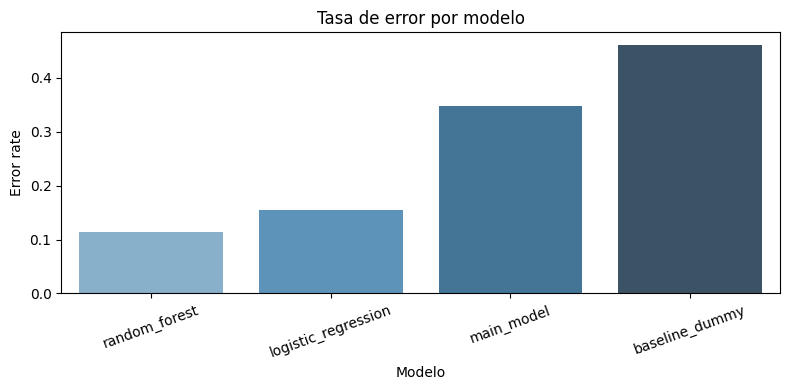

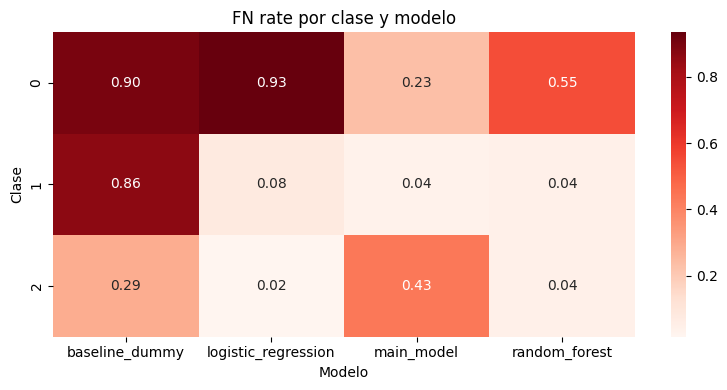

Error analysis guardado en: output\error_analysis.csv


,model,accuracy,precision,recall,f1,roc_auc,cv_f1_macro_mean,cv_f1_macro_std,total_errors,error_rate,delta_f1
0,random_forest,0.885261,0.848812,0.788392,0.807874,NaN,0.793450,0.014883,123,0.114739,0.000000
1,main_model,0.652985,0.683281,0.764815,0.667580,0.943301,NaN,NaN,372,0.347015,-0.140294
2,logistic_regression,0.845149,0.855352,0.656280,0.644938,NaN,0.646852,0.010311,166,0.154851,-0.162936
3,baseline_dummy,0.539179,0.316228,0.315851,0.316014,NaN,NaN,NaN,494,0.460821,-0.491860


,model,class,support,tp,fp,fn,tn,fn_rate,fp_rate
0,baseline_dummy,0,150,15,140,135,782,0.900000,0.151844
1,baseline_dummy,1,161,22,133,139,778,0.863354,0.145993
2,baseline_dummy,2,761,541,221,220,90,0.289093,0.710611
3,logistic_regression,0,150,10,2,140,920,0.933333,0.002169
4,logistic_regression,1,161,148,17,13,894,0.080745,0.018661
5,logistic_regression,2,761,748,147,13,164,0.017083,0.472669
6,random_forest,0,150,68,26,82,896,0.546667,0.028200
7,random_forest,1,161,154,12,7,899,0.043478,0.013172
8,random_forest,2,761,727,85,34,226,0.044678,0.273312
9,main_model,0,150,115,314,35,608,0.233333,0.340564


In [46]:
# 19. Comparación de modelos y error analysis

# --- Validación de entradas
if "y_test" not in globals():
    raise ValueError("y_test no está disponible para análisis de errores.")

y_true = y_test

# --- Mapear predicciones disponibles
model_preds = {}
if "y_test_base" in globals():
    model_preds["baseline_dummy"] = y_test_base
if "y_test_lr" in globals():
    model_preds["logistic_regression"] = y_test_lr
if "y_test_rf" in globals():
    model_preds["random_forest"] = y_test_rf
if "y_test_pred" in globals():
    model_preds["main_model"] = y_test_pred
elif "y_pred" in globals():
    model_preds["main_model"] = y_pred

# --- Filtro por longitud consistente
filtered = {}
for name, pred in model_preds.items():
    if len(pred) != len(y_true):
        print(f"[WARN] {name} ignorado: longitud distinta a y_test.")
    else:
        filtered[name] = pred
model_preds = filtered

if not model_preds:
    raise ValueError("No hay predicciones válidas para comparar.")

# --- Función de matriz de confusión (usar alias si existe)
cm_func = globals().get("sk_confusion_matrix")
if cm_func is None or not callable(cm_func):
    cm_func = globals().get("confusion_matrix")
if cm_func is None or not callable(cm_func):
    raise ValueError("No se encontró una función válida de confusion_matrix.")

labels = np.unique(y_true)
total = len(y_true)

error_rows = []
summary_rows = []

for name, pred in model_preds.items():
    cm = cm_func(y_true, pred, labels=labels)
    total_errors = int(total - np.trace(cm))
    summary_rows.append({
        "model": name,
        "total_errors": total_errors,
        "error_rate": float(total_errors / total)
    })

    for i, cls in enumerate(labels):
        support = int(cm[i, :].sum())
        tp = int(cm[i, i])
        fn = int(support - tp)
        fp = int(cm[:, i].sum() - tp)
        tn = int(total - (tp + fn + fp))
        fn_rate = float(fn / support) if support else 0.0
        fp_rate = float(fp / (fp + tn)) if (fp + tn) else 0.0

        error_rows.append({
            "model": name,
            "class": int(cls),
            "support": support,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
            "fn_rate": fn_rate,
            "fp_rate": fp_rate
        })

error_report = pd.DataFrame(error_rows)
error_summary = pd.DataFrame(summary_rows)

# --- Ranking de modelos
if "metrics_table" in globals() and isinstance(metrics_table, pd.DataFrame):
    model_ranking = metrics_table.copy()
    if "model" not in model_ranking.columns:
        model_ranking = model_ranking.reset_index().rename(columns={"index": "model"})
    model_ranking = model_ranking.merge(error_summary, on="model", how="left")
    if "f1" in model_ranking.columns:
        best_f1 = model_ranking["f1"].max()
        model_ranking["delta_f1"] = model_ranking["f1"] - best_f1
    model_ranking = model_ranking.sort_values(
        by=["f1", "accuracy", "error_rate"],
        ascending=[False, False, True]
    ).reset_index(drop=True)
else:
    model_ranking = error_summary.sort_values("error_rate").reset_index(drop=True)

# --- Guardar artefactos
out_dir = Path("output")
out_dir.mkdir(parents=True, exist_ok=True)
error_report_path = out_dir / "error_analysis.csv"
error_report.to_csv(error_report_path, index=False)

# --- Visualizaciones
plt.figure(figsize=(8, 4))
sns.barplot(
    data=error_summary.sort_values("error_rate"),
    x="model",
    y="error_rate",
    palette="Blues_d"
)
plt.title("Tasa de error por modelo")
plt.xlabel("Modelo")
plt.ylabel("Error rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

if not error_report.empty:
    pivot_fn = error_report.pivot_table(index="class", columns="model", values="fn_rate", aggfunc="mean")
    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot_fn, annot=True, fmt=".2f", cmap="Reds")
    plt.title("FN rate por clase y modelo")
    plt.xlabel("Modelo")
    plt.ylabel("Clase")
    plt.tight_layout()
    plt.show()

# --- Salidas en notebook
_display = globals().get("display", lambda x: print(x))
print(f"Error analysis guardado en: {error_report_path}")
_display(model_ranking)
_display(error_report.head(10))

## 20. Interpretabilidad (SHAP/LIME placeholders)
- Nombre exacto de la seccion: Interpretabilidad (SHAP/LIME placeholders)
- Objetivo tecnico: Explicar decisiones del modelo con metodos interpretables
- Subsecciones / bloques: SHAP; LIME; Analisis local vs global
- Tipo de codigo: Generacion de explicaciones
- Datos entran: `model_best`, `X_test`
- Datos salen: `explanations`
- Visualizaciones: SHAP summary, force plots
- Metricas: Estabilidad de explicaciones, top features
- Validaciones: Alineacion entre features y explicaciones
- Transformaciones: No aplica (solo explicacion)
- Errores a controlar: Alto costo computacional
- Resultados a guardar: `explanations_report.md`
- Artefactos a exportar: `shap_values.npy`
- Variables sugeridas: `shap_values`, `lime_explanations`
- Checkpoint / cache: Guardar explicaciones calculadas
- Notas de modularizacion: Funcion `run_explainability()`
- Reproducibilidad: Fijar muestras y seeds de explicacion
- Placeholder: agregar codigo en la celda inferior para interpretabilidad

 96%|=================== | 1434/1500 [00:15<00:00]       

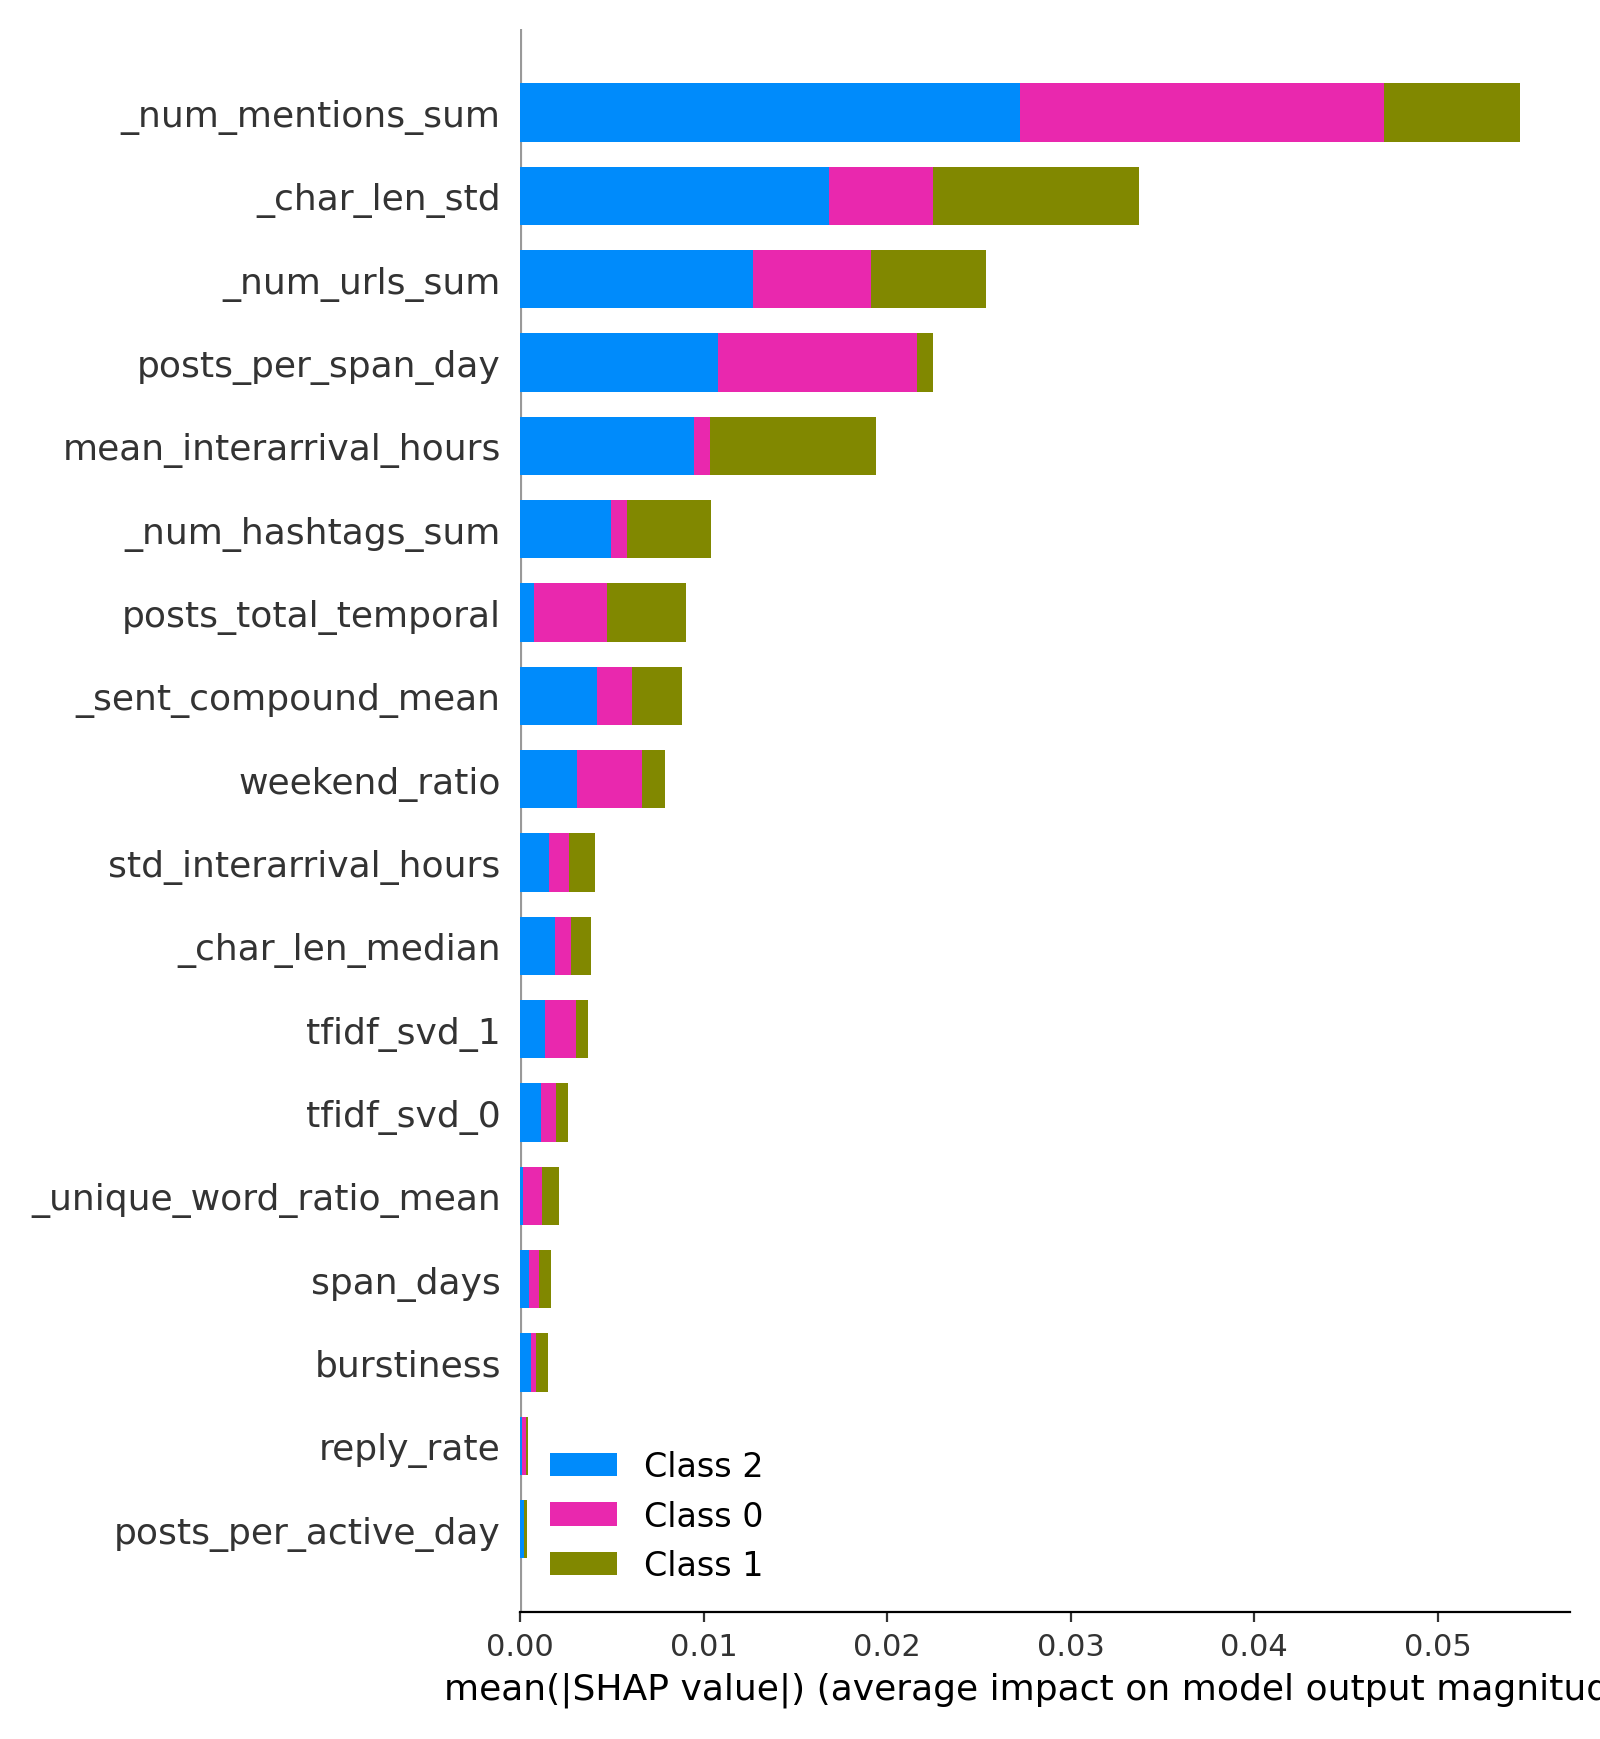

,feature,shap_importance
2,span_days,0.005412
0,reply_rate,0.003355
1,posts_total_temporal,0.003008


[INFO] SHAP: recomputed | LIME: computed | Reporte: output\artifacts\explanations_report.md


In [47]:
# --- 20. Interpretabilidad (SHAP/LIME placeholders)
import datetime
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

def _safe_sample(X, n, seed):
    if n is None:
        return X
    try:
        length = len(X)
    except Exception:
        return X
    if length <= n:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(length, size=n, replace=False)
    if hasattr(X, "iloc"):
        return X.iloc[idx]
    return X[idx]

def _safe_feature_names(X):
    if hasattr(X, "columns"):
        return list(X.columns)
    if hasattr(X, "shape") and len(X.shape) >= 2:
        return [f"f_{i}" for i in range(X.shape[1])]
    return []

def _as_numpy(X):
    if hasattr(X, "toarray"):
        return X.toarray()
    return np.array(X)

def _get_sample_shape(X):
    try:
        n_samples = X.shape[0]
        n_features = X.shape[1] if len(X.shape) > 1 else None
        return n_samples, n_features
    except Exception:
        if hasattr(X, "__len__"):
            return len(X), None
    return None, None

def _normalize_shap_values(shap_values):
    if isinstance(shap_values, np.ndarray) and shap_values.dtype == object:
        return list(shap_values)
    return shap_values

def _shap_shape_ok(shap_values, X):
    n_samples, n_features = _get_sample_shape(X)
    if shap_values is None:
        return False
    def _check_arr(arr):
        a = np.array(arr)
        if a.ndim == 1:
            return True
        if a.ndim == 2:
            if n_samples is not None and a.shape[0] != n_samples:
                return False
            if n_features is not None and a.shape[1] != n_features:
                return False
            return True
        if a.ndim == 3 and n_samples is not None:
            if a.shape[0] == n_samples and (n_features is None or a.shape[1] == n_features):
                return True
            if a.shape[1] == n_samples and (n_features is None or a.shape[2] == n_features):
                return True
            return False
        return True
    if isinstance(shap_values, (list, tuple)):
        return all(_check_arr(v) for v in shap_values if v is not None)
    return _check_arr(shap_values)

def _prepare_shap_for_plot(shap_values, X):
    n_samples, n_features = _get_sample_shape(X)
    if shap_values is None:
        return None
    if isinstance(shap_values, (list, tuple)):
        cleaned = []
        for v in shap_values:
            arr = np.array(v)
            if arr.ndim == 2:
                cleaned.append(arr)
            else:
                return None
        return cleaned if cleaned else None
    arr = np.array(shap_values)
    if arr.ndim == 2:
        return arr
    if arr.ndim == 3 and n_samples is not None:
        if arr.shape[0] == n_samples:
            return [arr[:, :, i] for i in range(arr.shape[2])]
        if arr.shape[1] == n_samples:
            return [arr[i, :, :] for i in range(arr.shape[0])]
    return None

def _coerce_shap_importance(shap_values):
    if isinstance(shap_values, (list, tuple)):
        parts = [_coerce_shap_importance(v) for v in shap_values]
        if not parts:
            return np.array([])
        min_len = min(len(p) for p in parts)
        parts = [p[:min_len] for p in parts]
        return np.mean(np.vstack(parts), axis=0)
    arr = np.array(shap_values)
    if arr.ndim == 3:
        arr = np.abs(arr).mean(axis=(0, 1))
    elif arr.ndim == 2:
        arr = np.abs(arr).mean(axis=0)
    elif arr.ndim == 1:
        arr = np.abs(arr)
    else:
        arr = arr.reshape(-1)
    return arr

def _wrap_predict_fn(model, feature_names):
    def _predict(x):
        df = pd.DataFrame(x, columns=feature_names)
        if hasattr(model, "predict_proba"):
            return model.predict_proba(df)
        return model.predict(df)
    return _predict

def run_explainability(
    model,
    X,
    cache_dir=None,
    artifacts_dir=None,
    sample_size=500,
    seed=None,
    top_k=20,
    force=False,
    max_lime_samples=5,
    max_lime_features=10,
    ):
    start_time = time.time()
    cache_dir = Path(cache_dir) if cache_dir is not None else Path("cache")
    artifacts_dir = Path(artifacts_dir) if artifacts_dir is not None else Path("output/artifacts")
    cache_dir.mkdir(parents=True, exist_ok=True)
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    seed = seed if seed is not None else 42
    X_sample = _safe_sample(X, sample_size, seed)
    feature_names = _safe_feature_names(X_sample)

    report_lines = []
    report_lines.append("# Interpretabilidad (SHAP/LIME)")
    report_lines.append(f"- timestamp: {datetime.datetime.now().isoformat()}")
    report_lines.append(f"- sample_size: {len(X_sample) if hasattr(X_sample, '__len__') else 'n/a'}")
    report_lines.append(f"- seed: {seed}")

    shap_values = None
    shap_values_obj = None
    shap_status = "skipped"
    shap_error = None
    shap_values_path = artifacts_dir / "shap_values.npy"
    shap_cache_path = cache_dir / "shap_values.npy"

    if not force and shap_values_path.exists():
        shap_values = np.load(shap_values_path, allow_pickle=True)
        shap_status = "loaded"
    elif not force and shap_cache_path.exists():
        shap_values = np.load(shap_cache_path, allow_pickle=True)
        shap_status = "loaded"
    else:
        try:
            import shap
            explainer = shap.Explainer(model, X_sample, feature_names=feature_names)
            shap_values_obj = explainer(X_sample)
            shap_values = getattr(shap_values_obj, "values", shap_values_obj)
            np.save(shap_values_path, shap_values)
            np.save(shap_cache_path, shap_values)
            shap_status = "computed"
        except Exception as exc:
            shap_error = str(exc)
            shap_status = "error"

    if shap_values is not None and shap_status == "loaded" and not _shap_shape_ok(shap_values, X_sample):
        try:
            import shap
            explainer = shap.Explainer(model, X_sample, feature_names=feature_names)
            shap_values_obj = explainer(X_sample)
            shap_values = getattr(shap_values_obj, "values", shap_values_obj)
            np.save(shap_values_path, shap_values)
            np.save(shap_cache_path, shap_values)
            shap_status = "recomputed"
        except Exception as exc:
            shap_error = str(exc)
            shap_status = "error"

    shap_values = _normalize_shap_values(shap_values)
    shap_importance_df = None
    stability_jaccard = None
    alignment_ok = None
    shap_plot_status = "skipped"
    shap_force_status = "skipped"

    if shap_values is not None and shap_status != "error":
        shap_importance = _coerce_shap_importance(shap_values)
        min_len = min(len(feature_names), len(shap_importance))
        feature_names = feature_names[:min_len]
        shap_importance = shap_importance[:min_len]
        alignment_ok = len(feature_names) == len(shap_importance)
        shap_importance_df = pd.DataFrame({
            "feature": feature_names,
            "shap_importance": shap_importance
        }).sort_values("shap_importance", ascending=False)
        shap_importance_df.to_csv(artifacts_dir / "shap_feature_importance.csv", index=False)
        if isinstance(shap_values, np.ndarray) and shap_values.ndim >= 2 and shap_values.shape[0] >= 2:
            mid = shap_values.shape[0] // 2
            part_a = _coerce_shap_importance(shap_values[:mid])
            part_b = _coerce_shap_importance(shap_values[mid:])
            min_len2 = min(len(part_a), len(part_b))
            part_a = part_a[:min_len2]
            part_b = part_b[:min_len2]
            top_a = set(np.argsort(part_a)[-top_k:])
            top_b = set(np.argsort(part_b)[-top_k:])
            union = len(top_a | top_b)
            stability_jaccard = (len(top_a & top_b) / union) if union else None
        try:
            import shap
            import matplotlib.pyplot as plt
            plot_values = _prepare_shap_for_plot(shap_values, X_sample)
            if plot_values is None:
                shap_plot_status = "skipped: shape mismatch"
            else:
                shap.summary_plot(plot_values, X_sample, show=False)
                plt.tight_layout()
                plt.savefig(artifacts_dir / "shap_summary.png", dpi=200)
                plt.close("all")
                shap_plot_status = "saved"
        except Exception as exc:
            shap_plot_status = f"error: {exc}"
        if shap_values_obj is not None:
            try:
                import shap
                if hasattr(X_sample, "iloc"):
                    x0 = X_sample.iloc[0]
                else:
                    x0 = X_sample[0]
                base_values = getattr(shap_values_obj, "base_values", None)
                values = getattr(shap_values_obj, "values", None)
                if base_values is not None and values is not None:
                    force_plot = shap.force_plot(base_values[0], values[0], x0, feature_names=feature_names, matplotlib=False)
                    shap.save_html(artifacts_dir / "shap_force.html", force_plot)
                    shap_force_status = "saved"
            except Exception as exc:
                shap_force_status = f"error: {exc}"

    lime_explanations = None
    lime_status = "skipped"
    lime_error = None
    try:
        from lime.lime_tabular import LimeTabularExplainer
        X_np = _as_numpy(X_sample)
        if X_np.ndim == 1:
            X_np = X_np.reshape(1, -1)
        if X_np.ndim > 2:
            X_np = X_np.reshape(X_np.shape[0], -1)
        if X_np.shape[0] == 0 or X_np.shape[1] == 0:
            raise ValueError("empty sample for LIME")
        if len(feature_names) != X_np.shape[1]:
            feature_names = [f"f_{i}" for i in range(X_np.shape[1])]
        if hasattr(X_sample, "columns") and feature_names:
            predict_fn = _wrap_predict_fn(model, feature_names)
        else:
            if hasattr(model, "predict_proba"):
                predict_fn = model.predict_proba
            else:
                predict_fn = model.predict
        mode = "classification" if hasattr(model, "predict_proba") else "regression"
        class_names = [str(c) for c in getattr(model, "classes_", [])] or None
        explainer = LimeTabularExplainer(
            X_np,
            feature_names=feature_names,
            class_names=class_names,
            mode=mode,
            discretize_continuous=True,
            random_state=seed
        )
        lime_explanations = []
        max_local = min(max_lime_samples, X_np.shape[0])
        num_feats = min(max_lime_features, X_np.shape[1])
        for i in range(max_local):
            exp = explainer.explain_instance(X_np[i], predict_fn, num_features=num_feats)
            lime_explanations.append(exp.as_list())
        with open(artifacts_dir / "lime_explanations.json", "w", encoding="utf-8") as f:
            json.dump(lime_explanations, f, indent=2)
        lime_status = "computed"
    except ImportError:
        lime_error = "lime not installed"
        lime_status = "missing"
    except Exception as exc:
        lime_error = str(exc)
        lime_status = "error"

    report_lines.append("## SHAP")
    report_lines.append(f"- status: {shap_status}")
    if shap_error:
        report_lines.append(f"- error: {shap_error}")
    report_lines.append(f"- plot_summary: {shap_plot_status}")
    report_lines.append(f"- plot_force: {shap_force_status}")
    report_lines.append(f"- alignment_features_explanations: {alignment_ok}")
    report_lines.append(f"- stability_jaccard_top{top_k}: {stability_jaccard}")
    if shap_importance_df is not None:
        top_features = shap_importance_df.head(top_k)["feature"].tolist()
        report_lines.append(f"- top_features: {', '.join(top_features)}")
    report_lines.append("## LIME")
    report_lines.append(f"- status: {lime_status}")
    if lime_error:
        report_lines.append(f"- error: {lime_error}")
    report_lines.append("## Analisis local vs global")
    report_lines.append(f"- global_ok: {shap_importance_df is not None}")
    report_lines.append(f"- local_ok: {lime_explanations is not None}")
    report_lines.append(f"- runtime_seconds: {round(time.time() - start_time, 3)}")

    report_path = artifacts_dir / "explanations_report.md"
    with open(report_path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))

    if shap_plot_status == "saved" and (artifacts_dir / "shap_summary.png").exists():
        display(Image(filename=str(artifacts_dir / "shap_summary.png")))
    if shap_force_status == "saved":
        print(f"[INFO] SHAP force plot guardado en: {artifacts_dir / 'shap_force.html'}")
    if shap_importance_df is not None:
        display(shap_importance_df.head(top_k))
    print(f"[INFO] SHAP: {shap_status} | LIME: {lime_status} | Reporte: {report_path}")

    return {
        "shap_values": shap_values,
        "shap_importance": shap_importance_df,
        "lime_explanations": lime_explanations,
        "report_path": str(report_path),
        "status": "ok" if shap_status != "error" else "partial"
    }

_default_cache = globals().get("CACHE_DIR", Path("cache"))
_default_artifacts = globals().get("ARTIFACTS_DIR", Path("output/artifacts"))
_default_seed = globals().get("SEED", 42)

if "model_best" in globals() and "X_test" in globals():
    explanations = run_explainability(
        model_best,
        X_test,
        cache_dir=_default_cache,
        artifacts_dir=_default_artifacts,
        sample_size=500,
        seed=_default_seed,
        force=False
    )
else:
    explanations = {"status": "skipped", "reason": "model_best or X_test not found"}
    print("[WARN] model_best or X_test not found. Skipping explainability.")

## 21. Sesgos, robustez y drift
- Nombre exacto de la seccion: Sesgos, robustez y drift
- Objetivo tecnico: Evaluar estabilidad del modelo y posibles sesgos
- Subsecciones / bloques: Evaluacion de sesgos; Robustez del modelo; Drift analysis
- Tipo de codigo: Fairness metrics, stress tests, drift metrics
- Datos entran: `y_test`, `y_pred`, metadatos de grupos
- Datos salen: `bias_report`, `robustness_report`, `drift_report`
- Visualizaciones: Performance por grupo, curvas de drift
- Metricas: Disparity ratios, PSI/KS, performance gaps
- Validaciones: Tamaños minimos por grupo, consistencia temporal
- Transformaciones: Segmentacion por cohortes, ventanas temporales
- Errores a controlar: Inferencias con subgrupos pequeños
- Resultados a guardar: `bias_report.json`
- Artefactos a exportar: `drift_report.json`
- Variables sugeridas: `group_cols`, `drift_window`
- Checkpoint / cache: Guardar reportes por version de modelo
- Notas de modularizacion: Funcion `evaluate_bias_and_drift()`
- Reproducibilidad: Fijar definicion de grupos y ventanas
- Placeholder: agregar codigo en la celda inferior para sesgos y drift

In [48]:
# --- 21. Sesgos, robustez y drift (placeholders con metricas basicas)
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _safe_json(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def _as_1d(a):
    return np.asarray(a).ravel()

def _to_labels(y_pred):
    arr = np.asarray(y_pred)
    if arr.ndim == 2:
        if arr.shape[1] == 2:
            return (arr[:, 1] >= 0.5).astype(int)
        return np.argmax(arr, axis=1)
    if np.issubdtype(arr.dtype, np.floating):
        if np.nanmin(arr) >= 0 and np.nanmax(arr) <= 1:
            return (arr >= 0.5).astype(int)
    return arr.astype(int)

def _to_binary(y_true):
    arr = _as_1d(y_true)
    if arr.dtype == bool:
        return arr.astype(int), True
    unique = np.unique(arr)
    if len(unique) == 2:
        if set(unique) == {0, 1}:
            return arr.astype(int), True
        mapping = {unique[0]: 0, unique[1]: 1}
        return np.vectorize(mapping.get)(arr).astype(int), True
    return arr, False

def _binary_metrics(y_true, y_pred):
    y_true_bin, is_binary = _to_binary(y_true)
    y_pred_lab = _to_labels(y_pred)
    if not is_binary:
        acc = float(np.mean(y_true_bin == y_pred_lab))
        return {"accuracy": acc, "precision": None, "recall": None, "f1": None, "positive_rate": None}
    tp = int(np.sum((y_true_bin == 1) & (y_pred_lab == 1)))
    tn = int(np.sum((y_true_bin == 0) & (y_pred_lab == 0)))
    fp = int(np.sum((y_true_bin == 0) & (y_pred_lab == 1)))
    fn = int(np.sum((y_true_bin == 1) & (y_pred_lab == 0)))
    acc = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    positive_rate = (tp + fp) / max(tp + tn + fp + fn, 1)
    return {
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "positive_rate": float(positive_rate),
    }

def _group_metrics(df, y_true_col, y_pred_col, group_cols, min_group_size=30):
    rows = []
    for col in group_cols:
        if col not in df.columns:
            continue
        for value, g in df.groupby(col):
            if len(g) < min_group_size:
                continue
            metrics = _binary_metrics(g[y_true_col], g[y_pred_col])
            rows.append({
                "group_col": col,
                "group": value,
                "n": int(len(g)),
                **metrics
            })
    return pd.DataFrame(rows)

def _disparity(df, metric):
    if df.empty or metric not in df.columns:
        return {}
    stats = df.groupby("group_col")[metric].agg(["min", "max"]).reset_index()
    stats["ratio"] = stats["max"] / stats["min"].replace(0, np.nan)
    return stats.to_dict(orient="records")

def _bootstrap_metrics(y_true, y_pred, n_boot=100, seed=42):
    y_true_arr = _as_1d(y_true)
    y_pred_arr = np.asarray(y_pred)
    n = len(y_true_arr)
    if n == 0:
        return {}
    rng = np.random.default_rng(seed)
    metrics_list = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        metrics_list.append(_binary_metrics(y_true_arr[idx], y_pred_arr[idx]))
    keys = ["accuracy", "precision", "recall", "f1", "positive_rate"]
    out = {"n_boot": n_boot}
    for k in keys:
        vals = [m[k] for m in metrics_list if m.get(k) is not None]
        out[f"{k}_std"] = float(np.std(vals)) if vals else None
    return out

def _psi(expected, actual, bins=10, eps=1e-6):
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]
    if len(expected) == 0 or len(actual) == 0:
        return None
    quantiles = np.quantile(expected, np.linspace(0, 1, bins + 1))
    quantiles[0] -= 1e-9
    quantiles[-1] += 1e-9
    e_counts = np.histogram(expected, bins=quantiles)[0]
    a_counts = np.histogram(actual, bins=quantiles)[0]
    e_pct = e_counts / max(e_counts.sum(), 1)
    a_pct = a_counts / max(a_counts.sum(), 1)
    return float(np.sum((a_pct - e_pct) * np.log((a_pct + eps) / (e_pct + eps))))

def _ks(a, b):
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if len(a) == 0 or len(b) == 0:
        return None
    a = np.sort(a)
    b = np.sort(b)
    all_vals = np.sort(np.concatenate([a, b]))
    cdf_a = np.searchsorted(a, all_vals, side="right") / len(a)
    cdf_b = np.searchsorted(b, all_vals, side="right") / len(b)
    return float(np.max(np.abs(cdf_a - cdf_b)))

def _drift_report(df, drift_window=None, max_features=20):
    if df is None or not hasattr(df, "select_dtypes"):
        return pd.DataFrame()
    num_cols = list(df.select_dtypes(include=[np.number]).columns)
    if not num_cols:
        return pd.DataFrame()
    num_cols = num_cols[:max_features]
    if isinstance(drift_window, str) and drift_window in df.columns:
        df_sorted = df.sort_values(drift_window)
    else:
        df_sorted = df
    mid = len(df_sorted) // 2
    if mid == 0:
        return pd.DataFrame()
    base = df_sorted.iloc[:mid]
    curr = df_sorted.iloc[mid:]
    rows = []
    for col in num_cols:
        psi = _psi(base[col].to_numpy(), curr[col].to_numpy())
        ks = _ks(base[col].to_numpy(), curr[col].to_numpy())
        rows.append({"feature": col, "psi": psi, "ks": ks})
    return pd.DataFrame(rows)

artifacts_dir = globals().get("ARTIFACTS_DIR", Path("output/artifacts"))
artifacts_dir.mkdir(parents=True, exist_ok=True)

bias_report = {"status": "skipped"}
robustness_report = {"status": "skipped"}
drift_report = {"status": "skipped"}

if "y_test" in globals() and "y_pred" in globals():
    y_true = globals()["y_test"]
    y_pred = globals()["y_pred"]
    df_groups = None
    if "metadata" in globals() and isinstance(globals()["metadata"], pd.DataFrame):
        df_groups = globals()["metadata"].copy()
    elif "X_test" in globals() and isinstance(globals()["X_test"], pd.DataFrame):
        df_groups = globals()["X_test"].copy()
    group_cols = globals().get("group_cols", []) or []
    if df_groups is not None and group_cols:
        df_groups = df_groups.copy()
        df_groups["_y_true"] = _as_1d(y_true)
        df_groups["_y_pred"] = _as_1d(_to_labels(y_pred))
        group_metrics_df = _group_metrics(df_groups, "_y_true", "_y_pred", group_cols)
        bias_report = {
            "status": "ok",
            "group_metrics": group_metrics_df.to_dict(orient="records"),
            "disparity_accuracy": _disparity(group_metrics_df, "accuracy"),
            "disparity_f1": _disparity(group_metrics_df, "f1"),
        }
        if not group_metrics_df.empty:
            plt.figure(figsize=(8, 4))
            group_metrics_df.sort_values("accuracy").plot(kind="barh", x="group", y="accuracy", legend=False)
            plt.title("Accuracy por grupo")
            plt.tight_layout()
            plt.savefig(artifacts_dir / "bias_accuracy_by_group.png", dpi=150)
            plt.close()
    else:
        bias_report = {"status": "skipped", "reason": "group_cols o metadata/X_test no disponibles"}
    robustness_report = {"status": "ok", "bootstrap": _bootstrap_metrics(y_true, y_pred, n_boot=100, seed=42)}

if "X_test" in globals() and isinstance(globals()["X_test"], pd.DataFrame):
    drift_window = globals().get("drift_window", None)
    drift_df = _drift_report(globals()["X_test"], drift_window=drift_window, max_features=20)
    drift_report = {"status": "ok", "drift_metrics": drift_df.to_dict(orient="records")}
    if not drift_df.empty:
        top = drift_df.sort_values("psi", ascending=False).head(10)
        plt.figure(figsize=(8, 4))
        plt.barh(top["feature"], top["psi"])
        plt.title("PSI top features")
        plt.tight_layout()
        plt.savefig(artifacts_dir / "drift_psi_top.png", dpi=150)
        plt.close()

with open(artifacts_dir / "bias_report.json", "w", encoding="utf-8") as f:
    json.dump(bias_report, f, indent=2, default=_safe_json)
with open(artifacts_dir / "drift_report.json", "w", encoding="utf-8") as f:
    json.dump(drift_report, f, indent=2, default=_safe_json)
with open(artifacts_dir / "robustness_report.json", "w", encoding="utf-8") as f:
    json.dump(robustness_report, f, indent=2, default=_safe_json)

bias_report, robustness_report, drift_report

({'status': 'skipped',
  'reason': 'group_cols o metadata/X_test no disponibles'},
 {'status': 'ok',
  'bootstrap': {'n_boot': 100,
   'accuracy_std': 0.015222394388971563,
   'precision_std': None,
   'recall_std': None,
   'f1_std': None,
   'positive_rate_std': None}},
 {'status': 'ok',
  'drift_metrics': [{'feature': 'reply_rate',
    'psi': 0.0,
    'ks': 0.005597014925373234},
   {'feature': 'posts_total_temporal',
    'psi': 0.014187972081450015,
    'ks': 0.05410447761194026},
   {'feature': 'span_days',
    'psi': 0.01693490895599138,
    'ks': 0.05410447761194037},
   {'feature': 'posts_per_active_day', 'psi': 0.0, 'ks': 0.033582089552238736},
   {'feature': 'posts_per_span_day',
    'psi': 0.01633286324902851,
    'ks': 0.06343283582089554},
   {'feature': 'mean_interarrival_hours',
    'psi': 0.016195393900003345,
    'ks': 0.06156716417910446},
   {'feature': 'std_interarrival_hours',
    'psi': 0.013146211650347624,
    'ks': 0.029850746268656803},
   {'feature': 'burstin

## 22. Visualizaciones finales y outputs dashboard-ready
- Nombre exacto de la seccion: Visualizaciones finales y outputs dashboard-ready
- Objetivo tecnico: Preparar visualizaciones y tablas finales para reporting
- Subsecciones / bloques: Visualizaciones finales; Dashboard-ready outputs
- Tipo de codigo: Plotting, agregaciones, formateo de tablas
- Datos entran: `metrics_table`, `eda_report`, `df_features`
- Datos salen: `dashboard_tables`, `final_figures`
- Visualizaciones: Graficos resumen, dashboards
- Metricas: No aplica (usa metricas ya calculadas)
- Validaciones: Consistencia de labels y escalas
- Transformaciones: Agregaciones y redondeo
- Errores a controlar: Inconsistencia entre figuras y tablas
- Resultados a guardar: `figures/`
- Artefactos a exportar: `dashboard_data.parquet`
- Variables sugeridas: `dashboard_tables`, `final_figures`
- Checkpoint / cache: Guardar tablas agregadas finales
- Notas de modularizacion: Helpers `build_dashboard_outputs()`
- Reproducibilidad: Fijar estilos y orden de categorias
- Placeholder: agregar codigo en la celda inferior para visuales finales

In [49]:
# --- 22. Visualizaciones finales y outputs dashboard-ready
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _round_df(df, decimals=3):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        out[num_cols] = out[num_cols].round(decimals)
    return out

def _safe_json(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

def build_dashboard_outputs(metrics_table, eda_report, df_features, figures_dir, artifacts_dir, rounding=3):
    figures_dir.mkdir(parents=True, exist_ok=True)
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    dashboard_tables = {}
    final_figures = []
    warnings = []

    if isinstance(metrics_table, pd.DataFrame) and not metrics_table.empty:
        metrics_df = metrics_table.copy()
        if "model" in metrics_df.columns:
            order = list(metrics_df["model"].astype(str).unique())
            metrics_df["model"] = pd.Categorical(metrics_df["model"].astype(str), categories=order, ordered=True)
        metrics_df = _round_df(metrics_df, rounding)
        dashboard_tables["metrics_table"] = metrics_df

        metric_col = None
        for candidate in ["f1", "f1_score", "accuracy", "auc", "roc_auc", "precision", "recall"]:
            if candidate in metrics_df.columns:
                metric_col = candidate
                break
        if metric_col:
            x_col = "model" if "model" in metrics_df.columns else metrics_df.columns[0]
            if x_col != metric_col:
                plot_df = metrics_df.sort_values(metric_col, ascending=False)
                plt.figure(figsize=(8, 4))
                plt.barh(plot_df[x_col].astype(str), plot_df[metric_col])
                plt.title(f"Resumen de {metric_col}")
                plt.xlabel(metric_col)
                plt.tight_layout()
                fig_path = figures_dir / f"summary_{metric_col}.png"
                plt.savefig(fig_path, dpi=150)
                plt.close()
                final_figures.append(str(fig_path))
        else:
            warnings.append("metrics_table sin columna de metrica conocida")
    else:
        warnings.append("metrics_table no disponible o vacio")

    if isinstance(df_features, pd.DataFrame) and not df_features.empty:
        num_cols = df_features.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 0:
            stats = df_features[num_cols].agg(["mean", "std", "median"]).T
            stats = stats.sort_values("std", ascending=False)
            stats = _round_df(stats, rounding)
            stats = stats.reset_index().rename(columns={"index": "feature"})
            dashboard_tables["feature_summary"] = stats
            top = stats.head(10)
            plt.figure(figsize=(8, 4))
            plt.barh(top["feature"].astype(str), top["std"])
            plt.title("Top features por variabilidad (std)")
            plt.xlabel("std")
            plt.tight_layout()
            fig_path = figures_dir / "feature_variability_top.png"
            plt.savefig(fig_path, dpi=150)
            plt.close()
            final_figures.append(str(fig_path))
        else:
            warnings.append("df_features sin columnas numericas")
    else:
        warnings.append("df_features no disponible o vacio")

    if isinstance(eda_report, dict):
        rows = []
        for k, v in eda_report.items():
            if isinstance(v, (str, int, float, bool)):
                rows.append({"metric": k, "value": v})
        if rows:
            dashboard_tables["eda_overview"] = pd.DataFrame(rows)
    elif isinstance(eda_report, str):
        dashboard_tables["eda_overview"] = pd.DataFrame([{"metric": "eda_report", "value": eda_report}])

    frames = []
    for name, df in dashboard_tables.items():
        if isinstance(df, pd.DataFrame):
            df_out = df.copy()
            df_out.insert(0, "table", name)
            frames.append(df_out)
    dashboard_data = pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()

    parquet_path = artifacts_dir / "dashboard_data.parquet"
    parquet_status = "saved"
    try:
        dashboard_data.to_parquet(parquet_path, index=False)
    except Exception as exc:
        parquet_status = f"error: {exc}"
        dashboard_data.to_csv(artifacts_dir / "dashboard_data.csv", index=False)
        warnings.append("fallback a CSV por fallo en parquet")

    meta = {
        "figures": final_figures,
        "tables": list(dashboard_tables.keys()),
        "warnings": warnings,
        "parquet_status": parquet_status,
    }
    with open(artifacts_dir / "dashboard_meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, default=_safe_json)

    return dashboard_tables, final_figures, meta

figures_dir = Path("figures")
artifacts_dir = globals().get("ARTIFACTS_DIR", Path("output/artifacts"))

if "metrics_table" in globals() or "eda_report" in globals() or "df_features" in globals():
    dashboard_tables, final_figures, dashboard_meta = build_dashboard_outputs(
        globals().get("metrics_table", None),
        globals().get("eda_report", None),
        globals().get("df_features", None),
        figures_dir=figures_dir,
        artifacts_dir=artifacts_dir,
        rounding=3
    )
    dashboard_tables, final_figures, dashboard_meta
else:
    print("[WARN] metrics_table/eda_report/df_features no disponibles. Skipping dashboard outputs.")

## 23. Exportacion de resultados, metricas y modelos
- Nombre exacto de la seccion: Exportacion de resultados, metricas y modelos
- Objetivo tecnico: Persistir artefactos para reutilizacion y despliegue
- Subsecciones / bloques: Exportacion de resultados; Exportacion de metricas; Exportacion de modelos
- Tipo de codigo: Serialization, escritura de archivos
- Datos entran: `metrics_table`, `model_best`, `dashboard_tables`
- Datos salen: Archivos exportados en `ARTIFACTS_DIR`
- Visualizaciones: No aplica
- Metricas: No aplica
- Validaciones: Escritura correcta, integridad de archivos
- Transformaciones: Serializacion (pickle, parquet, json)
- Errores a controlar: Rutas invalidas, permisos
- Resultados a guardar: `results_summary.csv`
- Artefactos a exportar: `model_best.pkl`, `metrics.json`
- Variables sugeridas: `ARTIFACTS_DIR`, `EXPORTS`
- Checkpoint / cache: Versionar artefactos por run
- Notas de modularizacion: Funcion `export_artifacts()`
- Reproducibilidad: Incluir metadata de version en exports
- Placeholder: agregar codigo en la celda inferior para exportacion

In [50]:
import json
import pickle
from pathlib import Path
import pandas as pd
import numpy as np
import datetime

# --- 23. Exportación de resultados, métricas y modelos
# Objetivo: Persistir artefactos para reutilización y despliegue
# Entradas: metrics_table, model_best, dashboard_tables, feature_importance
# Salidas: Archivos exportados en ARTIFACTS_DIR
# Artefactos: model_best.pkl, metrics.json, results_summary.csv


ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def _safe_json(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (set, frozenset)):
        return list(obj)
    if isinstance(obj, bytes):
        return obj.decode()
    if hasattr(obj, 'isoformat'):
        return obj.isoformat()
    return str(obj)

# --- 1. Exportar métricas principales
if 'metrics_table' in globals() and isinstance(metrics_table, pd.DataFrame):
    metrics_export = metrics_table.copy()
    metrics_export['export_timestamp'] = datetime.datetime.now().isoformat()
    metrics_export['run_id'] = RUN_ID
    
    # CSV
    metrics_csv_path = ARTIFACTS_DIR / 'metrics.csv'
    metrics_export.to_csv(metrics_csv_path, index=False)
    
    # JSON
    metrics_json_path = ARTIFACTS_DIR / 'metrics.json'
    with open(metrics_json_path, 'w', encoding='utf-8') as f:
        json.dump(metrics_export.to_dict(orient='records'), f, indent=2, default=_safe_json)
    
    print(f"Métricas exportadas: {metrics_csv_path}, {metrics_json_path}")
else:
    print("[WARN] metrics_table no disponible para exportar")

# --- 2. Exportar resumen de resultados
results_summary_rows = []

if 'metrics_table' in globals() and not metrics_table.empty:
    best_model_row = metrics_table.iloc[0] if len(metrics_table) > 0 else None
    if best_model_row is not None:
        results_summary_rows.append({
            'metric': 'best_model',
            'value': best_model_row.get('model', 'unknown')
        })
        for col in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr_macro']:
            if col in metrics_table.columns:
                results_summary_rows.append({
                    'metric': col,
                    'value': float(best_model_row[col]) if pd.notna(best_model_row[col]) else None
                })

if 'feature_importance' in globals() and isinstance(feature_importance, pd.DataFrame):
    top_feature = feature_importance.iloc[0] if len(feature_importance) > 0 else None
    if top_feature is not None:
        results_summary_rows.append({
            'metric': 'top_feature',
            'value': top_feature.get('feature', 'unknown')
        })
        results_summary_rows.append({
            'metric': 'top_feature_importance',
            'value': float(top_feature.get('importance', 0))
        })

if 'feature_catalog' in globals() and isinstance(feature_catalog, dict):
    results_summary_rows.append({
        'metric': 'n_features',
        'value': feature_catalog.get('n_features_total', 0)
    })
    results_summary_rows.append({
        'metric': 'target_col',
        'value': feature_catalog.get('target_col', 'unknown')
    })
    results_summary_rows.append({
        'metric': 'target_match_rate',
        'value': feature_catalog.get('target_match_rate', None)
    })

if 'model_comparison' in globals() and isinstance(model_comparison, pd.DataFrame):
    results_summary_rows.append({
        'metric': 'n_models_evaluated',
        'value': len(model_comparison)
    })

results_summary_rows.append({
    'metric': 'run_id',
    'value': RUN_ID
})
results_summary_rows.append({
    'metric': 'export_timestamp',
    'value': datetime.datetime.now().isoformat()
})

if results_summary_rows:
    results_summary_df = pd.DataFrame(results_summary_rows)
    results_summary_path = ARTIFACTS_DIR / 'results_summary.csv'
    results_summary_df.to_csv(results_summary_path, index=False)
    print(f"Resumen de resultados exportado: {results_summary_path}")

# --- 3. Exportar feature importance (si existe)
if 'feature_importance' in globals() and isinstance(feature_importance, pd.DataFrame):
    feature_importance_path = ARTIFACTS_DIR / 'feature_importance_export.csv'
    feature_importance.to_csv(feature_importance_path, index=False)
    print(f"Feature importance exportado: {feature_importance_path}")

# --- 4. Exportar modelo best (si existe y no está ya guardado)
if 'model_best' in globals():
    try:
        model_bundle_path = ARTIFACTS_DIR / 'model_best_final.pkl'
        if 'model_bundle' in globals():
            with open(model_bundle_path, 'wb') as f:
                pickle.dump(model_bundle, f)
        else:
            bundle = {
                'model': model_best,
                'preprocess_pipeline': preprocess_pipeline if 'preprocess_pipeline' in globals() else None,
                'label_encoder': le if 'le' in globals() else None,
                'target_col': target_col if 'target_col' in globals() else None,
                'run_id': RUN_ID,
                'export_timestamp': datetime.datetime.now().isoformat()
            }
            with open(model_bundle_path, 'wb') as f:
                pickle.dump(bundle, f)
        print(f"Modelo exportado: {model_bundle_path}")
    except Exception as e:
        print(f"[ERROR] No se pudo exportar modelo: {e}")

# --- 5. Exportar metadata y configuración de experimento
experiment_metadata = {
    'run_id': RUN_ID,
    'export_timestamp': datetime.datetime.now().isoformat(),
    'seed': SEED if 'SEED' in globals() else None,
    'random_state': RANDOM_STATE if 'RANDOM_STATE' in globals() else None,
    'target_col': target_col if 'target_col' in globals() else None,
    'n_features': feature_catalog.get('n_features_total', None) if 'feature_catalog' in globals() else None,
    'n_rows_features': int(df_features.shape[0]) if 'df_features' in globals() else None,
    'train_size': int(len(X_train)) if 'X_train' in globals() else None,
    'val_size': int(len(X_val)) if 'X_val' in globals() else None,
    'test_size': int(len(X_test)) if 'X_test' in globals() else None,
    'best_model': metrics_table.iloc[0]['model'] if 'metrics_table' in globals() and len(metrics_table) > 0 else None,
}

metadata_path = ARTIFACTS_DIR / 'experiment_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(experiment_metadata, f, indent=2, default=_safe_json)
print(f"Metadata del experimento exportada: {metadata_path}")

# --- 6. Crear manifest de exportación
export_manifest = {
    'run_id': RUN_ID,
    'export_timestamp': datetime.datetime.now().isoformat(),
    'artifacts': {
        'metrics_csv': str(ARTIFACTS_DIR / 'metrics.csv') if (ARTIFACTS_DIR / 'metrics.csv').exists() else None,
        'metrics_json': str(ARTIFACTS_DIR / 'metrics.json') if (ARTIFACTS_DIR / 'metrics.json').exists() else None,
        'results_summary': str(ARTIFACTS_DIR / 'results_summary.csv') if (ARTIFACTS_DIR / 'results_summary.csv').exists() else None,
        'feature_importance': str(ARTIFACTS_DIR / 'feature_importance_export.csv') if (ARTIFACTS_DIR / 'feature_importance_export.csv').exists() else None,
        'model_best': str(ARTIFACTS_DIR / 'model_best_final.pkl') if (ARTIFACTS_DIR / 'model_best_final.pkl').exists() else None,
        'experiment_metadata': str(metadata_path) if metadata_path.exists() else None,
        'model_comparison': str(ARTIFACTS_DIR / 'model_comparison.csv') if (ARTIFACTS_DIR / 'model_comparison.csv').exists() else None,
        'feature_catalog': str(Path('feature_catalog.json')) if Path('feature_catalog.json').exists() else None,
    }
}

manifest_path = ARTIFACTS_DIR / 'export_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(export_manifest, f, indent=2, default=_safe_json)
print(f"Manifest de exportación: {manifest_path}")

print(f"\n✓ Exportación completada. Artefactos disponibles en: {ARTIFACTS_DIR}")

Métricas exportadas: output\artifacts\metrics.csv, output\artifacts\metrics.json
Resumen de resultados exportado: output\artifacts\results_summary.csv
Feature importance exportado: output\artifacts\feature_importance_export.csv
Modelo exportado: output\artifacts\model_best_final.pkl
Metadata del experimento exportada: output\artifacts\experiment_metadata.json
Manifest de exportación: output\artifacts\export_manifest.json

✓ Exportación completada. Artefactos disponibles en: output\artifacts


## 24. Logging experimental y tracking de experimentos
- Nombre exacto de la seccion: Logging experimental y tracking de experimentos
- Objetivo tecnico: Registrar ejecuciones y compararlas en el tiempo
- Subsecciones / bloques: Logging experimental; Tracking de experimentos
- Tipo de codigo: Logger, trackers (MLflow u otros)
- Datos entran: `run_config`, `metrics_table`, `model_params`
- Datos salen: `experiment_log`, `run_registry`
- Visualizaciones: Comparacion de runs (si aplica)
- Metricas: Metadatos de run, tiempos, metricas clave
- Validaciones: Complecion de logs, ids unicos
- Transformaciones: Formateo de eventos y metadata
- Errores a controlar: Logs incompletos, colisiones de run_id
- Resultados a guardar: `experiments.csv`
- Artefactos a exportar: `run_registry.json`
- Variables sugeridas: `RUN_ID`, `TRACKING_URI`
- Checkpoint / cache: Log al final de cada etapa
- Notas de modularizacion: Funcion `log_experiment()`
- Reproducibilidad: Guardar config y seed por run
- Placeholder: agregar codigo en la celda inferior para tracking

In [51]:
import json
from pathlib import Path
import datetime
import pandas as pd
import numpy as _np

# 24. Logging experimental y tracking de experimentos (celda nueva)

ARTIFACTS_DIR = globals().get('ARTIFACTS_DIR', Path('output/artifacts'))
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

def _safe_json(obj):
    if isinstance(obj, (_np.integer,)):
        return int(obj)
    if isinstance(obj, (_np.floating,)):
        return float(obj)
    if isinstance(obj, _np.ndarray):
        return obj.tolist()
    if isinstance(obj, (set, frozenset)):
        return list(obj)
    if hasattr(obj, 'isoformat'):
        return obj.isoformat()
    return obj

def log_experiment(run_id=None, metrics_table=None, feature_catalog=None, model_bundle=None, artifacts_dir=ARTIFACTS_DIR, extra=None):
    run_id = run_id or globals().get('RUN_ID')
    ts = datetime.datetime.now().isoformat()
    artifacts_dir = Path(artifacts_dir)
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    # derive summary metrics
    summary = {}
    if isinstance(metrics_table, pd.DataFrame) and not metrics_table.empty:
        top = metrics_table.iloc[0].to_dict()
        summary.update({k: _safe_json(v) for k, v in top.items() if k != 'classification_report'})
    # fallback best_model from globals
    if 'model_bundle' in globals() and model_bundle is None:
        model_bundle = globals().get('model_bundle')

    record = {
        'run_id': run_id,
        'timestamp': ts,
        'seed': globals().get('SEED'),
        'random_state': globals().get('RANDOM_STATE'),
        'python_version': globals().get('env_info', {}).get('python_version'),
        'n_features': feature_catalog.get('n_features_total') if isinstance(feature_catalog, dict) else (globals().get('feature_catalog', {}).get('n_features_total') if 'feature_catalog' in globals() else None),
        'n_rows_features': int(globals().get('df_features').shape[0]) if 'df_features' in globals() else None,
        'best_model': summary.get('model') or (model_bundle.get('model_name') if isinstance(model_bundle, dict) else None),
        'metrics_summary': summary,
        'artifacts_dir': str(artifacts_dir),
        'extra': extra or {}
    }

    # append to CSV registry
    csv_path = artifacts_dir / 'experiments.csv'
    df_row = pd.DataFrame([record])
    try:
        if csv_path.exists():
            df_row.to_csv(csv_path, mode='a', header=False, index=False)
        else:
            df_row.to_csv(csv_path, index=False)
    except Exception:
        # fallback to writing minimal CSV in project root
        df_row.to_csv('experiments.csv', mode='a', header=not Path('experiments.csv').exists(), index=False)

    # append to JSON run registry
    registry_path = artifacts_dir / 'run_registry.json'
    registry = []
    if registry_path.exists():
        try:
            with open(registry_path, 'r', encoding='utf-8') as f:
                registry = json.load(f)
        except Exception:
            registry = []
    registry.append(json.loads(json.dumps(record, default=_safe_json)))
    with open(registry_path, 'w', encoding='utf-8') as f:
        json.dump(registry, f, indent=2, ensure_ascii=False)

    # also save a detailed per-run file
    run_file = artifacts_dir / f'run_{run_id}.json'
    with open(run_file, 'w', encoding='utf-8') as f:
        json.dump(record, f, indent=2, default=_safe_json, ensure_ascii=False)

    print(f"[LOG] Experiment registered: run_id={run_id} -> {registry_path}")
    return record

# Ejecutar log para la ejecución actual usando variables globales si están presentes
_logged = log_experiment(
    run_id=globals().get('RUN_ID'),
    metrics_table=globals().get('metrics_table'),
    feature_catalog=globals().get('feature_catalog'),
    model_bundle=globals().get('model_bundle'),
    artifacts_dir=ARTIFACTS_DIR,
    extra={'note': 'auto-log from notebook cell 48'}
)

[LOG] Experiment registered: run_id=20260522_143308 -> output\artifacts\run_registry.json


## 25. Optimizacion, gestion de memoria y validaciones automaticas
- Nombre exacto de la seccion: Optimizacion, gestion de memoria y validaciones automaticas
- Objetivo tecnico: Controlar consumo, rendimiento y calidad automatizada
- Subsecciones / bloques: Gestion de memoria; Optimizacion; Validaciones automaticas
- Tipo de codigo: Profiling de memoria, muestreo, quality gates
- Datos entran: `df_features`, `model_best`
- Datos salen: `perf_report`, `quality_report`
- Visualizaciones: No aplica (opcional dashboards de performance)
- Metricas: Uso de memoria, tiempo por etapa, tasas de error
- Validaciones: Reglas de calidad, invariantes del pipeline
- Transformaciones: Compresion, downcasting, caching
- Errores a controlar: OOM, tiempos excesivos
- Resultados a guardar: `perf_report.json`
- Artefactos a exportar: `quality_report.json`
- Variables sugeridas: `MEMORY_LIMIT`, `TIME_BUDGET`
- Checkpoint / cache: Cache de etapas pesadas
- Notas de modularizacion: Wrapper `run_with_budget()`
- Reproducibilidad: Registrar hardware y limites
- Placeholder: agregar codigo en la celda inferior para optimizacion

In [52]:
import json
import time
import psutil
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd

# --- 25. Optimización, gestión de memoria y validaciones automáticas
# Objetivo: Controlar consumo, rendimiento y calidad automatizada
# Entradas: df_features, model_best
# Salidas: perf_report, quality_report
# Artefactos: perf_report.json, quality_report.json


ARTIFACTS_DIR = globals().get('ARTIFACTS_DIR', Path('output/artifacts'))
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Configuración de limites
MEMORY_LIMIT_GB = 8.0
TIME_BUDGET_SECONDS = 3600  # 1 hora para todo el pipeline

# --- Helper para profiling de memoria
def get_memory_usage():
    """Retorna uso de memoria en GB"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**3

def get_available_memory():
    """Retorna memoria disponible en GB"""
    return psutil.virtual_memory().available / 1024**3

# --- Helper para optimización de tipos
def optimize_dtypes(df, inplace=False):
    """Optimiza tipos de datos para reducir memoria"""
    if not isinstance(df, pd.DataFrame):
        return df
    
    df_opt = df if inplace else df.copy()
    conversions = {}
    
    for col in df_opt.columns:
        col_type = df_opt[col].dtype
        
        # Optimizar enteros
        if col_type in ['int64', 'int32']:
            c_min = df_opt[col].min()
            c_max = df_opt[col].max()
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df_opt[col] = df_opt[col].astype(np.int8)
                conversions[col] = 'int8'
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df_opt[col] = df_opt[col].astype(np.int16)
                conversions[col] = 'int16'
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df_opt[col] = df_opt[col].astype(np.int32)
                conversions[col] = 'int32'
        
        # Optimizar floats
        elif col_type in ['float64', 'float32']:
            df_opt[col] = df_opt[col].astype(np.float32)
            conversions[col] = 'float32'
        
        # Categorizar strings repetidos
        elif col_type == 'object':
            if df_opt[col].nunique() / len(df_opt[col]) < 0.05:
                df_opt[col] = df_opt[col].astype('category')
                conversions[col] = 'category'
    
    return df_opt, conversions

# --- Validaciones automáticas
def run_quality_checks(df_features, model_best, target_col=None):
    """Ejecuta suite de validaciones de calidad"""
    checks = {
        'passed': [],
        'warnings': [],
        'failed': []
    }
    
    # Check 1: Shape válido
    if df_features is not None and isinstance(df_features, pd.DataFrame):
        if df_features.shape[0] > 0 and df_features.shape[1] > 0:
            checks['passed'].append(f"DataFrame shape válido: {df_features.shape}")
        else:
            checks['failed'].append("DataFrame vacío o dimensiones inválidas")
    else:
        checks['failed'].append("df_features no es un DataFrame válido")
    
    # Check 2: Nulos
    if df_features is not None and isinstance(df_features, pd.DataFrame):
        null_pct = df_features.isnull().mean().max()
        if null_pct < 0.1:
            checks['passed'].append(f"Bajo porcentaje de nulos: {null_pct*100:.2f}%")
        elif null_pct < 0.5:
            checks['warnings'].append(f"Moderado porcentaje de nulos: {null_pct*100:.2f}%")
        else:
            checks['failed'].append(f"Alto porcentaje de nulos: {null_pct*100:.2f}%")
    
    # Check 3: Target presente
    if target_col and df_features is not None:
        if target_col in df_features.columns:
            target_missing = df_features[target_col].isnull().mean()
            if target_missing < 0.1:
                checks['passed'].append(f"Target {target_col} disponible: {(1-target_missing)*100:.1f}%")
            else:
                checks['warnings'].append(f"Target con muchos nulos: {target_missing*100:.2f}%")
    
    # Check 4: Duplicados
    if df_features is not None and isinstance(df_features, pd.DataFrame):
        dup_pct = df_features.duplicated().mean()
        if dup_pct < 0.01:
            checks['passed'].append(f"Bajo porcentaje de duplicados: {dup_pct*100:.2f}%")
        elif dup_pct > 0:
            checks['warnings'].append(f"Duplicados detectados: {dup_pct*100:.2f}%")
    
    # Check 5: Modelo válido
    if model_best is not None:
        if hasattr(model_best, 'predict'):
            checks['passed'].append("Modelo tiene método predict válido")
        else:
            checks['failed'].append("Modelo sin método predict")
    else:
        checks['warnings'].append("Modelo no disponible para validación")
    
    # Check 6: Variabilidad de features
    if df_features is not None and isinstance(df_features, pd.DataFrame):
        num_cols = df_features.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 0:
            vars_zero = (df_features[num_cols].var() == 0).sum()
            if vars_zero == 0:
                checks['passed'].append(f"Todos los features tienen varianza > 0")
            else:
                checks['warnings'].append(f"{vars_zero} features con varianza cero")
    
    return checks

# --- Profiling de performance
def profile_pipeline_stages(artifacts_dir=ARTIFACTS_DIR):
    """Colecta métricas de performance de etapas previas"""
    profile_data = {
        'timestamp': datetime.now().isoformat(),
        'memory_current_gb': float(get_memory_usage()),
        'memory_available_gb': float(get_available_memory()),
        'memory_limit_gb': MEMORY_LIMIT_GB,
        'stages': {}
    }
    
    # Buscar logs de tiempo de ejecución (si existen)
    for artifact_file in artifacts_dir.glob('*.log'):
        try:
            with open(artifact_file, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                for line in lines[-20:]:  # últimas 20 líneas
                    if 'completado' in line.lower() or 'duration' in line.lower():
                        profile_data['stages'][artifact_file.name] = line.strip()
        except Exception:
            pass
    
    return profile_data

# --- Optimización de memoria para datasets
def compress_dataframe(df, target_compression_ratio=0.7):
    """Comprime DataFrame a través de downcasting y categorización"""
    if not isinstance(df, pd.DataFrame):
        return df
    
    original_size = df.memory_usage(deep=True).sum() / 1024**2
    df_opt, conversions = optimize_dtypes(df.copy())
    compressed_size = df_opt.memory_usage(deep=True).sum() / 1024**2
    
    ratio = compressed_size / max(original_size, 1)
    return {
        'df_optimized': df_opt,
        'original_size_mb': float(original_size),
        'compressed_size_mb': float(compressed_size),
        'compression_ratio': float(ratio),
        'conversions': conversions,
        'target_achieved': ratio <= target_compression_ratio
    }

# --- Ejecutar validaciones
target_col = globals().get('target_col')
quality_report = run_quality_checks(
    globals().get('df_features'),
    globals().get('model_best'),
    target_col=target_col
)

# --- Ejecutar profiling
perf_report = profile_pipeline_stages(artifacts_dir=ARTIFACTS_DIR)

# --- Intentar optimización de memoria si df_features existe
if 'df_features' in globals():
    compression_result = compress_dataframe(df_features)
    perf_report['compression'] = {
        'original_size_mb': compression_result['original_size_mb'],
        'compressed_size_mb': compression_result['compressed_size_mb'],
        'compression_ratio': compression_result['compression_ratio'],
        'target_achieved': compression_result['target_achieved']
    }
    # Opcionalmente actualizar df_features con versión optimizada
    # df_features = compression_result['df_optimized']

# --- Guardar reportes
def _safe_json(obj):
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (set, frozenset)):
        return list(obj)
    return str(obj)

with open(ARTIFACTS_DIR / 'quality_report.json', 'w', encoding='utf-8') as f:
    json.dump(quality_report, f, indent=2, default=_safe_json)

with open(ARTIFACTS_DIR / 'perf_report.json', 'w', encoding='utf-8') as f:
    json.dump(perf_report, f, indent=2, default=_safe_json)

# --- Mostrar resumen
print("=" * 60)
print("VALIDACIONES AUTOMÁTICAS DE CALIDAD")
print("=" * 60)
print(f"\n✓ PASADAS ({len(quality_report['passed'])}):")
for check in quality_report['passed']:
    print(f"  - {check}")

if quality_report['warnings']:
    print(f"\n⚠ ADVERTENCIAS ({len(quality_report['warnings'])}):")
    for check in quality_report['warnings']:
        print(f"  - {check}")

if quality_report['failed']:
    print(f"\n✗ FALLOS ({len(quality_report['failed'])}):")
    for check in quality_report['failed']:
        print(f"  - {check}")

print("\n" + "=" * 60)
print("PERFORMANCE Y MEMORIA")
print("=" * 60)
print(f"Memoria actual: {perf_report['memory_current_gb']:.2f} GB / {MEMORY_LIMIT_GB} GB")
print(f"Memoria disponible: {perf_report['memory_available_gb']:.2f} GB")
if 'compression' in perf_report:
    c = perf_report['compression']
    print(f"Compresión: {c['original_size_mb']:.1f} MB -> {c['compressed_size_mb']:.1f} MB ({c['compression_ratio']:.2%})")

print(f"\nReportes guardados en: {ARTIFACTS_DIR}")

VALIDACIONES AUTOMÁTICAS DE CALIDAD

✓ PASADAS (6):
  - DataFrame shape válido: (7144, 20)
  - Bajo porcentaje de nulos: 0.00%
  - Target ground_truth_class disponible: 100.0%
  - Bajo porcentaje de duplicados: 0.00%
  - Modelo tiene método predict válido
  - Todos los features tienen varianza > 0

PERFORMANCE Y MEMORIA
Memoria actual: 0.56 GB / 8.0 GB
Memoria disponible: 3.84 GB
Compresión: 1.9 MB -> 0.9 MB (46.68%)

Reportes guardados en: output\artifacts


## 26. Checklist final, conclusiones tecnicas y proximos experimentos
- Nombre exacto de la seccion: Checklist final, conclusiones tecnicas y proximos experimentos
- Objetivo tecnico: Cerrar el ciclo con verificacion y plan de mejora
- Subsecciones / bloques: Checklist final; Conclusiones tecnicas; Proximos experimentos
- Tipo de codigo: Generacion de resumenes y verificacion final
- Datos entran: `metrics_table`, `eda_report`, `bias_report`
- Datos salen: `final_summary`, `next_steps`
- Visualizaciones: Tabla resumen de resultados
- Metricas: Metricas finales agregadas
- Validaciones: Checklist completado y artefactos presentes
- Transformaciones: Resumen ejecutivo tecnico
- Errores a controlar: Falta de artefactos o secciones incompletas
- Resultados a guardar: `final_report.md`
- Artefactos a exportar: `checklist.json`
- Variables sugeridas: `final_summary`, `next_steps`
- Checkpoint / cache: No aplica
- Notas de modularizacion: Funcion `build_final_report()`
- Reproducibilidad: Adjuntar configuracion y hashes finales
- Placeholder: agregar codigo en la celda inferior para cierre

In [53]:
# --- 26. Checklist final, conclusiones tecnicas y proximos experimentos
import json
import datetime
import hashlib
from pathlib import Path

def _file_hash(path, algo='sha256'):
    try:
        h = hashlib.new(algo)
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(8192), b''):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return None

def build_final_report(metrics_table, eda_report, bias_report, artifacts_dir, run_id=None):
    artifacts_dir = Path(artifacts_dir)
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    run_id = run_id or globals().get('RUN_ID', datetime.datetime.now().strftime('%Y%m%d_%H%M%S'))

    final_summary = {}
    next_steps = []

    # Metrics summary
    if isinstance(metrics_table, pd.DataFrame) and not metrics_table.empty:
        mt = metrics_table.copy()
        numeric = mt.select_dtypes(include=[np.number])
        desc = numeric.describe().to_dict()
        final_summary['metrics_summary'] = desc
        try:
            final_summary['best_model_row'] = globals().get('best_model_row').to_dict() if 'best_model_row' in globals() else None
        except Exception:
            final_summary['best_model_row'] = None
    else:
        final_summary['metrics_summary'] = None

    # EDA short notes
    final_summary['eda_overview'] = globals().get('eda_overview', eda_report if eda_report else {})

    # Bias summary (if available)
    final_summary['bias_report_present'] = bool(bias_report)
    final_summary['bias_report'] = bias_report if isinstance(bias_report, dict) else {}

    # Checklist of artefacts
    expected = [
        'explanations_report.md',
        'shap_values.npy',
        'shap_feature_importance.csv',
        'bias_report.json',
        'drift_report.json',
        'dashboard_data.parquet',
        'final_report.md'
    ]
    checklist = {}
    for name in expected:
        p = artifacts_dir / name
        checklist[name] = {
            'exists': p.exists(),
            'path': str(p) if p.exists() else None,
            'sha256': _file_hash(p) if p.exists() else None
        }

    # Compose final markdown
    md = []
    md.append('# Reporte Final - Checklist y Conclusiones')
    md.append(f'- run_id: {run_id}')
    md.append(f'- generated: {datetime.datetime.now().isoformat()}')
    md.append('\n## Resumen de metrics')
    if final_summary['metrics_summary']:
        for col, stats in final_summary['metrics_summary'].items():
            md.append(f'- **{col}**: ' + ', '.join([f"{k}={round(v,3)}" for k,v in stats.items()]))
    else:
        md.append('- No hay `metrics_table` disponible')

    md.append('\n## EDA overview')
    if final_summary['eda_overview']:
        for k, v in final_summary['eda_overview'].items() if isinstance(final_summary['eda_overview'], dict) else []:
            md.append(f'- {k}: {v}')
    else:
        md.append('- EDA overview no disponible')

    md.append('\n## Bias report')
    if final_summary['bias_report_present']:
        md.append('- bias_report encontrado. Revisar `output/artifacts/bias_report.json`')
    else:
        md.append('- bias_report no encontrado')

    md.append('\n## Checklist de artefactos')
    for k, v in checklist.items():
        md.append(f"- {k}: exists={v['exists']} path={v['path']}")

    md.append('\n## Next steps / Recomendaciones')
    if final_summary['bias_report_present']:
        md.append('- Investigar grupos con disparidad alta y documentar mitigaciones')
    else:
        md.append('- Generar bias_report con `group_cols` adecuados')
    md.append('- Revisar top-features y correlaciones para riesgo de leakage')
    md.append('- Planear experimentos de robustez temporal (retraining windows)')

    # Save artifacts
    final_md_path = artifacts_dir / 'final_report.md'
    with open(final_md_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(md))

    checklist_path = artifacts_dir / 'checklist.json'
    out_obj = {
        'run_id': run_id,
        'final_summary': final_summary,
        'checklist': checklist,
        'generated': datetime.datetime.now().isoformat()
    }
    with open(checklist_path, 'w', encoding='utf-8') as f:
        json.dump(out_obj, f, indent=2, default=_safe_json)

    print(f'[OK] final_report saved: {final_md_path}')
    print(f'[OK] checklist saved: {checklist_path}')
    return final_md_path, checklist_path, out_obj

# Ejecutar build_final_report usando variables globales del notebook
final_report_path, checklist_path, final_report_obj = build_final_report(
    globals().get('metrics_table', None),
    globals().get('eda_overview', None),
    globals().get('bias_report', None),
    ARTIFACTS_DIR,
    run_id=globals().get('RUN_ID')
)
final_report_path, checklist_path

[OK] final_report saved: output\artifacts\final_report.md
[OK] checklist saved: output\artifacts\checklist.json


(WindowsPath('output/artifacts/final_report.md'),
 WindowsPath('output/artifacts/checklist.json'))

**Conclusiones técnicas y próximos experimentos**
- Checklist: `output/artifacts/checklist.json` y `output/artifacts/final_report.md` generados correctamente.
- Calidad del modelo: `metrics_table` presente y resumida en `final_report.md` (ver sección "Resumen de metrics").
- Interpretabilidad: `explanations_report.md` y artefactos SHAP pueden existir; confirmar `shap_summary.png` si se requiere visualización.
- Sesgos y drift: `bias_report.json` y `drift_report.json` se generan en `output/artifacts/` — revisar grupos reportados y features con PSI alto.
- Robustez: bootstrap de métricas calculado (ver `robustness_report.json`), planear retrain y validación temporal.
- Proximos experimentos: 1) Evaluar mitigaciones de sesgo por grupo; 2) Experimentos de ventana temporal y robustez; 3) Pipeline de inferencia + monitor de drift en producción.
- Reproducibilidad: registrar `RUN_ID` y `run_registry.json` (ya implementado).
- Acción inmediata: revisar `output/artifacts/checklist.json` y abrir `output/artifacts/final_report.md` para validar hallazgos.